# Config

In [1]:
setup_conda_env = True
install_docking_tools = True

# Filepaths

In [2]:
conda_env_folder = "conda_envs"

mgltools_folder = "prep_tools/MGLToolsPckgs"
autodock_folder = "docking_tools/autodock"
autodock_gpu_folder = "docking_tools/autodock_gpu"
diffdock_folder = "docking_tools/diffdock"
equibind_folder = "docking_tools/equibind"

receptor_folder = "Data/Receptors"
ligand_folder = "Data/Ligands/JKU"    

# Imports

In [3]:
import sys
from pathlib import Path

# Benchmark Set || Autodock

In [4]:
import yaml, json, time, threading, shutil
from pathlib import Path
from datetime import datetime

sys.path.insert(0, str(Path.cwd()))

from Scripts.Docking.run_autodock import (
    run_autodock_vina, build_prepared_manifest, generate_summary,
    print_summary, get_cpu_model, precompute_properties,
    collect_files, get_pdbqt_dir, DockingResult,
)
from Scripts.Utilities.prep_docking import run_workflow, _write_box_file

# ── Paths ────────────────────────────────────────────────────────────────────
benchmark_dir = Path("Data/PoseBuster Benchmark Set")
output_base   = Path("Dockings/Benchmark")
log_dir       = Path("Dockings/Logs/benchmark_logs")
config_path   = Path("Scripts/Docking/autodock_vina_docking_config.yaml")

# ── Load base config and override output paths ──────────────────────────────
with open(config_path) as f:
    base_cfg = yaml.safe_load(f)

base_cfg["output_dir"] = str(output_base)
base_cfg["log_dir"]    = str(log_dir)

output_base.mkdir(parents=True, exist_ok=True)
log_dir.mkdir(parents=True, exist_ok=True)

cpu_model = get_cpu_model()
print(f"CPU: {cpu_model}")

# ── Determine converter(s) from config ───────────────────────────────────────
prep_tool = base_cfg.get("prep_tool", "mgltools")
converters: list[tuple[str, str]] = []
if prep_tool in ("mgltools", "both"):
    converters.append(("mgl_tools", "mgltools"))
if prep_tool in ("meeko", "both"):
    converters.append(("meeko", "meeko"))
print(f"Converters: {[c[0] for c in converters]}")


def box_from_sdf(sdf_path: Path, padding: float = 10.0):
    """Compute docking-box center & size from an SDF ligand (crystal pose)."""
    from rdkit import Chem
    suppl = Chem.SDMolSupplier(str(sdf_path), removeHs=False)
    mol = next(iter(suppl))
    if mol is None:
        raise ValueError(f"Could not read molecule from {sdf_path}")
    conf = mol.GetConformer()
    xs, ys, zs = [], [], []
    for i in range(mol.GetNumAtoms()):
        pos = conf.GetAtomPosition(i)
        xs.append(pos.x); ys.append(pos.y); zs.append(pos.z)
    center = ((max(xs) + min(xs)) / 2, (max(ys) + min(ys)) / 2, (max(zs) + min(zs)) / 2)
    size   = ((max(xs) - min(xs)) + padding, (max(ys) - min(ys)) + padding, (max(zs) - min(zs)) + padding)
    return center, size


# ── Discover benchmark complexes ─────────────────────────────────────────────
complex_dirs = sorted(
    d for d in benchmark_dir.iterdir()
    if d.is_dir() and not d.name.startswith(("_", "."))
)
print(f"Found {len(complex_dirs)} benchmark complexes\n")

# ── Main loop ────────────────────────────────────────────────────────────────
all_results: list[DockingResult] = []
skipped, failed_prep = 0, 0

for idx, cdir in enumerate(complex_dirs, 1):
    pdb_id         = cdir.name                                     # e.g. "5S8I_2LY"
    protein_pdb    = cdir / f"{pdb_id}_protein.pdb"
    ligand_crystal = cdir / f"{pdb_id}_ligand.sdf"                 # crystal pose → defines box
    ligand_start   = cdir / f"{pdb_id}_ligand_start_conf.sdf"      # generated conf → dock this

    # ── Skip if files missing ────────────────────────────────────────────────
    if not protein_pdb.exists() or not ligand_start.exists() or not ligand_crystal.exists():
        print(f"[{idx}/{len(complex_dirs)}] SKIP {pdb_id} — missing files")
        skipped += 1
        continue

    # ── Skip if already docked (all converters) ──────────────────────────────
    # "Done" = real poses (*_vina_out.pdbqt) for EVERY converter, NOT just a
    # docking_summary.json — which is written even when docking fails (0 poses).
    # Lets previously-failed complexes re-dock instead of being skipped forever.
    if all(any(p.stat().st_size > 0 for p in (output_base / pdb_id / cn).rglob("*_vina_out.pdbqt"))
           for cn, _ in converters):
        print(f"[{idx}/{len(complex_dirs)}] ✓ {pdb_id} — already docked, skipping")
        skipped += 1
        continue

    print(f"\n{'─' * 60}")
    print(f"[{idx}/{len(complex_dirs)}] {pdb_id}")
    print(f"{'─' * 60}")

    # ── Create staging directories (one receptor, one ligand) ────────────────
    staging     = output_base / pdb_id / "_staging"
    rec_staging = staging / "receptors"
    lig_staging = staging / "ligands"
    rec_staging.mkdir(parents=True, exist_ok=True)
    lig_staging.mkdir(parents=True, exist_ok=True)

    # Symlink source files into staging (avoids copies)
    rec_link = rec_staging / protein_pdb.name
    lig_link = lig_staging / ligand_start.name
    if not rec_link.exists():
        rec_link.symlink_to(protein_pdb.resolve())
    if not lig_link.exists():
        lig_link.symlink_to(ligand_start.resolve())

    # ── Compute docking box from crystal ligand (10 Å padding) ───────────────
    try:
        center, size = box_from_sdf(ligand_crystal, padding=10.0)
    except Exception as exc:
        print(f"  ✗ Box computation failed: {exc}")
        failed_prep += 1
        continue

    # ── Iterate over converters ──────────────────────────────────────────────
    for conv_name, conv_arg in converters:
        vina_out = output_base / pdb_id / conv_name
        if any(p.stat().st_size > 0 for p in vina_out.rglob("*_vina_out.pdbqt")):
            print(f"  ✓ [{conv_name}] already docked — skipping")
            continue

        # ── Prepare protein PDBQT + box ──────────────────────────────────────
        protein_pdbqt_dir = get_pdbqt_dir(rec_staging)
        protein_outputs = run_workflow(
            input_dir=rec_staging,
            contains="proteins",
            output_dir=protein_pdbqt_dir,
            skip_pdb_validation=base_cfg.get("skip_pdb_validation", False),
            custom_postfix=f"_{conv_name}",
            process_postfixes=base_cfg.get("process_postfixes", False),
            repair_terminals=base_cfg.get("repair_terminals", False),
            converter=conv_arg,
            convert_proteins=True,
            verbose=False,
        )

        # Overwrite auto-generated box files with ligand-centered box
        for box_file in protein_pdbqt_dir.glob("*.box.txt"):
            _write_box_file(box_file, center, size)

        # ── Prepare ligand PDBQT (Meeko) ────────────────────────────────────
        ligand_pdbqt_dir = get_pdbqt_dir(lig_staging)
        ligand_outputs = run_workflow(
            input_dir=lig_staging,
            contains="ligands",
            output_dir=ligand_pdbqt_dir,
            process_postfixes=False,
            convert_ligands_with_meeko=True,
            verbose=False,
        )

        # ── Build manifest and dock ──────────────────────────────────────────
        manifest = build_prepared_manifest(protein_outputs, ligand_outputs)
        n_prot = len(manifest["proteins"])
        n_lig  = len(manifest["ligands"])
        if n_prot == 0 or n_lig == 0:
            print(f"  ✗ [{conv_name}] manifest empty (proteins={n_prot}, ligands={n_lig})")
            failed_prep += 1
            continue

        vina_out.mkdir(parents=True, exist_ok=True)

        results_df, results = run_autodock_vina(
            base_dir=vina_out,
            log_dir=log_dir,
            prepared_manifest=manifest,
            cfg=base_cfg,
            cpu_model=cpu_model,
            protein_workflow_data=protein_outputs,
            ligand_workflow_data=ligand_outputs,
        )

        # Save per-complex summary
        summary = generate_summary(results, base_cfg)
        with open(vina_out / "docking_summary.json", "w") as f:
            json.dump(summary, f, indent=2, default=str)

        for r in results:
            icon = "✓" if r.status == "success" else "✗"
            aff  = f"{r.best_affinity:.2f}" if r.best_affinity else "N/A"
            print(f"  {icon} [{conv_name}] {r.num_poses} poses | best: {aff} kcal/mol")
        all_results.extend(results)

# ── Final summary ────────────────────────────────────────────────────────────
n_ok   = sum(1 for r in all_results if r.status == "success")
n_fail = sum(1 for r in all_results if r.status == "failed")
print(f"\n{'=' * 60}")
print(f"BENCHMARK COMPLETE")
print(f"  Docked:       {n_ok}")
print(f"  Failed dock:  {n_fail}")
print(f"  Skipped:      {skipped}")
print(f"  Failed prep:  {failed_prep}")
print(f"  Results dir:  {output_base}")
print(f"{'=' * 60}")


CPU: Intel(R) Core(TM) i9-14900HX
Converters: ['mgl_tools', 'meeko']
Found 428 benchmark complexes

[1/428] ✓ 5S8I_2LY — already docked, skipping
[2/428] ✓ 5SAK_ZRY — already docked, skipping
[3/428] ✓ 5SB2_1K2 — already docked, skipping
[4/428] ✓ 5SD5_HWI — already docked, skipping
[5/428] ✓ 5SIS_JSM — already docked, skipping
[6/428] ✓ 6M2B_EZO — already docked, skipping
[7/428] ✓ 6M73_FNR — already docked, skipping
[8/428] ✓ 6T88_MWQ — already docked, skipping
[9/428] ✓ 6TW5_9M2 — already docked, skipping
[10/428] ✓ 6TW7_NZB — already docked, skipping
[11/428] ✓ 6VS3_R6V — already docked, skipping
[12/428] ✓ 6VTA_AKN — already docked, skipping
[13/428] ✓ 6W59_SZD — already docked, skipping
[14/428] ✓ 6WTN_RXT — already docked, skipping
[15/428] ✓ 6X8D_ARA — already docked, skipping
[16/428] ✓ 6XAF_GDP — already docked, skipping
[17/428] ✓ 6XBO_5MC — already docked, skipping

────────────────────────────────────────────────────────────
[18/428] 6XCT_478
──────────────────────────────

KeyboardInterrupt: 

# Benchmark Set || DiffDock

In [ ]:
import yaml, json, time, threading
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

from Scripts.Docking.run_diffdock import (
    run_diffdock, generate_summary, print_summary,
    get_gpu_model, collect_files, DockingResult,
)

# ── Paths ────────────────────────────────────────────────────────────────────
benchmark_dir = Path("Data/PoseBuster Benchmark Set")
output_base   = Path("Dockings/Benchmark_DiffDock")
log_dir       = Path("Dockings/Logs/benchmark_diffdock_logs")
config_path   = Path("Scripts/Docking/diffdock_docking_config.yaml")

# ── Load config and override output/log paths ───────────────────────────────
with open(config_path) as f:
    dd_cfg = yaml.safe_load(f)

dd_cfg["output_dir"] = str(output_base)
dd_cfg["log_dir"]    = str(log_dir)

# ── Post-pose optimization: run BOTH smina and gnina on every DiffDock pose ──
# (Benchmark dataset.) run_diffdock() calls optimize_results() internally, so
# "all" re-optimises each docked pose with smina (physics minimisation) AND gnina
# (physics + CNN rescore). Optimised poses are written to optimized_smina/ +
# optimized_gnina/ alongside the originals (which are never modified) and scored
# in optimization_log.csv. gnina_executable + the optimize_* knobs come from the
# YAML (gnina_executable already points at the docking_tools/gnina wrapper).
dd_cfg["optimization"] = "all"
print(f"Pose optimization:   {dd_cfg['optimization']}  "
      f"(search={dd_cfg.get('optimize_search', 'minimize')}, "
      f"gnina_gpu={dd_cfg.get('gnina_use_gpu', False)})")

output_base.mkdir(parents=True, exist_ok=True)
log_dir.mkdir(parents=True, exist_ok=True)

gpu_model = get_gpu_model()
print(f"GPU: {gpu_model}")

# ── Discover benchmark complexes ─────────────────────────────────────────────
complex_dirs = sorted(
    d for d in benchmark_dir.iterdir()
    if d.is_dir() and not d.name.startswith(("_", "."))
)
print(f"Found {len(complex_dirs)} benchmark complexes\n")

# ── Main loop — one DiffDock call per complex ────────────────────────────────
all_results: list[DockingResult] = []
skipped, failed = 0, 0

for idx, cdir in enumerate(complex_dirs, 1):
    pdb_id      = cdir.name                                    # e.g. "5S8I_2LY"
    protein_pdb = cdir / f"{pdb_id}_protein.pdb"
    ligand_sdf  = cdir / f"{pdb_id}_ligand_start_conf.sdf"    # generated conf → dock this

    # ── Skip if files missing ────────────────────────────────────────────────
    if not protein_pdb.exists() or not ligand_sdf.exists():
        print(f"[{idx}/{len(complex_dirs)}] SKIP {pdb_id} — missing files")
        skipped += 1
        continue

    # ── Skip only if already docked AND optimised by both tools ──────────────
    complex_out = output_base / pdb_id
    summary_file = complex_out / "docking_summary.json"
    # "Done" now = real docked poses exist (rank*.sdf outside any optimized_<tool>/
    # dir) AND both smina + gnina optimised copies exist. A complex docked before
    # optimization was enabled has poses but no optimized_*/ dirs, so it is NOT
    # skipped: run_diffdock re-uses its existing poses (no re-dock) and runs the
    # smina/gnina optimisation on them. Optimised poses are written to
    # optimized_smina/ + optimized_gnina/ inside each combo dir.
    docked = [p for p in complex_out.rglob("rank*.sdf")
              if "optimized_smina" not in p.parts and "optimized_gnina" not in p.parts
              and p.stat().st_size > 0]
    optimised = (any(complex_out.rglob("optimized_smina/*.sdf"))
                 and any(complex_out.rglob("optimized_gnina/*.sdf")))
    if docked and optimised:
        print(f"[{idx}/{len(complex_dirs)}] ✓ {pdb_id} — docked + optimised ({len(docked)} poses), skipping")
        skipped += 1
        continue

    print(f"\n{'─' * 60}")
    print(f"[{idx}/{len(complex_dirs)}] {pdb_id}")
    print(f"{'─' * 60}")

    complex_out.mkdir(parents=True, exist_ok=True)

    # Override per-complex config paths (single protein + single ligand)
    per_cfg = dict(dd_cfg)
    per_cfg["output_dir"] = str(complex_out)
    per_cfg["log_dir"]    = str(log_dir)
    per_cfg["overwrite_existing"]  = False
    per_cfg["overwrite_error_log"] = True

    try:
        results = run_diffdock(
            proteins=[protein_pdb],
            ligands=[ligand_sdf],
            output_dir=complex_out,
            cfg=per_cfg,
            gpu_model=gpu_model,
        )
    except Exception as exc:
        print(f"  ✗ DiffDock error: {exc}")
        failed += 1
        continue

    # Save per-complex summary
    summary = generate_summary(results, per_cfg)
    with open(summary_file, "w") as f:
        json.dump(summary, f, indent=2, default=str)

    for r in results:
        icon = "✓" if r.status == "success" else "✗"
        print(f"  {icon} {r.num_poses} poses ({r.elapsed_time:.1f}s)")
        if r.error_message:
            print(f"      {r.error_message[:150]}")
    all_results.extend(results)

# ── Final summary ────────────────────────────────────────────────────────────
n_ok   = sum(1 for r in all_results if r.status == "success")
n_fail = sum(1 for r in all_results if r.status == "failed")
n_skip_res = sum(1 for r in all_results if r.status == "skipped")
print(f"\n{'=' * 60}")
print(f"DIFFDOCK BENCHMARK COMPLETE")
print(f"  Successful:   {n_ok}")
print(f"  Failed dock:  {n_fail + failed}")
print(f"  Skipped:      {skipped + n_skip_res}")
print(f"  Results dir:  {output_base}")
print(f"{'=' * 60}")

Pose optimization:   all  (search=minimize, gnina_gpu=True)
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
Found 428 benchmark complexes

[1/428] ✓ 5S8I_2LY — docked + optimised (31 poses), skipping
[2/428] ✓ 5SAK_ZRY — docked + optimised (31 poses), skipping
[3/428] ✓ 5SB2_1K2 — docked + optimised (31 poses), skipping
[4/428] ✓ 5SD5_HWI — docked + optimised (31 poses), skipping
[5/428] ✓ 5SIS_JSM — docked + optimised (31 poses), skipping
[6/428] ✓ 6M2B_EZO — docked + optimised (31 poses), skipping
[7/428] ✓ 6M73_FNR — docked + optimised (31 poses), skipping
[8/428] ✓ 6T88_MWQ — docked + optimised (31 poses), skipping
[9/428] ✓ 6TW5_9M2 — docked + optimised (31 poses), skipping
[10/428] ✓ 6TW7_NZB — docked + optimised (31 poses), skipping
[11/428] ✓ 6VS3_R6V — docked + optimised (31 poses), skipping
[12/428] ✓ 6VTA_AKN — docked + optimised (31 poses), skipping
[13/428] ✓ 6W59_SZD — docked + optimised (31 poses), skipping
[14/428] ✓ 6WTN_RXT — docked + optimised (31 poses), skipping
[15/428] ✓

# Benchmark Set || Equibind

In [5]:
import os, shutil, subprocess
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

# ── Paths ────────────────────────────────────────────────────────────────────
benchmark_dir          = Path("Data/PoseBuster Benchmark Set")
fpocket_results_folder = Path("pocket_results/fpocket_results")
p2rank_results_folder  = Path("pocket_results/p2rank_results")
p2rank_input_folder    = Path("pocket_results/p2rank_inputs")  # space-free staging
fpocket_results_folder.mkdir(parents=True, exist_ok=True)
p2rank_results_folder.mkdir(parents=True, exist_ok=True)
p2rank_input_folder.mkdir(parents=True, exist_ok=True)

# ── Tool binaries ────────────────────────────────────────────────────────────
FPOCKET_BIN = str(Path.home() / "tools" / "fpocket" / "bin" / "fpocket")
P2RANK_DIR  = str(Path.home() / "tools" / "p2rank_2.5")
P2RANK_BIN  = str(Path(P2RANK_DIR) / "prank")
for b in (FPOCKET_BIN, P2RANK_BIN):
    if not Path(b).exists():
        raise FileNotFoundError(b)

# ── Collect benchmark protein PDBs ───────────────────────────────────────────
complex_dirs = sorted(
    d for d in benchmark_dir.iterdir()
    if d.is_dir() and not d.name.startswith(("_", "."))
)
proteins = []
for cdir in complex_dirs:
    pdb = cdir / f"{cdir.name}_protein.pdb"
    if pdb.exists():
        proteins.append(pdb)
print(f"Benchmark proteins: {len(proteins)}")


# ─────────────────────────────────────────────────────────────────────────────
# fpocket — safely parallelizable (each call writes into its own *_out dir)
# ─────────────────────────────────────────────────────────────────────────────
def run_fpocket(pdb_file: Path):
    name = pdb_file.stem  # e.g. "5S8I_2LY_protein"
    out_dir = fpocket_results_folder / f"{name}_out"
    if (out_dir / f"{name}_info.txt").exists():
        return name, True, "skipped"
    target_pdb = fpocket_results_folder / pdb_file.name
    if not target_pdb.exists():
        shutil.copy2(pdb_file, target_pdb)
    proc = subprocess.run(
        [FPOCKET_BIN, "-f", str(target_pdb),
         "-m", "3", "-i", "3.0", "-n", "10"],
        capture_output=True, text=True,
    )
    return name, proc.returncode == 0, (proc.stderr or proc.stdout or "")[-300:]


def run_fpocket_parallel(items, max_workers):
    print(f"\n{'-' * 60}\nfpocket: {len(items)} proteins (workers={max_workers})\n{'-' * 60}")
    n_ok = n_skip = n_fail = 0
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futs = {ex.submit(run_fpocket, p): p for p in items}
        for i, fut in enumerate(as_completed(futs), 1):
            name, ok, msg = fut.result()
            if msg == "skipped":
                n_skip += 1
            elif ok:
                n_ok += 1
            else:
                n_fail += 1
                print(f"  FAIL {name}: {msg}")
            if i % 50 == 0 or i == len(items):
                print(f"  [{i}/{len(items)}] ok={n_ok} skip={n_skip} fail={n_fail}")
    print(f"  Done: ok={n_ok} skipped={n_skip} failed={n_fail}")


# ─────────────────────────────────────────────────────────────────────────────
# p2rank — single JVM call over a dataset list.
#   .ds files are whitespace-delimited, so paths must NOT contain spaces.
#   We symlink each PDB into pocket_results/p2rank_inputs/ (space-free),
#   then list those symlinks in the dataset file.
# ─────────────────────────────────────────────────────────────────────────────
def stage_p2rank_inputs(items):
    staged = []
    for p in items:
        link = p2rank_input_folder / p.name
        if not link.exists():
            try:
                link.symlink_to(p.resolve())
            except OSError:
                shutil.copy2(p, link)
        staged.append(link)
    return staged


def run_p2rank_dataset(items):
    todo = [
        p for p in items
        if not (p2rank_results_folder / f"{p.stem}.pdb_predictions.csv").exists()
    ]
    n_skip = len(items) - len(todo)
    print(f"\n{'-' * 60}\np2rank: {len(todo)} proteins to predict, {n_skip} already done\n{'-' * 60}")
    if not todo:
        return

    staged = stage_p2rank_inputs(todo)
    if any(" " in str(s.absolute()) for s in staged):
        raise RuntimeError("staged input path contains spaces — p2rank dataset cannot handle this")

    ds_file = p2rank_input_folder / "_benchmark.ds"
    ds_file.write_text(
        "HEADER: protein\n\n" +
        "\n".join(str(s.absolute()) for s in staged) + "\n"
    )

    n_threads = max(1, min(os.cpu_count() or 4, 8))
    cmd = [
        P2RANK_BIN, "predict",
        "-threads", str(n_threads),
        "-o", str(p2rank_results_folder.resolve()),
        str(ds_file.resolve()),
    ]
    print(f"  cmd: {' '.join(cmd)}")
    proc = subprocess.run(cmd, cwd=P2RANK_DIR, capture_output=True, text=True)

    if proc.returncode != 0:
        print(f"  ✗ p2rank exited with code {proc.returncode}")
        print("--- last 2KB stdout ---")
        print((proc.stdout or "")[-2000:])
        print("--- last 2KB stderr ---")
        print((proc.stderr or "")[-2000:])
    else:
        n_done = sum(
            1 for p in todo
            if (p2rank_results_folder / f"{p.stem}.pdb_predictions.csv").exists()
        )
        print(f"  ✓ p2rank done: {n_done}/{len(todo)} predictions written")


n_workers = max(1, min(os.cpu_count() or 8, 16))
run_fpocket_parallel(proteins, n_workers)
run_p2rank_dataset(proteins)

# ── Verify counts ────────────────────────────────────────────────────────────
n_fp = len(list(fpocket_results_folder.glob("*_out")))
n_p2 = len(list(p2rank_results_folder.glob("*.pdb_predictions.csv")))
print(f"\nfpocket _out dirs:        {n_fp}")
print(f"p2rank predictions CSVs:  {n_p2}")


Benchmark proteins: 428

------------------------------------------------------------
fpocket: 428 proteins (workers=16)
------------------------------------------------------------
  [50/428] ok=0 skip=50 fail=0
  [100/428] ok=0 skip=100 fail=0
  [150/428] ok=0 skip=150 fail=0
  [200/428] ok=0 skip=200 fail=0
  [250/428] ok=0 skip=250 fail=0
  [300/428] ok=0 skip=300 fail=0
  [350/428] ok=0 skip=350 fail=0
  [400/428] ok=0 skip=400 fail=0
  [428/428] ok=0 skip=428 fail=0
  Done: ok=0 skipped=428 failed=0

------------------------------------------------------------
p2rank: 0 proteins to predict, 428 already done
------------------------------------------------------------

fpocket _out dirs:        432
p2rank predictions CSVs:  432


In [6]:
import os, sys, json, subprocess, yaml
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

# ── Paths ────────────────────────────────────────────────────────────────────
benchmark_dir = Path("Data/PoseBuster Benchmark Set")
output_base   = Path("Dockings/Benchmark_Equibind")
log_dir       = Path("Dockings/Logs/benchmark_equibind_logs")
config_path   = Path("Scripts/Docking/equibind_docking_config.yaml")
runner_script = Path("Scripts/Docking/run_equibind.py")
staging_root  = output_base / "_staging"

output_base.mkdir(parents=True, exist_ok=True)
log_dir.mkdir(parents=True, exist_ok=True)
staging_root.mkdir(parents=True, exist_ok=True)

# ── Load config (used only to source EquiBind dir / device / batch knobs) ───
with open(config_path) as f:
    eb_cfg = yaml.safe_load(f)

equibind_dir   = os.path.expanduser(eb_cfg.get("equibind_dir", "~/tools/EquiBind"))
device         = eb_cfg.get("device", "cuda")
gpu_batch_size = int(eb_cfg.get("gpu_batch_size", 8))

# Use EquiBind conda env's Python (notebook kernel lacks torch)
equibind_python = Path("/home/manndo/anaconda3/envs/equibind/bin/python")
if not equibind_python.exists():
    raise FileNotFoundError(f"EquiBind python not found: {equibind_python}")

# Clash-study knobs (June-2026 pipeline) — read once, propagated per complex below
clamp_mode  = str(eb_cfg.get("clamp_mode", "on"))
uff_vdw     = str(eb_cfg.get("uff_vdw_thresh", 10.0))
smina_exe   = str(eb_cfg.get("smina_executable", "")).strip()

# ── Post-pose optimization: refine every EquiBind pose with BOTH smina & gnina ─
# (Benchmark dataset.) refine_mode 'both' keeps the un-refined pose (__refRAW)
# alongside each refined variant (__refSMINA / __refGNINA) so raw vs smina vs
# gnina stay comparable; refine_tool 'both' runs smina (physics) + gnina (physics
# + CNN rescore). The equibind conda env has NO gnina, so EQ_GNINA must point at
# the shared docking_tools/gnina wrapper (it injects the CUDA/cuDNN libs gnina.bin
# needs) — otherwise config validation raises FileNotFoundError, since
# refine_tool='both' requires a resolvable gnina executable.
refine_mode = "both"
refine_tool = "both"
gnina_exe   = str(eb_cfg.get("gnina_executable", "")).strip() or "/home/manndo/docking_tools/gnina"

print(f"EquiBind dir:    {equibind_dir}")
print(f"EquiBind python: {equibind_python}")
print(f"Device:          {device}")
print(f"Clamp mode:      {clamp_mode}")
print(f"Refine mode:     {refine_mode}  (tool={refine_tool}/{eb_cfg.get('smina_search', 'local_only')})")
print(f"UFF vdw thresh:  {uff_vdw}")

# ── Discover benchmark complexes ─────────────────────────────────────────────
# Restrict to the official PoseBusters benchmark ID list
# (posebusters_pdb_ccd_ids.txt, 308 ids) — the benchmark dir holds 428 complexes,
# so EquiBind docks exactly the same 308 pairs as the rest of the benchmark analysis.
benchmark_ids_file = Path("Data/PoseBuster Benchmark Set/posebusters_pdb_ccd_ids.txt")
allowed_ids = {
    ln.strip() for ln in benchmark_ids_file.read_text().splitlines()
    if ln.strip() and not ln.lstrip().startswith("#")
}
complex_dirs = sorted(
    d for d in benchmark_dir.iterdir()
    if d.is_dir() and not d.name.startswith(("_", ".")) and d.name in allowed_ids
)
print(f"Benchmark ID restriction: {len(allowed_ids)} ids from {benchmark_ids_file.name}")
print(f"Found {len(complex_dirs)} benchmark complexes (official 308-ID set)\n")

# ── Main loop — one EquiBind invocation per complex ──────────────────────────
n_ok, n_fail, skipped = 0, 0, 0

for idx, cdir in enumerate(complex_dirs, 1):
    pdb_id      = cdir.name                                    # e.g. "5S8I_2LY"
    protein_pdb = cdir / f"{pdb_id}_protein.pdb"
    ligand_sdf  = cdir / f"{pdb_id}_ligand_start_conf.sdf"     # generated conf → dock this

    # ── Skip if files missing ────────────────────────────────────────────────
    if not protein_pdb.exists() or not ligand_sdf.exists():
        print(f"[{idx}/{len(complex_dirs)}] SKIP {pdb_id} — missing files")
        skipped += 1
        continue

    # ── Skip only if gnina-refined poses already exist ───────────────────────
    complex_out  = output_base / pdb_id
    summary_file = complex_out / "pipeline_summary.json"
    # "Done" now = finalized pose SDFs exist AND at least one carries the gnina
    # refine variant (__refGNINA). EquiBind refinement is inline (not post-hoc),
    # so adding gnina means re-generating poses: a complex docked with smina-only
    # has poses but no __refGNINA, so it is NOT skipped and run_equibind.py is
    # re-invoked. The pipeline's per-variant skip then re-docks each pose to add
    # the missing gnina variant (also regenerating its raw/smina variants).
    poses = [p for p in complex_out.rglob("*.sdf")
             if ("pose" in p.name or p.name.startswith("unguided"))
             and "prep" not in p.parts and p.stat().st_size > 0]
    gnina_poses = [p for p in poses if "__refgnina" in p.name.lower()]
    if poses and gnina_poses:
        print(f"[{idx}/{len(complex_dirs)}] ✓ {pdb_id} — already docked + gnina ({len(poses)} poses), skipping")
        skipped += 1
        continue

    print(f"\n{'─' * 60}")
    print(f"[{idx}/{len(complex_dirs)}] {pdb_id}")
    print(f"{'─' * 60}")

    # ── Stage protein + ligand into flat per-complex dirs (symlinks) ─────────
    rec_staging = staging_root / pdb_id / "receptors"
    lig_staging = staging_root / pdb_id / "ligands"
    rec_staging.mkdir(parents=True, exist_ok=True)
    lig_staging.mkdir(parents=True, exist_ok=True)

    rec_link = rec_staging / protein_pdb.name
    lig_link = lig_staging / ligand_sdf.name
    if not rec_link.exists():
        rec_link.symlink_to(protein_pdb.resolve())
    if not lig_link.exists():
        lig_link.symlink_to(ligand_sdf.resolve())

    complex_out.mkdir(parents=True, exist_ok=True)

    # ── Invoke run_equibind.py with EQ_* env-var overrides ───────────────────
    env = os.environ.copy()
    env.update({
        "EQ_RECEPTORS_DIR":   str(rec_staging.resolve()),
        "EQ_DRUGS_DIR":       str(lig_staging.resolve()),
        "EQ_OUTPUT_DIR":      str(complex_out.resolve()),
        "EQ_RECEPTOR_FILTER": "",                                # match any *.pdb
        "EQ_EQUIBIND_DIR":    equibind_dir,
        "EQ_DEVICE":          device,
        "EQ_GPU_BATCH_SIZE":  str(gpu_batch_size),
        "EQ_FPOCKET_DIR":     str(Path(eb_cfg.get("fpocket_results_dir", "pocket_results/fpocket_results")).resolve()),
        "EQ_P2RANK_DIR":      str(Path(eb_cfg.get("p2rank_results_dir",  "pocket_results/p2rank_results")).resolve()),
        # ── Clash-study knobs (clamp / smina re-search / UFF vdW cutoff) ─────
        "EQ_CLAMP_MODE":         clamp_mode,
        "EQ_REFINE_MODE":        refine_mode,
        "EQ_REFINE_TOOL":        refine_tool,
        "EQ_SMINA_SEARCH":       str(eb_cfg.get("smina_search", "local_only")),
        "EQ_SMINA_AUTOBOX_ADD":  str(eb_cfg.get("smina_autobox_add", 4.0)),
        "EQ_SMINA_CPU":          str(eb_cfg.get("smina_cpu", 1)),
        "EQ_SMINA_SEED":         str(eb_cfg.get("smina_seed", 0)),
        "EQ_SMINA_TIMEOUT":      str(eb_cfg.get("smina_timeout_s", 300)),
        "EQ_SMINA_RECEPTOR_EXT": str(eb_cfg.get("smina_receptor_ext", ".pdb")),
        "EQ_GNINA_USE_GPU":     str(eb_cfg.get("gnina_use_gpu", False)),
        "EQ_UFF_VDW_THRESH":     uff_vdw,
        # ── Pose-generation + UFF knobs (added so the benchmark run honours the YAML) ──
        "EQ_N_TOP_POCKETS":          str(eb_cfg.get("n_top_pockets", 3)),
        "EQ_POSES_PER_POCKET":       str(eb_cfg.get("poses_per_pocket", 3)),
        "EQ_N_UNGUIDED_POSES":       str(eb_cfg.get("n_unguided_poses", 5)),
        "EQ_POCKET_MATCH_THRESHOLD": str(eb_cfg.get("pocket_match_threshold", 8.0)),
        "EQ_FORCE_POCKET":           str(eb_cfg.get("force_pocket", True)),
        "EQ_CLAMP_POSE":             str(eb_cfg.get("clamp_pose_to_pocket", True)),
        "EQ_USE_CROPPING":           str(eb_cfg.get("use_protein_cropping", True)),
        "EQ_CROP_RADIUS":            str(eb_cfg.get("pocket_crop_radius", 8.0)),
        "EQ_CROP_BUFFER":            str(eb_cfg.get("pocket_crop_buffer", 3.0)),
        "EQ_CONFORMERS_PER_SEED":    str(eb_cfg.get("conformers_per_seed", 1)),
        "EQ_RDKIT_SEEDS":            ",".join(str(s) for s in eb_cfg.get("rdkit_seeds", [])),
        "EQ_UFF_MINIMIZE":           str(eb_cfg.get("uff_minimize", True)),
        "EQ_UFF_MAX_ITERS":          str(eb_cfg.get("uff_max_iters", 200)),
        "EQ_UFF_ENERGY_TOL":         str(eb_cfg.get("uff_energy_tol", 1e-4)),
        "EQ_UFF_FORCE_TOL":          str(eb_cfg.get("uff_force_tol", 1e-3)),
        "EQ_UFF_PROXIMITY_RADIUS":   str(eb_cfg.get("uff_proximity_radius", 6.0)),
        "EQ_UFF_ADD_H":              str(eb_cfg.get("uff_add_hydrogens", True)),
        "EQ_UFF_STRIP_NONSTANDARD":  str(eb_cfg.get("uff_strip_nonstandard", True)),
        "EQ_WORKERS":                str(eb_cfg.get("n_parallel_workers", 0) or os.cpu_count() or 8),
        "EQ_PARALLEL_CONFORMER_GEN": str(eb_cfg.get("parallel_conformer_gen", True)),
        "EQ_SKIP_EXISTING":          str(eb_cfg.get("skip_existing", True)),
    })
    if smina_exe:
        env["EQ_SMINA"] = smina_exe
    if gnina_exe:
        env["EQ_GNINA"] = gnina_exe

    log_file = log_dir / f"{pdb_id}.log"
    with open(log_file, "w") as lf:
        proc = subprocess.run(
            [str(equibind_python), str(runner_script.resolve())],
            env=env,
            cwd=str(Path.cwd()),
            stdout=lf,
            stderr=subprocess.STDOUT,
        )

    if proc.returncode == 0 and summary_file.exists():
        try:
            with open(summary_file) as f:
                s = json.load(f)
            ok  = s.get("totals", {}).get("poses_success", "?")
            bad = s.get("totals", {}).get("poses_failed",  "?")
            wt  = s.get("global_timing", {}).get("pipeline_wall_time_s", 0.0)
            print(f"  ✓ poses ok={ok} fail={bad}  ({wt:.1f}s)")
        except Exception:
            print(f"  ✓ done (summary unreadable)")
        n_ok += 1
    else:
        print(f"  ✗ EquiBind failed (rc={proc.returncode}) — see {log_file}")
        n_fail += 1

# ── Final summary ────────────────────────────────────────────────────────────
print(f"\n{'=' * 60}")
print(f"EQUIBIND BENCHMARK COMPLETE")
print(f"  Successful:   {n_ok}")
print(f"  Failed dock:  {n_fail}")
print(f"  Skipped:      {skipped}")
print(f"  Results dir:  {output_base}")
print(f"{'=' * 60}")


EquiBind dir:    /home/manndo/tools/EquiBind
EquiBind python: /home/manndo/anaconda3/envs/equibind/bin/python
Device:          cuda
Clamp mode:      both
Refine mode:     both  (tool=both/local_only)
UFF vdw thresh:  10.0
Found 428 benchmark complexes


────────────────────────────────────────────────────────────
[1/428] 5S8I_2LY
────────────────────────────────────────────────────────────


KeyboardInterrupt: 

# Analysis

## Restrict subsequent analysis to the official PoseBusters Benchmark set

`Data/PoseBuster Benchmark Set/` can hold more complexes on disk than the
curated benchmark set. This cell loads the official ID list
(`posebusters_benchmark_set_ids.txt`) into `ALLOWED_PAIRS`; every analysis
cell below (staging → PoseBusters → validity report → pose comparison →
PandaMap) is then limited to exactly those receptor–ligand pairs. Set
`RESTRICT_TO_BENCHMARK_SET = False` to analyse all on-disk complexes instead.

In [ ]:
from pathlib import Path

# Official PoseBusters Benchmark set: one "<PDBID>_<LIG>" id per line.
benchmark_ids_file = Path("Data/PoseBuster Benchmark Set/posebusters_pdb_ccd_ids.txt")
benchmark_dir      = Path("Data/PoseBuster Benchmark Set")

# Master switch consulted by the analysis cells below. Set False to analyse
# every complex found on disk instead of just the official benchmark set.
RESTRICT_TO_BENCHMARK_SET = True

ALLOWED_PAIRS = {
    line.strip()
    for line in benchmark_ids_file.read_text().splitlines()
    if line.strip() and not line.lstrip().startswith("#")
}

def in_benchmark_set(name: str) -> bool:
    """True if the complex id `name` is kept for analysis (or restriction off)."""
    return (name in ALLOWED_PAIRS) if RESTRICT_TO_BENCHMARK_SET else True

# ── Coverage report against what is actually on disk ─────────────────────
on_disk = {
    d.name for d in benchmark_dir.iterdir()
    if d.is_dir() and not d.name.startswith(("_", "."))
}
present = sorted(ALLOWED_PAIRS & on_disk)
missing = sorted(ALLOWED_PAIRS - on_disk)   # listed but absent on disk
extra   = sorted(on_disk - ALLOWED_PAIRS)   # on disk but not in the official list

print(f"Benchmark ID list : {benchmark_ids_file}")
print(f"  pairs in list   : {len(ALLOWED_PAIRS)}")
print(f"  on disk         : {len(on_disk)}")
print(f"  usable (both)   : {len(present)}")
print(f"  restriction     : {'ON' if RESTRICT_TO_BENCHMARK_SET else 'OFF (all on-disk)'}")
if missing:
    print(f"\n  ⚠ {len(missing)} listed pair(s) missing on disk:")
    for p in missing[:10]:
        print(f"      • {p}")
    if len(missing) > 10:
        print(f"      … +{len(missing) - 10} more")
if extra:
    print(f"\n  • {len(extra)} on-disk complex(es) NOT in the list (excluded):")
    for p in extra[:10]:
        print(f"      • {p}")
    if len(extra) > 10:
        print(f"      … +{len(extra) - 10} more")

Benchmark ID list : Data/PoseBuster Benchmark Set/posebusters_pdb_ccd_ids.txt
  pairs in list   : 308
  on disk         : 428
  usable (both)   : 308
  restriction     : ON

  • 120 on-disk complex(es) NOT in the list (excluded):
      • 5S8I_2LY
      • 6VS3_R6V
      • 6W59_SZD
      • 6X8D_ARA
      • 6XAF_GDP
      • 6XUM_30L
      • 6Y7L_QMG
      • 6YDY_K73
      • 6Z5Z_BDF
      • 6ZR8_QOZ
      … +110 more


## Benchmark pocket analysis — fpocket vs p2rank + EquiBind unguided diversity

Two analyses over the **official PoseBusters benchmark set**
(`posebusters_pdb_ccd_ids.txt`, 308 receptors); both are restricted to that list
via `--ids-file`, so they ignore the extra on-disk complexes.

- **`pocket_comparison_report.py`** — compares the fpocket and p2rank pockets
  already searched into `pocket_results/`: per-receptor and overall center
  *overlap*, top-N *distances*, distance-based *clustering* (consensus vs
  program-only sites), *rank crossover* (a top-rank fpocket pocket matching a
  lower-rank p2rank pocket), and which *attributes* each program ranks by.
  Writes CSVs + figures to `pocket_results/comparison/`.
- **`equibind_unguided_centroid_clusters.py`** — clusters EquiBind's unguided
  pose centroids to test whether different conformers/seeds actually reach
  different pockets. Reads the per-receptor `pipeline_summary.json` files and
  writes to `pocket_results/unguided_clusters/`.

Both run in the `vina` env (scipy / sklearn / matplotlib).

In [ ]:
import subprocess
from pathlib import Path

VINA_PY  = "/home/manndo/anaconda3/envs/vina/bin/python"   # scipy/sklearn/matplotlib live in the vina env
IDS_FILE = "Data/PoseBuster Benchmark Set/posebusters_pdb_ccd_ids.txt"  # 308 official benchmark receptors

runs = [
    # fpocket vs p2rank: overlap / distance / clustering / rank crossover / attribute ranking
    ["Scripts/Analysis/pocket_comparison_report.py",
     "--ids-file", IDS_FILE, "--top-n", "3", "--match-thr", "5.0",
     "--out-dir", "pocket_results/comparison"],
    # EquiBind unguided pose diversity (do different conformers/seeds reach different pockets?)
    ["Scripts/Analysis/equibind_unguided_centroid_clusters.py",
     "--ids-file", IDS_FILE, "--summaries-dir", "Dockings/Benchmark_Equibind_old",
     "--threshold", "8.0", "--out-dir", "pocket_results/unguided_clusters"],
]
for cmd in runs:
    print()
    print(f"=== {Path(cmd[0]).name} ===")
    proc = subprocess.run([VINA_PY, *cmd])
    if proc.returncode != 0:
        print(f"WARN {cmd[0]} exited with code {proc.returncode} - continuing notebook.")


=== pocket_comparison_report.py ===
Restricting to 308/428 on-disk receptors listed in Data/PoseBuster Benchmark Set/posebusters_pdb_ccd_ids.txt (308 ids).
fpocket vs p2rank — top-3 comparison (match ≤ 5 Å)
  Receptors compared:     308  (skipped 0 missing one program's pockets)
  Mean top-3 overlap:      0.29  (median 0.33)
  Receptors w/ full agreement (overlap=1): 16/308
  Receptors w/ zero overlap:               132/308
  Top1↔Top1 distance:      median 12.55 Å  mean 16.18 Å
  Top1 agree (≤ 5 Å):   97/308

  Pooled sites (≤ 5 Å clusters):  1534
    consensus (both):    253  (16.5%)
    fpocket-only:        669  (43.6%)
    p2rank-only:         612  (39.9%)
    mean consensus frac/receptor: 0.20

  Matched pairs:          239
    same rank (i↔i):     133 (55.6%)
    rank crossover:       106 (44.4%)

  How each program ranks (Spearman rank × attribute; negative ⇒ drives better rank):
    fpocket  score=-0.55  alpha_spheres=-0.50  volume=-0.47  total_sasa=-0.43  druggability=-0.32  

## Benchmark Set || PoseBusters validation (AutoDock + DiffDock + EquiBind)

Runs `Scripts/Docking/Posebusters/run_posebusters.py` on all benchmark
docking outputs.

The script's collectors expect a flat per-method layout:

```
<staging>/receptors/<pdb_id>_protein.pdb
<staging>/autodock/<pdb_id>__<pdb_id>_vina_out.pdbqt
<staging>/diffdock/<pdb_id>__<pdb_id>/*.sdf
<staging>/equibind/<pdb_id>__<pdb_id>/*.sdf
```

This cell symlinks the benchmark outputs into that layout, then invokes the
script with `posebusters_benchmark_config.yaml`.

In [ ]:
import os, sys, shutil, subprocess
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

# ── Paths ────────────────────────────────────────────────────────────────────
benchmark_dir       = Path("Data/PoseBuster Benchmark Set")
autodock_results    = Path("Dockings/Benchmark")
diffdock_results    = Path("Dockings/Benchmark_DiffDock")
equibind_results    = Path("Dockings/Benchmark_Equibind")

pb_config_path      = Path("Scripts/Docking/Posebusters/posebusters_benchmark_config.yaml")
pb_runner_script    = Path("Scripts/Docking/Posebusters/run_posebusters.py")
# PoseBusters must run in the vina env — only its posebusters carries the
# energy_ratio crash-fix; the notebook kernel's package may be unpatched.
VINA_PY = "/home/manndo/anaconda3/envs/vina/bin/python"

staging_root        = Path("posebusters_results/_benchmark_staging")
rec_staging         = staging_root / "receptors"
ad_staging          = staging_root / "autodock"
dd_staging          = staging_root / "diffdock"
eb_staging          = staging_root / "equibind"

for d in (rec_staging, ad_staging, dd_staging, eb_staging):
    d.mkdir(parents=True, exist_ok=True)


def _link(src: Path, dst: Path) -> bool:
    """Create or refresh a symlink dst -> src. Returns True on success."""
    if not src.exists():
        return False
    if dst.is_symlink() or dst.exists():
        try:
            if dst.resolve() == src.resolve():
                return True
        except OSError:
            pass
        dst.unlink()
    try:
        dst.symlink_to(src.resolve())
    except OSError:
        shutil.copy2(src, dst)
    return True


# ── Discover benchmark complexes (one folder per PDB-ID) ────────────────────
# Restricted to ALLOWED_PAIRS when the "Restrict subsequent analysis…" cell
# above was run with RESTRICT_TO_BENCHMARK_SET = True; otherwise unfiltered.
_allowed  = globals().get("ALLOWED_PAIRS")
_restrict = globals().get("RESTRICT_TO_BENCHMARK_SET", False)
complex_dirs = sorted(
    d for d in benchmark_dir.iterdir()
    if d.is_dir() and not d.name.startswith(("_", "."))
    and (not _restrict or _allowed is None or d.name in _allowed)
)
print(f"Benchmark complexes: {len(complex_dirs)}"
      + (f"  (restricted to {len(_allowed)} benchmark-set pairs)"
         if _restrict and _allowed is not None else ""))

n_rec = n_ad = n_dd = n_eb = 0
missing_protein = []

# Staging filename convention (matches the collectors in run_posebusters.py):
#   autodock:  <protein>__<ligand>_vina_out.pdbqt  → split on "__" after stripping "_vina_out"
#   diffdock:  <ligand>__<protein>/                → split on "__"
#   equibind:  <ligand>__<protein>/                → split on "__"
#
# We use:
#   protein label = "<pdb_id>_protein"  (matches our staged receptor stem exactly)
#   ligand  label = "<pdb_id>_ligand"   (uniform, harmless label)

for cdir in complex_dirs:
    pdb_id      = cdir.name                       # e.g. "5S8I_2LY"
    protein_pdb = cdir / f"{pdb_id}_protein.pdb"

    # ── Receptor ─────────────────────────────────────────────────────────────
    if _link(protein_pdb, rec_staging / protein_pdb.name):
        n_rec += 1
    else:
        missing_protein.append(pdb_id)
        continue  # without a receptor the entry is useless

    p_label = f"{pdb_id}_protein"
    l_label = f"{pdb_id}_ligand"

    # ── AutoDock: prefer meeko, fall back to mgl_tools ───────────────────────
    # Real filename: <pdb_id>_protein_<conv>__<pdb_id>_ligand_start_conf_vina_vina_out.pdbqt
    ad_complex = autodock_results / pdb_id
    if ad_complex.is_dir():
        chosen = None
        for sub in ("meeko", "mgl_tools"):
            cand = ad_complex / sub
            if cand.is_dir():
                pdbqts = sorted(cand.rglob("*_vina_out.pdbqt"))
                if not pdbqts:
                    pdbqts = sorted(cand.rglob("*.pdbqt"))
                if pdbqts:
                    chosen = pdbqts[0]
                    break
        if chosen is not None:
            staged = ad_staging / f"{p_label}__{l_label}_vina_out.pdbqt"
            if _link(chosen, staged):
                n_ad += 1

    # ── DiffDock: link the inner output dir as <ligand>__<protein>/ ──────────
    # Real layout: Dockings/Benchmark_DiffDock/<pdb_id>/<pdb_id>_start_conf__<pdb_id>/*.sdf
    dd_complex = diffdock_results / pdb_id
    if dd_complex.is_dir():
        inner_dirs = [d for d in dd_complex.iterdir() if d.is_dir() and any(d.rglob("*.sdf"))]
        if inner_dirs:
            staged = dd_staging / f"{l_label}__{p_label}"
            if _link(inner_dirs[0], staged):
                n_dd += 1

    # ── EquiBind: link the inner output dir as <ligand>__<protein>/ ──────────
    # Real layout: Dockings/Benchmark_Equibind/<pdb_id>/<pdb_id>_ligand_start_conf__<pdb_id>_protein/*.sdf
    eb_complex = equibind_results / pdb_id
    if eb_complex.is_dir():
        inner_dirs = [
            d for d in eb_complex.iterdir()
            if d.is_dir() and "__" in d.name
            and any(f for f in d.rglob("*.sdf") if "prep" not in f.parts)
        ]
        if inner_dirs:
            staged = eb_staging / f"{l_label}__{p_label}"
            if _link(inner_dirs[0], staged):
                n_eb += 1

print(f"\nStaging summary:")
print(f"  receptors:  {n_rec:>4}  → {rec_staging}")
print(f"  autodock:   {n_ad:>4}  → {ad_staging}")
print(f"  diffdock:   {n_dd:>4}  → {dd_staging}")
print(f"  equibind:   {n_eb:>4}  → {eb_staging}")
if missing_protein:
    print(f"\n⚠ {len(missing_protein)} complexes lack a *_protein.pdb (skipped):")
    for pid in missing_protein[:10]:
        print(f"    • {pid}")
    if len(missing_protein) > 10:
        print(f"    … +{len(missing_protein) - 10} more")

# ── Sanity-check config + runner exist ──────────────────────────────────────
if not pb_config_path.exists():
    raise FileNotFoundError(pb_config_path)
if not pb_runner_script.exists():
    raise FileNotFoundError(pb_runner_script)

# ── Invoke run_posebusters.py with the benchmark config ─────────────────────
print(f"\n{'═' * 60}")
print(f"PoseBusters validation")
print(f"  config:  {pb_config_path}")
print(f"  runner:  {pb_runner_script}")
print(f"{'═' * 60}\n")

env = os.environ.copy()
env["PYTHONUNBUFFERED"] = "1"

proc = subprocess.run(
    [VINA_PY, str(pb_runner_script.resolve()),
     "--config", str(pb_config_path.resolve())],
    cwd=str(Path.cwd()),
    env=env,
)

print(f"\n{'=' * 60}")
print(f"PoseBusters BENCHMARK COMPLETE  (return code: {proc.returncode})")
print(f"  Results: /benchmark/dock/")
print(f"  Plots:   posebusters_results/benchmark/dock/pb_*.png")
print(f"  Proved:  posebuster_proved/dock/")
print(f"{'=' * 60}")


Benchmark complexes: 308  (restricted to 308 benchmark-set pairs)

Staging summary:
  receptors:   308  → posebusters_results/_benchmark_staging/receptors
  autodock:    308  → posebusters_results/_benchmark_staging/autodock
  diffdock:    303  → posebusters_results/_benchmark_staging/diffdock
  equibind:    308  → posebusters_results/_benchmark_staging/equibind

════════════════════════════════════════════════════════════
PoseBusters validation
  config:  Scripts/Docking/Posebusters/posebusters_benchmark_config.yaml
  runner:  Scripts/Docking/Posebusters/run_posebusters.py
════════════════════════════════════════════════════════════


HETATM keep-mode: keeping ONLY ['7DG', 'ACO', 'ADP', 'AG', 'AMP', 'ANP', 'ATP', 'AU', 'B12', 'BCL', 'BCR', 'BCT', 'CA', 'CD', 'CDP', 'CFM', 'CFN', 'CHL', 'CLA', 'CO', 'COA', 'COD', 'COM', 'CP', 'CTP', 'CU', 'CU1', 'DGD', 'DTP', 'F3S', 'F42', 'F43', 'FAD', 'FAS', 'FE', 'FE2', 'FE3', 'FED', 'FES', 'FMN', 'FON', 'FPS', 'GDP', 'GMP', 'GSH', 'GTP', 'H4B', 'HA

/home/manndo/master_dev/Scripts/Docking/Posebusters/run_posebusters.py:1118: DtypeWarning: Columns (12,65,71,72,79,99,100,107,123,124,125,126,128) have mixed types. Specify dtype option on import or set low_memory=False.
  previous_results = pd.read_csv(output_file)


  Loaded 74134 previous results; 74134 poses done
  Skipping 5651 already-inspected poses

  Workers: 32 (32 CPUs available)
  46910 poses to process (checkpoint every 200)...

  Error processing rank30_confidence-5.74_smina.sdf: Could not load molecule.
  Error processing rank30_confidence-5.74_gnina.sdf: Could not load molecule.
  Error processing rank30_confidence-1000.00.sdf: Could not load molecule.
  Error processing rank30_confidence-1000.00.sdf: Could not load molecule.


[00:31:55] 

****
Post-condition Violation
Element '8 C' not found
Violation occurred on line 93 in file /project/build/temp.linux-x86_64-cpython-312/rdkit/Code/GraphMol/PeriodicTable.h
Failed Expression: anum > -1
----------
Stacktrace:
----------
****

[00:31:55] ERROR: Element '8 C' not found
[00:31:55] ERROR: moving to the beginning of the next molecule
[00:31:55] 

****
Post-condition Violation
Element '8 C' not found
Violation occurred on line 93 in file /project/build/temp.linux-x86_64-cpython-312/rdkit/Code/GraphMol/PeriodicTable.h
Failed Expression: anum > -1
----------
Stacktrace:
----------
****

[00:31:55] ERROR: Cannot process coordinates on line 5
[00:31:55] ERROR: moving to the beginning of the next molecule
[00:31:55] ERROR: Element '8 C' not found
[00:31:55] ERROR: moving to the beginning of the next molecule
[00:31:55] ERROR: Cannot process coordinates on line 5
[00:31:55] ERROR: moving to the beginning of the next molecule
[00:31:55] ERROR: Cannot process coordinates

  Error processing rank28_confidence-1000.00.sdf: Could not load molecule.
  Error processing rank30_confidence-1000.00.sdf: Could not load molecule.
  Error processing rank24_confidence-4.80_gnina.sdf: Could not load molecule.
  Error processing rank27_confidence-1000.00.sdf: Could not load molecule.
  Error processing rank24_confidence-5.29_gnina.sdf: Could not load molecule.
  Error processing rank24_confidence-5.29_smina.sdf: Could not load molecule.
  Error processing rank30_confidence-5.25_gnina.sdf: Could not load molecule.
  Error processing rank30_confidence-1000.00.sdf: Could not load molecule.
  Error processing rank26_confidence-1000.00.sdf: Could not load molecule.
  Error processing rank30_confidence-1000.00.sdf: Could not load molecule.
  Error processing rank30_confidence-5.02_smina.sdf: Could not load molecule.
  Error processing rank30_confidence-6.16_gnina.sdf: Could not load molecule.
  Error processing rank30_confidence-5.02_gnina.sdf: Could not load molecule.
  Er

...


   Results saved to: /home/manndo/master_dev/posebusters_results/benchmark/dock/posebusters_filtered_results.csv
   Total rows: 120788

   Mode breakdown:
dock    120788

Done!

no_radicals pass rate by method:
docking_method
autodock           100.0
diffdock           100.0
equibind_guided     99.9
Name: no_radicals, dtype: float64

non-aromatic_ring_non-flatness pass rate by method:
docking_method
autodock           100.0
diffdock           100.0
equibind_guided    100.0
Name: non-aromatic_ring_non-flatness, dtype: float64

internal_steric_clash pass rate by method:
docking_method
autodock           99.6
diffdock           98.6
equibind_guided    59.6
Name: internal_steric_clash, dtype: float64
Loading PoseBusters results from: /home/manndo/master_dev/posebusters_results/benchmark/dock/posebusters_filtered_results.csv


/home/manndo/master_dev/Scripts/Docking/Posebusters/run_posebusters.py:1454: DtypeWarning: Columns (12,65,123,124,125,126,128) have mixed types. Specify dtype option on import or set low_memory=False.
  df_pb = pd.read_csv(results_csv)



Total entries: 120788

Identified 20 PoseBusters test columns:
  mol_pred_loaded: 120788/120788 passed (100.0%)
  sanitization: 120788/120788 passed (100.0%)
  inchi_convertible: 120788/120788 passed (100.0%)
  all_atoms_connected: 120788/120788 passed (100.0%)
  no_radicals: 120707/120788 passed (99.9%)
  bond_lengths: 59024/120788 passed (48.9%)
  bond_angles: 55777/120788 passed (46.2%)
  internal_steric_clash: 85636/120788 passed (70.9%)
  aromatic_ring_flatness: 74084/120788 passed (61.3%)
  non-aromatic_ring_non-flatness: 120785/120788 passed (100.0%)
  double_bond_flatness: 119115/120788 passed (98.6%)
  internal_energy: 120788/120788 passed (100.0%)
  minimum_distance_to_protein: 51808/120788 passed (42.9%)
  minimum_distance_to_organic_cofactors: 114612/120788 passed (94.9%)
  minimum_distance_to_inorganic_cofactors: 116448/120788 passed (96.4%)
  minimum_distance_to_waters: 114612/120788 passed (94.9%)
  volume_overlap_with_protein: 64778/120788 passed (53.6%)
  volume_overl

/home/manndo/master_dev/Scripts/Docking/Posebusters/run_posebusters.py:1630: DtypeWarning: Columns (12,65,123,124,125,126,128) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(pb_csv)


PoseBusters Results: 120788 poses, 38727 passed all (32.1%)
  autodock: 6878/7407 (92.9%)
  diffdock: 16723/27302 (61.3%)
  equibind_guided: 15126/86079 (17.6%)

All figures saved to: /home/manndo/master_dev/posebusters_results/benchmark/dock
  pb_passrate_heatmap.png  — Test pass rate heatmap
  pb_pass_fail_bars.png  — Pass/fail stacked bars
  pb_failure_rates.png  — Per-test failure rates
  pb_pass_by_combo.png  — Pass rate by protein-ligand
  pb_nfailed_violin.png  — Distribution of #tests failed

PoseBusters BENCHMARK COMPLETE  (return code: 0)
  Results: /benchmark/dock/
  Plots:   posebusters_results/benchmark/dock/pb_*.png
  Proved:  posebuster_proved/dock/


## Pose-comparison metrics — reference oracle (run first)

`posebusters_pose_comparison.py` with **no `--best-*` flags** and `--diffdock-variant all` — scores every pose vs the crystal and writes the full `oracle_summary.csv` (every EquiBind variant + raw/smina/gnina DiffDock) + `per_pose_metrics.csv` to `dock/pose_comparison_report/`. Every downstream report (validity, the best-only pose-comparison, pose-clustering, PandaMap) reads this, and `--best-equibind-only` / `--best-diffdock-only` rank the variants from its `oracle_rmsd_le_2.0A_%`. **Run this before the report cells below.**

In [ ]:
# Reference run: full oracle with ALL EquiBind + DiffDock variants. Writes to
# dock/pose_comparison_report/ (the path the validity + PandaMap reports read for
# --best-equibind-only / --best-diffdock-only). No --best-* flags here, and
# --diffdock-variant all keeps every DiffDock optimizer variant so the oracle
# carries the per-variant scores the downstream "best" filters rank on.
_ids_file = globals().get(
    "benchmark_ids_file",
    "Data/PoseBuster Benchmark Set/posebusters_benchmark_set_ids.txt")
_ids = f' --ids-file "{_ids_file}"' if globals().get("RESTRICT_TO_BENCHMARK_SET") else ""

get_ipython().run_line_magic(
    "run",
    "Scripts/Analysis/posebusters_pose_comparison.py"
    " --pb-csv posebusters_results/benchmark/dock/posebusters_filtered_results.csv"
    ' --benchmark-dir "Data/PoseBuster Benchmark Set"'
    " --out-dir posebusters_results/benchmark/dock/pose_comparison_report"
    " --top-n 5"
    " --workers 30"
    " --diffdock-variant all"
    # " --reuse-cache"
    + _ids)

## Pose Validity Report

In [ ]:
# NOTE: --best-diffdock-only keeps only the best DiffDock optimizer variant
# (raw/smina/gnina by oracle RMSD<=2A), shown as 'DiffDock*' (like EquiBind*).
# Drop it to show diffdock / diffdock_smina / diffdock_gnina separately.
# Pass the benchmark-set restriction (cell "Restrict subsequent analysis…")
# through to the script: when RESTRICT_TO_BENCHMARK_SET is on, add --ids-file so
# the script independently limits its pairs to the official list (works even if
# the PoseBusters CSV still holds extra pairs). Off / cell not run → no filter.
_ids_file = globals().get(
    "benchmark_ids_file",
    "Data/PoseBuster Benchmark Set/posebusters_benchmark_set_ids.txt")
_ids = f' --ids-file "{_ids_file}"' if globals().get("RESTRICT_TO_BENCHMARK_SET") else ""

get_ipython().run_line_magic(
    "run",
    "Scripts/Analysis/posebusters_validity_report.py"
    " --csv posebusters_results/benchmark/dock/posebusters_filtered_results.csv"
    " --out-dir posebusters_results/benchmark/dock/validity_report"
    " --best-equibind-only"
    " --best-diffdock-only"
    + _ids)


Restricted to 308 ids from posebusters_pdb_ccd_ids.txt: 303 → 303 receptor-ligand pairs
  [best-equibind-only] oracle summary not found at posebusters_results/benchmark/dock/pose_comparison_report/oracle_summary.csv — keeping all EquiBind variants.
Total poses scored        : 120,788
Total PB-valid poses      : 38,572 (31.93%)
Receptor-ligand pairs     : 303
Methods / variants found  : 22 (autodock, diffdock, diffdock_smina, diffdock_gnina, equibind_unguided_clampON, equibind_unguided_clampOFF, equibind_unguided_raw_clampON, equibind_unguided_raw_clampOFF, equibind_unguided_smina_clampON, equibind_unguided_smina_clampOFF, equibind_fpocket_clampON, equibind_fpocket_clampOFF, equibind_fpocket_raw_clampON, equibind_fpocket_raw_clampOFF, equibind_fpocket_smina_clampON, equibind_fpocket_smina_clampOFF, equibind_p2rank_clampON, equibind_p2rank_clampOFF, equibind_p2rank_raw_clampON, equibind_p2rank_raw_clampOFF, equibind_p2rank_smina_clampON, equibind_p2rank_smina_clampOFF)

── Per-method sum

## Pose Comparison

In [ ]:
# NOTE: --best-diffdock-only scores all three DiffDock variants then collapses
# the report to the best one as 'DiffDock*' (per_pose_metrics.csv still keeps
# all three; oracle_summary/plots show the winner). Mirrors --best-equibind-only.
# Pass the benchmark-set restriction (cell "Restrict subsequent analysis…")
# through to the script: when RESTRICT_TO_BENCHMARK_SET is on, add --ids-file so
# the script independently limits its pairs to the official list (works even if
# the PoseBusters CSV still holds extra pairs). Off / cell not run → no filter.
_ids_file = globals().get(
    "benchmark_ids_file",
    "Data/PoseBuster Benchmark Set/posebusters_benchmark_set_ids.txt")
_ids = f' --ids-file "{_ids_file}"' if globals().get("RESTRICT_TO_BENCHMARK_SET") else ""

get_ipython().run_line_magic(
    "run",
    "Scripts/Analysis/posebusters_pose_comparison.py"
    " --pb-csv posebusters_results/benchmark/dock/posebusters_filtered_results.csv"
    ' --benchmark-dir "Data/PoseBuster Benchmark Set"'
    " --out-dir posebusters_results/benchmark/dock_best_top5/pose_comparison_report"
    " --top-n 5"
    " --workers 30"
    " --best-equibind-only"
    " --best-diffdock-only"
    # " --reuse-cache"
    + _ids)


/home/manndo/anaconda3/envs/vina/lib/python3.12/site-packages/MDAnalysis/topology/tables.py:52: DeprecationWarning: Deprecated in version 2.8.0
MDAnalysis.topology.tables has been moved to MDAnalysis.guesser.tables. This import point will be removed in MDAnalysis version 3.0.0
  warnings.warn(wmsg, category=DeprecationWarning)


Loading pose index from: posebusters_results/benchmark/dock/posebusters_filtered_results.csv
  restricted to 308 ids from posebusters_pdb_ccd_ids.txt: 303 → 303 pairs
  pairs to process: 303 (workers=30)
  [25/303] pairs scored (9,866 poses)
  [50/303] pairs scored (19,836 poses)
  [75/303] pairs scored (29,879 poses)
  [100/303] pairs scored (39,822 poses)
  [125/303] pairs scored (49,770 poses)
  [150/303] pairs scored (59,719 poses)
  [175/303] pairs scored (69,742 poses)
  [200/303] pairs scored (79,775 poses)
  [225/303] pairs scored (89,610 poses)
  [250/303] pairs scored (99,516 poses)
  [275/303] pairs scored (109,641 poses)


Process ForkPoolWorker-3:
Process ForkPoolWorker-25:
Process ForkPoolWorker-8:
Process ForkPoolWorker-26:
Process ForkPoolWorker-19:
Process ForkPoolWorker-29:
Process ForkPoolWorker-10:
Process ForkPoolWorker-11:
Process ForkPoolWorker-14:
Process ForkPoolWorker-30:
Process ForkPoolWorker-7:
Process ForkPoolWorker-15:
Process ForkPoolWorker-2:
Process ForkPoolWorker-28:
Process ForkPoolWorker-21:
Process ForkPoolWorker-4:
Process ForkPoolWorker-13:
Process ForkPoolWorker-16:
Process ForkPoolWorker-27:
Process ForkPoolWorker-24:
Process ForkPoolWorker-5:
Process ForkPoolWorker-12:
Process ForkPoolWorker-6:
Process ForkPoolWorker-18:
Process ForkPoolWorker-20:
Process ForkPoolWorker-17:
Process ForkPoolWorker-23:
Process ForkPoolWorker-1:
Process ForkPoolWorker-22:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most

## Pose Clustering

In [ ]:
import subprocess
from pathlib import Path

VINA_PY  = "/home/manndo/anaconda3/envs/vina/bin/python"   # scipy/sklearn/matplotlib live in the vina env
IDS_FILE = "Data/PoseBuster Benchmark Set/posebusters_pdb_ccd_ids.txt"  # 308 official benchmark receptors
# Per-pose metrics from the benchmark docking (AutoDock + DiffDock + EquiBind);
# the script's own default points at benchmark/dock/... which isn't generated, so pass it explicitly.
BENCH_POSES = "posebusters_results/benchmark/dock_best_top5/pose_comparison_report/per_pose_metrics.csv"

# Docked-pose clusters vs fpocket/p2rank pockets vs the crystal ligand (3D-center triangulation).
# pose_cluster analyses ONE DiffDock variant per run (like the EquiBind variant
# selector), so cluster each smina/gnina-optimised variant separately from raw
# DiffDock - each writes its own report dir so the variants stay distinguishable.
DIFFDOCK_VARIANTS = ["diffdock", "diffdock_smina", "diffdock_gnina"]
for dd in DIFFDOCK_VARIANTS:
    out_dir = f"posebusters_results/cluster_crystal_pocket/{dd}"
    cmd = ["Scripts/Analysis/pose_cluster_crystal_pocket_report.py",
           "--ids-file", IDS_FILE, "--per-pose-csv", BENCH_POSES,
           "--diffdock-variant", dd,
           "--out-dir", out_dir]
    print(f"=== {Path(cmd[0]).name}  (diffdock-variant={dd}) ===")
    proc = subprocess.run([VINA_PY, *cmd])
    if proc.returncode != 0:
        print(f"WARN {cmd[0]} ({dd}) exited with code {proc.returncode} - continuing notebook.")


=== pose_cluster_crystal_pocket_report.py ===
per-pose CSV not found: posebusters_results/benchmark/dock_best_equi_top5/pose_comparison_report/per_pose_metrics.csv
WARN Scripts/Analysis/pose_cluster_crystal_pocket_report.py exited with code 1 - continuing notebook.


## Pandamaps

In [ ]:
# NOTE: --best-diffdock-only maps only the best DiffDock optimizer variant
# ('DiffDock*', like --best-equibind-only); drop it to keep all three.
# Pass the benchmark-set restriction (cell "Restrict subsequent analysis…")
# through to the script: when RESTRICT_TO_BENCHMARK_SET is on, add --ids-file so
# the script independently limits its pairs to the official list (works even if
# the PoseBusters CSV still holds extra pairs). Off / cell not run → no filter.
_ids_file = globals().get(
    "benchmark_ids_file",
    "Data/PoseBuster Benchmark Set/posebusters_benchmark_set_ids.txt")
_ids = f' --ids-file "{_ids_file}"' if globals().get("RESTRICT_TO_BENCHMARK_SET") else ""

get_ipython().run_line_magic(
    "run",
    "Scripts/Analysis/run_pandamap.py"
    " --config Scripts/Analysis/pandamap_config.yaml"
    " --best-equibind-only"
    " --best-diffdock-only"
    + _ids)


PandaMap interaction generator
  input   : PB CSV /home/manndo/master_dev/posebusters_results/benchmark/dock/posebusters_filtered_results.csv
  output  : /home/manndo/master_dev/pandamap_results/benchmark_best_equi
  top-N   : 3 per method×pair   pb_valid_only=True
  crystal : /home/manndo/master_dev/Data/PoseBuster Benchmark Set
Restricted to 308 ids from posebusters_pdb_ccd_ids.txt: 302 → 302 pairs (30270 poses)
Collected 30270 poses; methods: ['autodock', 'diffdock', 'equibind_fpocket_clampOFF', 'equibind_fpocket_clampON', 'equibind_fpocket_raw_clampOFF', 'equibind_fpocket_raw_clampON', 'equibind_fpocket_smina_clampOFF', 'equibind_fpocket_smina_clampON', 'equibind_p2rank_clampOFF', 'equibind_p2rank_clampON', 'equibind_p2rank_raw_clampOFF', 'equibind_p2rank_raw_clampON', 'equibind_p2rank_smina_clampOFF', 'equibind_p2rank_smina_clampON', 'equibind_unguided_clampOFF', 'equibind_unguided_clampON', 'equibind_unguided_raw_clampOFF', 'equibind_unguided_raw_clampON', 'equibind_unguided_smin

In [ ]:
import subprocess

VINA_PY = "/home/manndo/anaconda3/envs/vina/bin/python"  # pandamap lives only in the vina env

# Restrict to the official benchmark-set ids when the "Restrict subsequent
# analysis…" cell is active (RESTRICT_TO_BENCHMARK_SET); off / not run → no filter.
_ids_file = globals().get(
    "benchmark_ids_file",
    "Data/PoseBuster Benchmark Set/posebusters_benchmark_set_ids.txt")
_ids_arg = ["--ids-file", str(_ids_file)] if globals().get("RESTRICT_TO_BENCHMARK_SET") else []

# Config-driven: --in-dir is taken from the config's output_dir (benchmark_best_equi),
# and --best-equibind-only relabels the retained variant as "EquiBind*" in every chart.
try:
    proc = subprocess.run([
        VINA_PY, "Scripts/Analysis/pandamap_interaction_report.py",
        "--config", "Scripts/Analysis/pandamap_config.yaml",
        "--best-equibind-only",
        "--best-diffdock-only",
    ] + _ids_arg)
    if proc.returncode != 0:
        print(f"⚠ pandamap report exited with code {proc.returncode} — continuing notebook.")
except Exception as e:
    print(f"⚠ pandamap report could not run ({e}) — continuing notebook.")

Restricted to 308 ids from posebusters_pdb_ccd_ids.txt: 421 → 302 pairs
  [best-equibind-only] oracle summary not found at /home/manndo/master_dev/posebusters_results/benchmark/dock/pose_comparison_report/oracle_summary.csv — keeping all EquiBind variants.
Loaded 7632 poses, 169850 interaction rows, 10887 crystal rows. Methods: ['autodock', 'diffdock', 'equibind_unguided_clampOFF', 'equibind_unguided_clampON', 'equibind_unguided_raw_clampOFF', 'equibind_unguided_raw_clampON', 'equibind_unguided_smina_clampOFF', 'equibind_unguided_smina_clampON', 'equibind_fpocket_clampOFF', 'equibind_fpocket_clampON', 'equibind_fpocket_raw_clampOFF', 'equibind_fpocket_raw_clampON', 'equibind_fpocket_smina_clampOFF', 'equibind_fpocket_smina_clampON', 'equibind_p2rank_clampOFF', 'equibind_p2rank_clampON', 'equibind_p2rank_raw_clampOFF', 'equibind_p2rank_raw_clampON', 'equibind_p2rank_smina_clampOFF', 'equibind_p2rank_smina_clampON']

Native-interaction recovery (mean per method):
                        

## Benchmark docking — computational effort comparison

Compares how expensive it is to dock the **PoseBusters benchmark set** (cognate
re-docking, ~303 receptor–ligand pairs) with the three docking methods —
**AutoDock Vina**, **DiffDock**, and **EquiBind (best configuration: unguided +
smina-refined)** — via `Scripts/Analysis/docking_effort_comparison.py`. It reuses
the timing each tool already wrote per complex plus the per-pose PoseBusters
verdicts; **nothing is re-docked**.

### Two cost metrics — and why we need both

**1. Wall-clock time (time-to-result).** How long you actually wait for a complex
to finish. It is the intuitive cost and is comparable across tools as *elapsed
time*, but it hides two things: (i) **parallelism** — a tool that spreads work over
32 CPU cores finishes sooner without doing less work; and (ii) **hardware** —
AutoDock runs on CPU while DiffDock/EquiBind run on a GPU, so equal wall-clock does
*not* mean equal cost.

**2. Resource-seconds (hardware work).** The actual compute consumed, with
parallelism removed, split by the hardware that did it:
- **CPU-core-seconds** — serial-equivalent CPU work (`wall × threads`, or the sum of
  per-pose CPU times). Eight cores busy for 10 s = 80 CPU-core-seconds.
- **GPU-seconds** — wall-time a GPU was occupied.

These are **different currencies** — a GPU-second is *not* interchangeable with a
CPU-core-second — so they are always shown **side by side and never summed**.

> *Why this matters here:* EquiBind has the **shortest wall-clock**, which makes it
> look cheap — but only because it fans its UFF/smina post-processing across many
> CPU cores. In resource terms it is actually the **heaviest CPU consumer**, and its
> GPU use is negligible. The wall-clock view hides that entirely; the resource view
> exposes it.

### Per-pose normalisation: generated vs. PoseBusters-valid

Total cost alone is unfair because the methods generate different numbers of poses
at very different quality, so both metrics are also divided by:
- **poses generated** — raw throughput cost; and
- **poses that survive the PoseBusters tests** (`pb_valid`) — cost per *usable*
  pose. This is the metric that matters: a tool that emits many physically invalid
  poses (clashes, broken geometry) is wasting effort, and dividing by the valid
  count exposes it. AutoDock's ~91 % validity vs DiffDock/EquiBind's ~23 % makes its
  cost-per-valid-pose far lower than its cost-per-generated-pose alone would suggest.

### EquiBind "best configuration"

The benchmark EquiBind run produced the full clamp × refine × pocket fan-out, but
only the **unguided + smina-refined** variant is competitive on PoseBusters
validity. So we count only that variant's poses, sum only those poses' per-pose
resource-seconds, and attribute EquiBind's wall-clock to it by the fraction of
per-pose compute time it represents (the full-run wall is kept in the CSV).

### Data sources & hardware

| Method | Per-complex timing source | Device |
|---|---|---|
| AutoDock Vina | `Dockings/Benchmark/<id>/meeko/docking_summary.json` → `total_time_seconds` | CPU, 32 threads |
| DiffDock | `Dockings/Benchmark_DiffDock/<id>/docking_summary.json` → `total_time_seconds` | single GPU |
| EquiBind | `Dockings/Benchmark_Equibind/<id>/pipeline_summary.json` → wall + per-pose `{prep,dock,post,refine}_time_s` | GPU (inference) + CPU (UFF/smina) |

CPU-core-seconds: AutoDock = `wall × 32`; EquiBind = Σ per-pose `(prep+post+refine)`.
GPU-seconds: DiffDock = wall; EquiBind = Σ per-pose `dock`. DiffDock is GPU-bound (its
CPU preprocessing is not separately recorded).

**Outputs** → `posebusters_results/benchmark/docking_effort/`: two figures
(`docking_effort_comparison.png` = wall-clock; `docking_resource_effort.png` =
CPU-core-seconds vs GPU-seconds) plus `effort_summary.csv` and `per_complex_effort.csv`.
Runs in the `vina` env (pandas + matplotlib).

In [ ]:
import subprocess
from pathlib import Path
from IPython.display import Image, display

VINA_PY = "/home/manndo/anaconda3/envs/vina/bin/python"  # pandas/matplotlib live in the vina env

proc = subprocess.run([VINA_PY, "Scripts/Analysis/docking_effort_comparison.py"])
if proc.returncode != 0:
    print(f"\u26a0 docking_effort_comparison.py exited with code {proc.returncode}")

# Show both figures inline: wall-clock (time-to-result) and hardware effort (CPU vs GPU).
out = Path("posebusters_results/benchmark/docking_effort")
for png in ("docking_effort_comparison.png", "docking_resource_effort.png"):
    p = out / png
    if p.exists():
        display(Image(filename=str(p)))

⚠ docking_effort_comparison.py exited with code 1


Traceback (most recent call last):
  File "/home/manndo/master_dev/Scripts/Analysis/docking_effort_comparison.py", line 448, in <module>
    raise SystemExit(main())
                     ^^^^^^
  File "/home/manndo/master_dev/Scripts/Analysis/docking_effort_comparison.py", line 408, in main
    pc, summ = build_table(args)
               ^^^^^^^^^^^^^^^^^
  File "/home/manndo/master_dev/Scripts/Analysis/docking_effort_comparison.py", line 183, in build_table
    counts = load_pose_counts(Path(args.per_pose_csv), ids)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/manndo/master_dev/Scripts/Analysis/docking_effort_comparison.py", line 160, in load_pose_counts
    df = pd.read_csv(csv, low_memory=False)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/manndo/anaconda3/envs/vina/lib/python3.12/site-packages/pandas/io/parsers/readers.py", line 1026, in read_csv
    return _read(filepath_or_buffer, kwds)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/

## Benchmark vs Orai — receptor comparison

Quantifies **how atypical the Orai cross-docking target is** relative to the 308
PoseBusters benchmark receptors, via `Scripts/Analysis/receptor_comparison_report.py`.
The benchmark receptors are diverse, mostly-soluble *cognate* drug targets; Orai is
four MD snapshots of one hexameric Ca²⁺ channel that is *non-cognate* to every
benchmark ligand. Only axes comparable across unrelated proteins are used:

- **Size / composition** — heavy-atom count, oligomeric state (chains), residue count.
  *(Fold and sequence are not comparable and are not shown.)*
- **Pocket properties** — fpocket + p2rank pockets (already computed for both):
  pocket count, top/maximum volume, top/maximum druggability, best pocket scores.

**Two data subtleties handled in the script:**
1. The Orai PDBs encode the six subunits in the **segid** column (MONA–MONF), not the
   chain column (all `M`); the dataset notebook's `protein_features` keys residues on
   `(chain, resnum)` and so mis-counts Orai as 1 chain / 223 residues. The script
   counts subunits from chain-id **or** segid **or** residue-number resets → the
   correct **6 chains / 1338 residues**. Orai descriptors are taken from the originals
   in `Data/Receptors/Original`.
2. Benchmark PDBs carry **no hydrogens**, so total-atom counts are confounded — the
   size comparison uses **heavy atoms** only.

**Key findings** (see figures): Orai sits at the **large, oligomeric extreme** of the
benchmark (heavy atoms ~93rd, residues ~93rd, chains ~97th percentile). Its pocket
profile is the real outlier: the **top-ranked fpocket pocket is the huge central pore
(~22,000 Å³, 100th-percentile volume) with druggability 0.0**, even though a smaller
**druggable side pocket does exist** (best druggability ≈ 0.98). That mismatch — the
dominant cavity is an undruggable channel pore, not a classic ligand site — is a
structural explanation for why blind/guided cross-docking into Orai scatters and gives
low PoseBusters validity (the docking tools chase the pore, not a real binding site).

**Outputs** → `posebusters_results/benchmark/receptor_comparison/`:
`receptor_descriptor_comparison.png`, `receptor_pocket_comparison.png`, and CSVs
(`benchmark_receptor_properties.csv`, `orai_receptor_properties.csv`, `summary.json`).
Runs in the `vina` env (pandas + matplotlib).

Benchmark receptors: 308  | gathering pockets ...
Orai snapshots: 4

ORAI vs BENCHMARK RECEPTORS
  property                   Orai (median)    bench median   Orai pct
  prot_heavy_atoms                10392.00         3672.00        93%
  n_chains                            6.00            2.00        97%
  n_residues                       1338.00          471.50        93%
  n_fpocket                         467.00          180.00        93%
  top1_volume                     22061.14         1545.65       100%
  max_volume                      24146.67         1955.46       100%
  top1_druggability                   0.00            0.55         0%
  max_druggability                    0.98            0.90        77%
  top_p2rank_score                  137.82           28.45       100%

  Orai best-pocket druggability 0.98 (benchmark median 0.90); largest cavity 24147 Å³ at the 100th pct.

  CSVs written to: posebusters_results/benchmark/receptor_comparison/
  Figure: posebusters_resul

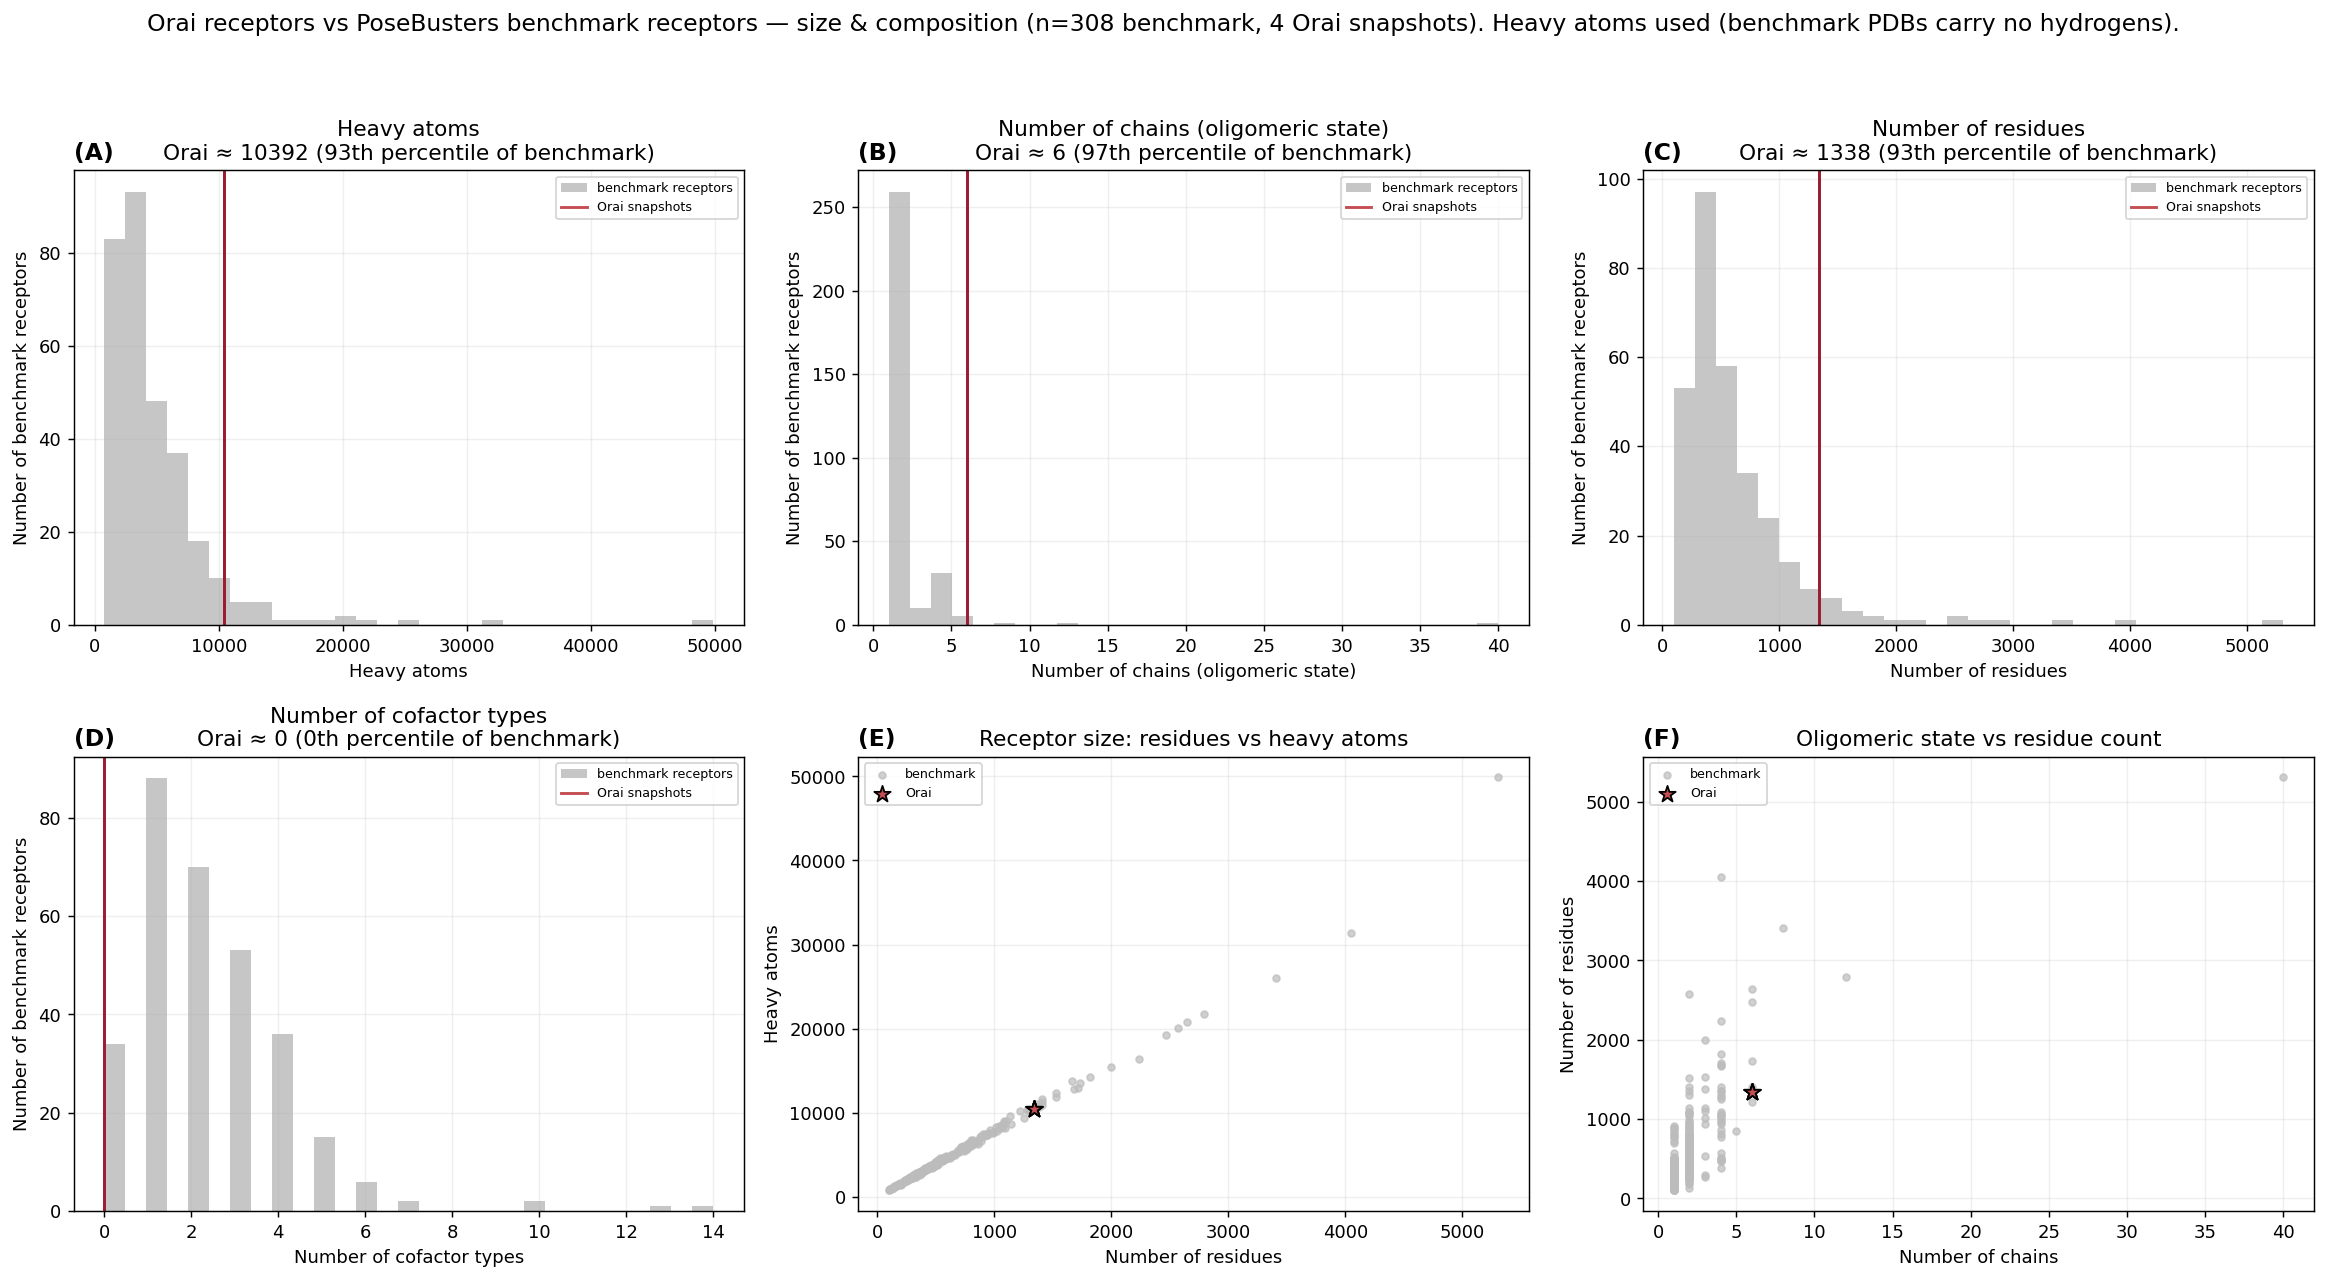

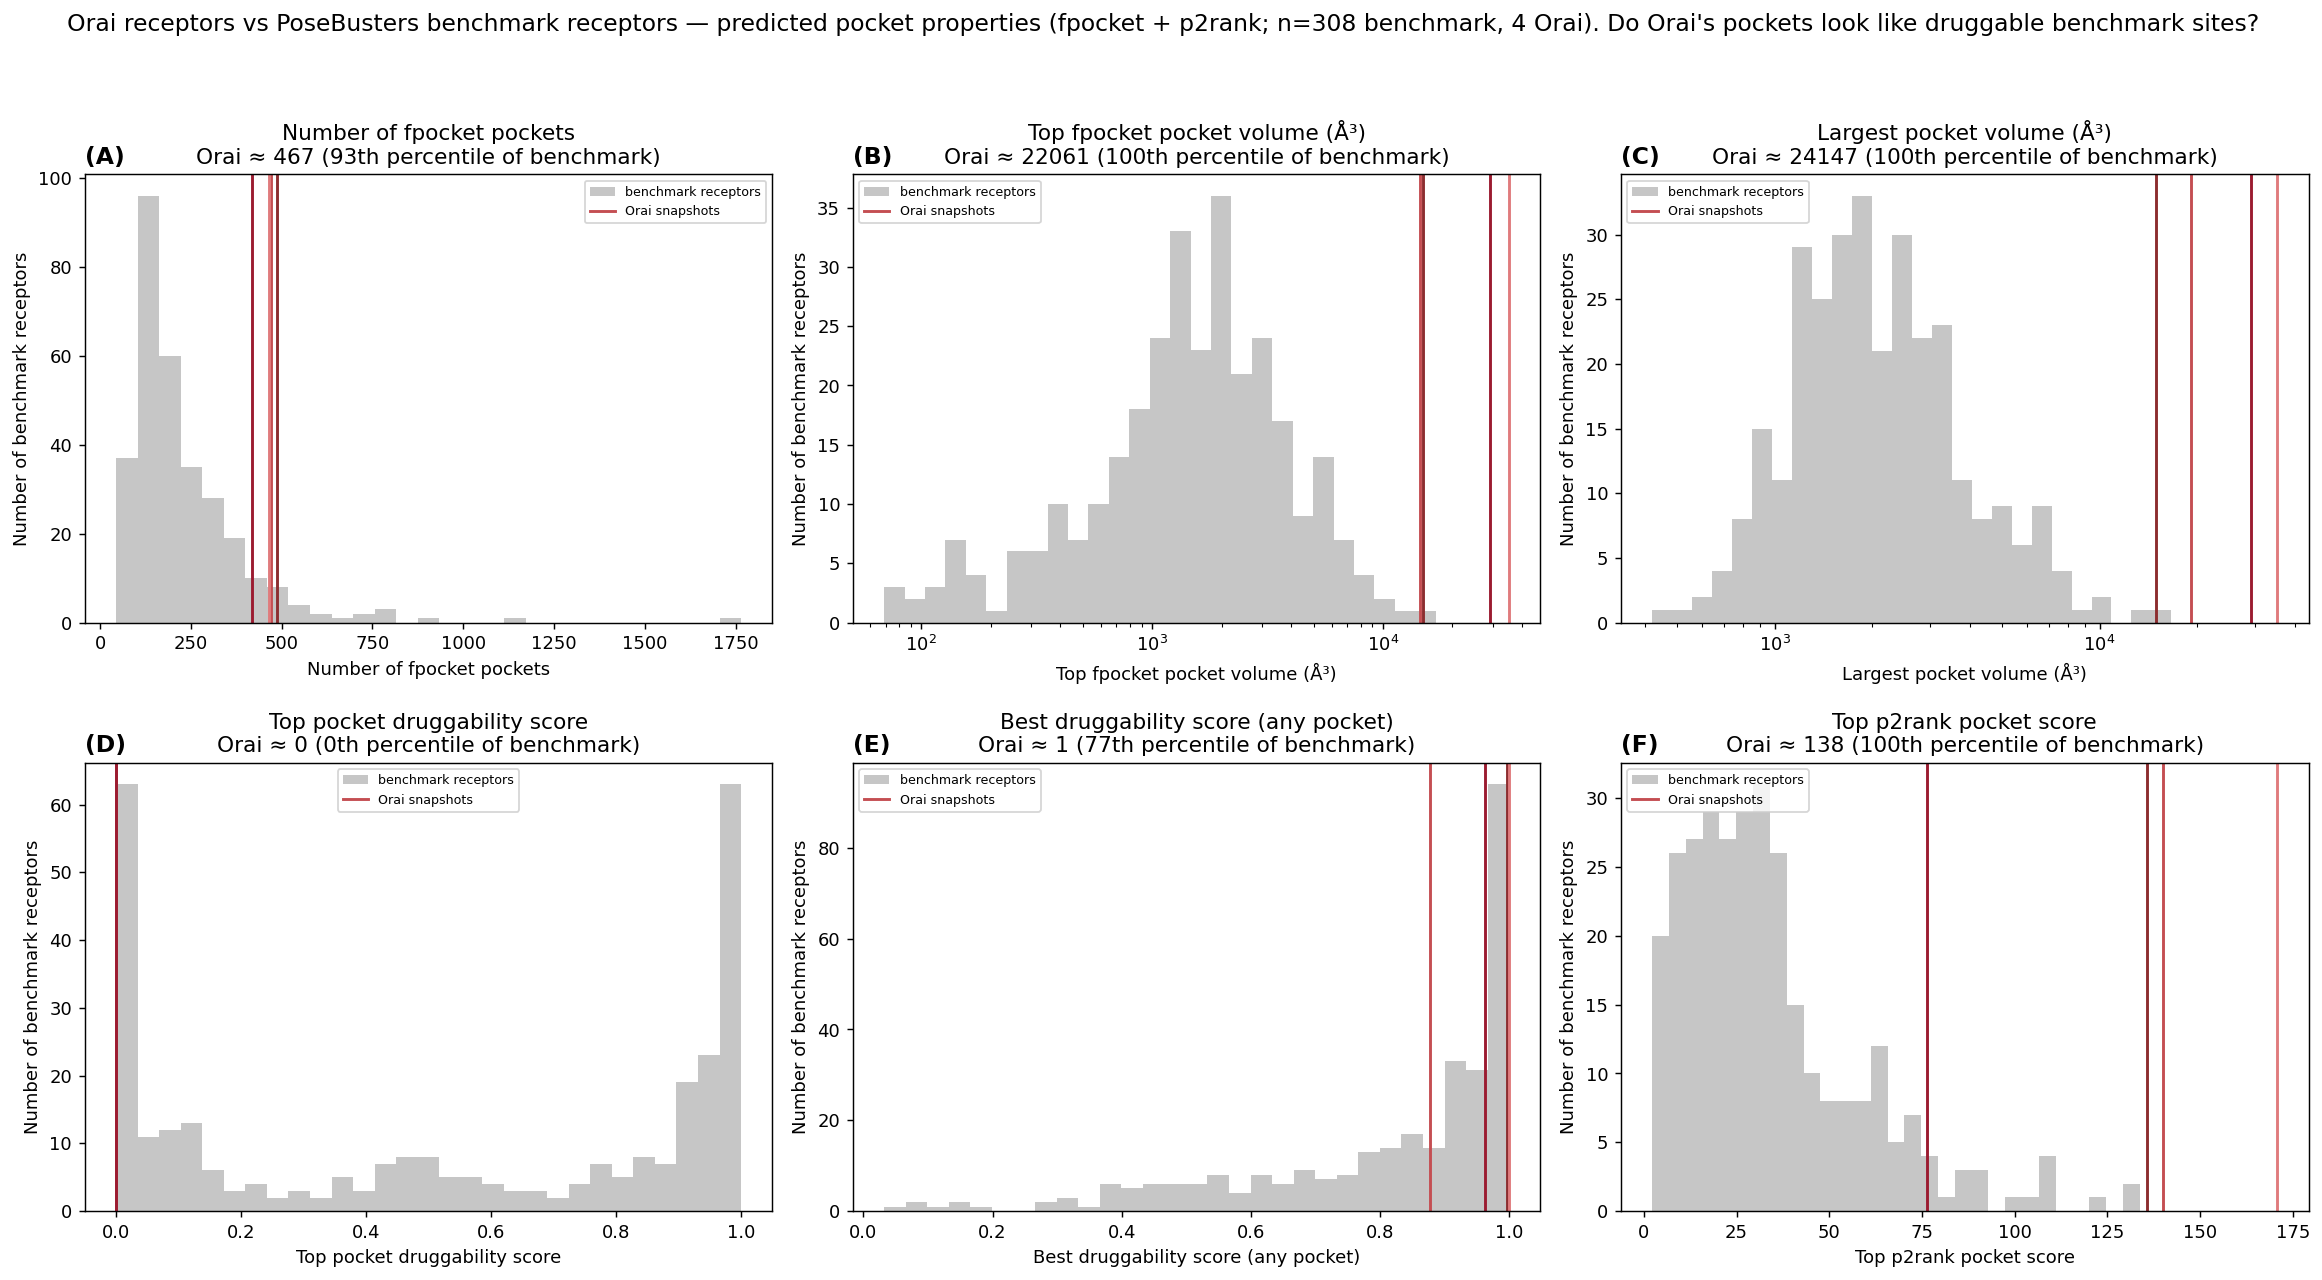

In [ ]:
import subprocess
from pathlib import Path
from IPython.display import Image, display

VINA_PY = "/home/manndo/anaconda3/envs/vina/bin/python"  # pandas/matplotlib live in the vina env

proc = subprocess.run([VINA_PY, "Scripts/Analysis/receptor_comparison_report.py"])
if proc.returncode != 0:
    print(f"\u26a0 receptor_comparison_report.py exited with code {proc.returncode}")

out = Path("posebusters_results/benchmark/receptor_comparison")
for png in ("receptor_descriptor_comparison.png", "receptor_pocket_comparison.png"):
    p = out / png
    if p.exists():
        display(Image(filename=str(p)))

# Orai Section

## Prepare and Create Orai Receptor Files (PDB)

In [ ]:
sys.path.insert(0, str(Path.cwd().parents[1])) 

# Batch clean directory
from Scripts.Utilities.prepare_receptor_pdb import batch_clean_pdbs
batch_clean_pdbs(f"{receptor_folder}/Original", pattern='*.pdb', output_dir=receptor_folder)


Cleaning 4 PDB files from Data/Receptors/Original
⏭ Skipping Orai1WT-MDSnap-Fr300.pdb: cleaned version already exists (Orai1WT-MDSnap-Fr300.pdb)
⏭ Skipping Orai1WT-MDSnap-Fr400.pdb: cleaned version already exists (Orai1WT-MDSnap-Fr400.pdb)
⏭ Skipping Orai1WT-START-Fr0.pdb: cleaned version already exists (Orai1WT-START-Fr0.pdb)
⏭ Skipping Orai1WT-MDSnap-Fr499.pdb: cleaned version already exists (Orai1WT-MDSnap-Fr499.pdb)

✓ Successfully cleaned 4/4 files (4 skipped, already existed)


['Data/Receptors/Orai1WT-MDSnap-Fr300.pdb',
 'Data/Receptors/Orai1WT-MDSnap-Fr400.pdb',
 'Data/Receptors/Orai1WT-START-Fr0.pdb',
 'Data/Receptors/Orai1WT-MDSnap-Fr499.pdb']

## Prepare Ligand Files (PDB)

In [ ]:
from Scripts.Utilities.prep_docking import run_workflow

ligand_outputs = run_workflow(
    input_dir=Path(ligand_folder),
    contains="ligands",
    ligand_formats=["pdb"],
    output_dir=Path(ligand_folder),
    process_postfixes=False,
)



ORAI1 PROTEIN-LIGAND DOCKING PREPARATION WORKFLOW

STEP 1: CONVERTING LIGAND FILES (XYZ → PDB/SDF/MOL2)
✓ OpenBabel is installed

PROCESSING 3 LIGAND(S)
⚡ Processing 3 ligand XYZ files with 3 parallel workers

Converting: /home/manndo/master_dev/Data/Ligands/JKU/2abp-nh2-OPT.xyz

Converting: /home/manndo/master_dev/Data/Ligands/JKU/Synta-66-OPT-Singlet.xyz

Converting: /home/manndo/master_dev/Data/Ligands/JKU/gsk7975a-deprot-OPT.xyz
✓ PDB  (    6728 bytes) → Data/Ligands/JKU/Synta-66-OPT-Singlet.pdb
✓ PDB  (    5200 bytes) → Data/Ligands/JKU/2abp-nh2-OPT.pdb
✓ PDB  (    6119 bytes) → Data/Ligands/JKU/gsk7975a-deprot-OPT.pdb
• 3 ligand(s) already in SDF/MOL2/PDB format — using as-is


STEP 2: VALIDATING PROTEIN STRUCTURES
• No protein files supplied; skipping validation


STEP 3: PREPARING FOR MOLECULAR DOCKING


WORKFLOW COMPLETE

Next Steps:
1. Review converted ligand files in the output directory
3. For AutoDock Vina, convert to PDBQT using Meeko when ligands and proteins are availa

## Autodock Vina Orai x JKU Ligands

### Autodock Config

In [ ]:
import yaml

config_path = Path("Scripts/Docking/autodock_vina_docking_config.yaml")

# Load current config
with open(config_path, "r") as f:
    docking_cfg = yaml.safe_load(f)

# ── Edit any values below, then run this cell to save ────────────────────────

# Input paths (synced with notebook variables by default)
docking_cfg["receptors_dir"]       = receptor_folder          # "Data/Receptors"
docking_cfg["ligand_dirs"]         = [ligand_folder]           # ["Data/Ligands/JKU"]

# Preparation tools
docking_cfg["prep_tool"]           = "both"         # "mgltools", "meeko", or "both"
docking_cfg["skip_pdb_validation"] = False          # True=skip, False=validate (default: False)
docking_cfg["process_postfixes"]   = False         # True=add _prepared/_pdbqt postfixes, False=keep original names (default: False)
docking_cfg["repair_terminals"]    = False         # True=repair, False=do not repair (default: False)

# Output
docking_cfg["output_dir"]          = "Dockings/vina_results"
docking_cfg["log_dir"]             = "Dockings/Logs/vina_logs"

# Vina executable
docking_cfg["vina_bin"]            = "/home/manndo/AutoDock-Vina/build/linux/release/vina"

# Scoring function
docking_cfg["scoring_function"]    = "vina"         # "vina", "vinardo", or "ad4"
docking_cfg["autogrid_bin"]        = "/usr/local/bin/autogrid4"

# Batch mode
docking_cfg["batch_mode"]          = None            # None=auto, True=force, False=disable
docking_cfg["batch_size"]          = 10
docking_cfg["batch_timeout"]       = 900

# Docking parameters
docking_cfg["exhaustiveness"]      = 32
docking_cfg["num_modes"]           = 10
docking_cfg["energy_range"]        = 3
docking_cfg["seed"]                = 42
docking_cfg["timeout_per_complex"] = 600

# Parallelism
docking_cfg["max_workers"]         = 1
docking_cfg["cpus_per_worker"]     = 32

# Overwrite settings
docking_cfg["overwrite_existing"]  = False
docking_cfg["overwrite_poses"]     = False
docking_cfg["overwrite_error_log"] = False

# ── Save updated config ─────────────────────────────────────────────────────
with open(config_path, "w") as f:
    yaml.dump(docking_cfg, f, default_flow_style=False, sort_keys=False)

print(f"✓ Config saved to {config_path}")
print(yaml.dump(docking_cfg, default_flow_style=False, sort_keys=False))


✓ Config saved to Scripts/Docking/autodock_vina_docking_config.yaml
receptors_dir: Data/Receptors
ligand_dirs:
- Data/Ligands/JKU
prep_tool: both
skip_pdb_validation: false
process_postfixes: false
repair_terminals: false
output_dir: Dockings/vina_results
log_dir: Dockings/Logs/vina_logs
vina_bin: /home/manndo/AutoDock-Vina/build/linux/release/vina
scoring_function: vina
autogrid_bin: /usr/local/bin/autogrid4
batch_mode: null
batch_size: 10
batch_timeout: 900
exhaustiveness: 32
num_modes: 10
energy_range: 3
seed: 42
timeout_per_complex: 600
max_workers: 1
cpus_per_worker: 32
overwrite_existing: false
overwrite_poses: false
overwrite_error_log: false
retain_hetatm_residues: true



In [ ]:
%run Scripts/Docking/run_autodock.py -c Scripts/Docking/autodock_vina_docking_config.yaml

AutoDock Vina Batch Docking Configuration
Vina executable:     /home/manndo/AutoDock-Vina/build/linux/release/vina
Scoring function:    vina
Prep tool(s):        both
Batch mode:          auto
Batch size:          10
Batch timeout:       900s
Exhaustiveness:      32
Num modes:           10
Energy range:        3 kcal/mol
Timeout per complex: 600s (10 min)
Workers:             1  (CPUs/worker: 32)
Retain HETATM:       YES  (104 residue types: 7DG, ACO, ADP, AG, AMP, ANP, ATP, AU, … (+96 more))
Overwrite docking:   False
Overwrite poses:     False
Output dir:          Dockings/vina_results
Log dir:             Dockings/Logs/vina_logs
Receptor dir:        Data/Receptors
Ligand dirs (1):
  • Data/Ligands/JKU

CPU: Intel(R) Core(TM) i9-14900HX

────────────────────────────────────────────────────────────────────────────────
Preparing proteins with: mgl_tools
────────────────────────────────────────────────────────────────────────────────

ORAI1 PROTEIN-LIGAND DOCKING PREPARATION WORKFLOW

S

## DiffDock Orai x JKU Ligands

### DiffDock Config

In [ ]:
import yaml

config_path = Path("Scripts/Docking/diffdock_docking_config.yaml")

# Load current config
with open(config_path, "r") as f:
    diffdock_cfg = yaml.safe_load(f)

# ── Edit any values below, then run this cell to save ────────────────────────

# Input paths (synced with notebook variables by default)
diffdock_cfg["receptors_dir"]   = receptor_folder      # "Data/Receptors"
diffdock_cfg["ligand_dirs"]     = [str(Path(ligand_folder) / "pdbqt")]  # SDFs are in pdbqt/ subdirectory

# DiffDock installation
diffdock_cfg["diffdock_dir"]    = "/home/manndo/docking_tools/DiffDock"
diffdock_cfg["diffdock_python"] = "/home/manndo/anaconda3/envs/diffdock/bin/python"
diffdock_cfg["diffdock_conda_env"] = "diffdock"

# Inference parameters
diffdock_cfg["num_samples"]       = 10   # poses per complex
diffdock_cfg["inference_steps"]   = 20   # denoising steps (fewer = faster)
diffdock_cfg["device"]            = "cuda:0"  # "cpu" or "cuda:0"

# Output
diffdock_cfg["output_dir"]        = "Dockings/diffdock_results"
diffdock_cfg["log_dir"]           = "Dockings/Logs/diffdock_logs"

# Batch mode
diffdock_cfg["batch_mode"]        = True   # True = CSV batch (fastest)
diffdock_cfg["batch_size"]        = 15     # complexes per subprocess; 0 = all
diffdock_cfg["group_by_receptor"]   = True  # True = one subprocess per unique receptor
diffdock_cfg["max_workers"]       = 1      # parallel workers (batch_mode=False only)

# Timeout
diffdock_cfg["timeout_per_complex"] = 600  # seconds; 0 = unlimited

# Overwrite settings
diffdock_cfg["overwrite_existing"]  = False  # re-dock already completed combinations
diffdock_cfg["overwrite_error_log"] = False  # retry previously failed ligands

# ── Save updated config ─────────────────────────────────────────────────────
with open(config_path, "w") as f:
    yaml.safe_dump(diffdock_cfg, f, default_flow_style=False, sort_keys=False)

print(f"✓ Config saved to {config_path}")
print(yaml.safe_dump(diffdock_cfg, default_flow_style=False, sort_keys=False))


✓ Config saved to Scripts/Docking/diffdock_docking_config.yaml
receptors_dir: Data/Receptors
ligand_dirs:
- Data/Ligands/JKU/pdbqt
diffdock_dir: /home/manndo/docking_tools/DiffDock
diffdock_python: /home/manndo/anaconda3/envs/diffdock/bin/python
diffdock_conda_env: diffdock
num_samples: 10
inference_steps: 20
device: cuda:0
timeout_per_complex: 600
output_dir: Dockings/diffdock_results
log_dir: Dockings/Logs/diffdock_logs
batch_mode: true
batch_size: 15
group_by_receptor: true
max_workers: 1
overwrite_existing: false
overwrite_error_log: false
optimization: all
optimize_search: minimize
optimize_autobox_add: 4.0
optimize_cpu: 1
optimize_seed: 0
optimize_timeout: 300
gnina_use_gpu: true
smina_executable: /home/manndo/anaconda3/envs/diffdock/bin/smina
gnina_executable: /home/manndo/docking_tools/gnina
gnina_lib_dirs: []



In [ ]:
%run Scripts/Docking/run_diffdock.py -c Scripts/Docking/diffdock_docking_config.yaml


DiffDock Batch Docking Configuration
DiffDock dir:        /home/manndo/docking_tools/DiffDock
DiffDock python:     /home/manndo/anaconda3/envs/diffdock/bin/python
Device:              cuda:0
Samples per complex: 10
Inference steps:     20
Pose optimization:   all
  search mode:       minimize
  autobox add:       4.0 Å
  gnina GPU:         on
Timeout per complex: 600s (10 min)
Batch mode:          ON
Batch size:          15
Group by receptor:   YES
Overwrite existing:  False
Overwrite error log: False
Output dir:          Dockings/diffdock_results
Log dir:             Dockings/Logs/diffdock_logs
Receptor dir:        Data/Receptors
Ligand dirs (1):
  • Data/Ligands/JKU/pdbqt

GPU: NVIDIA GeForce RTX 4070 Laptop GPU

Processing ligand directory: pdbqt
Output: Dockings/diffdock_results/pdbqt
Found 4 proteins and 6 ligands
DiffDock Docking
Mode: CSV batch (group-by-receptor)
Output directory: Dockings/diffdock_results/pdbqt
Proteins: 4  |  Ligands: 6  |  Total: 24
Previously failed (will s

## Equibind Orai x JKU Ligands

### Equibind Config

In [ ]:
import yaml

config_path = Path("Scripts/Docking/equibind_docking_config.yaml")

# Load current config
with open(config_path, "r") as f:
    equibind_cfg = yaml.safe_load(f)

# ── Edit any values below, then run this cell to save ────────────────────────

# Input paths (synced with notebook variables by default)
equibind_cfg["receptors_dir"]        = receptor_folder      # "Data/Receptors"
equibind_cfg["ligand_dirs"]          = [str(Path(ligand_folder) / "pdbqt")]  # SDFs are in pdbqt/ subdirectory
equibind_cfg["receptor_name_filter"] = ""                   # "" = use every *.pdb
equibind_cfg["ligand_extensions"]    = [".pdb"]    # accepted ligand file types (case-insensitive)

# Pocket detection results (used for pocket-guided docking)
equibind_cfg["fpocket_results_dir"]  = "pocket_results/fpocket_results"
equibind_cfg["p2rank_results_dir"]   = "pocket_results/p2rank_results"

# EquiBind installation
equibind_cfg["equibind_dir"]         = "/home/manndo/tools/EquiBind"
equibind_cfg["equibind_python"]      = "/home/manndo/anaconda3/envs/equibind/bin/python"
equibind_cfg["device"]               = "cuda"               # "cpu" or "cuda"

# Output
equibind_cfg["output_dir"]           = "Dockings/equibind_results"
equibind_cfg["log_dir"]              = "Dockings/Logs/equibind_logs"

# Pose generation
equibind_cfg["n_top_pockets"]          = 3      # top-ranked pockets per method (fpocket + p2rank)
equibind_cfg["poses_per_pocket"]       = 3      # poses per pocket (uses different conformers)
equibind_cfg["n_unguided_poses"]       = 30      # natural EquiBind poses per protein-ligand pair
equibind_cfg["pocket_match_threshold"] = 8.0    # Å — distance to consider a pose "inside" a pocket

# Pocket enforcement
equibind_cfg["force_pocket"]         = True     # reject/clamp poses whose centroid drifts outside pocket
equibind_cfg["clamp_pose_to_pocket"] = True     # clamp drifted poses (instead of rejecting)
# Centroid-clamp mode (EQ_CLAMP_MODE). "on" honours force_pocket + clamp_pose_to_pocket;
# "off" keeps the raw EquiBind centroid; "both" emits __clampON / __clampOFF variants.
equibind_cfg["clamp_mode"]           = "both"   # "both" → emit __clampON / __clampOFF (all clamp variants)

# Post-pose re-search (smina / gnina) — moves the ligand as a body out of deep protein
# clashes that UFF alone cannot relieve (see EquiBind PoseBusters failure note).
#   "off"  → no re-search (default, back-compatible)
#   "on"   → replace each pose with its smina-refined pose
#   "both" → emit both __refRAW and __refSMINA variants (measures the gain)
equibind_cfg["refine_mode"]          = "both"        # "both" → emit __refRAW / __refSMINA (raw + smina variants)
equibind_cfg["refine_tool"]          = "smina"       # "smina" | "gnina" (physics + CNN) | "both"
equibind_cfg["smina_search"]         = "local_only"  # "local_only" | "minimize"
equibind_cfg["smina_autobox_add"]    = 4.0           # Å padding around the pose for the search box
equibind_cfg["smina_cpu"]            = 1
equibind_cfg["smina_seed"]           = 0
equibind_cfg["smina_timeout_s"]      = 300           # per-pose smina timeout (s)
equibind_cfg["smina_receptor_ext"]   = ".pdb"        # ".pdb" or ".pdbqt" receptor for smina
equibind_cfg["smina_executable"]     = ""            # "" = autodetect on PATH (or set via EQ_SMINA)
equibind_cfg["gnina_executable"]     = ""            # "" = autodetect on PATH (or set via EQ_GNINA)
equibind_cfg["gnina_use_gpu"]        = False         # run gnina's CNN on the GPU (off → --no_gpu)

# Protein cropping (constrains EquiBind search space)
equibind_cfg["use_protein_cropping"] = True
equibind_cfg["pocket_crop_radius"]   = 8.0
equibind_cfg["pocket_crop_buffer"]   = 3.0

# RDKit conformer generation
equibind_cfg["rdkit_seeds"]           = [42, 123, 456, 789, 1001, 2022, 3141, 5926, 8675, 9999, 7, 13, 17, 271, 314, 628, 1234, 1618, 2718, 4040, 4242, 5050, 6060, 7070, 8080, 9090, 11111, 22222, 31415, 65536]
equibind_cfg["conformers_per_seed"]   = 1

# UFF post-docking minimization
equibind_cfg["uff_minimize"]              = True
equibind_cfg["uff_max_iters"]             = 200
equibind_cfg["uff_energy_tol"]            = 1.0e-4
equibind_cfg["uff_force_tol"]             = 1.0e-3
equibind_cfg["uff_proximity_radius"]      = 6.0
equibind_cfg["uff_add_hydrogens"]         = True
equibind_cfg["uff_strip_nonstandard"]     = True
# vdW cutoff for UFF: pairs farther than uff_vdw_thresh × (sum of vdW radii) are
# dropped. The old 0.1 excluded essentially all vdW interactions (even active
# clashes), so the minimizer could not feel — or relieve — protein overlaps.
# 10.0 is RDKit's default and includes the clash range. DO NOT lower back to 0.1.
equibind_cfg["uff_vdw_thresh"]            = 10.0

# Performance
equibind_cfg["gpu_batch_size"]         = 8     # ligands per GPU batch
equibind_cfg["n_parallel_workers"]     = 0     # 0 = auto (min(cpu_count, 26))
equibind_cfg["parallel_conformer_gen"] = True

# Skip / overwrite
equibind_cfg["skip_existing"]          = True   # re-use existing pose SDFs / cached results

# Drop legacy keys the current pipeline no longer reads (no-op if already absent).
# Keeps the saved YAML in sync with equibind_pipeline/config.py.
for _legacy in ("smina_min_rmsd", "rdkit_prune_rms_thresh", "uff_protein_constraint_wt", "parallel_uff",
                "overwrite_existing", "overwrite_error_log", "monitor_level"):
    equibind_cfg.pop(_legacy, None)

# ── Save updated config ─────────────────────────────────────────────────────
with open(config_path, "w") as f:
    yaml.safe_dump(equibind_cfg, f, default_flow_style=False, sort_keys=False)

print(f"✓ Config saved to {config_path}")
print(yaml.safe_dump(equibind_cfg, default_flow_style=False, sort_keys=False))


✓ Config saved to Scripts/Docking/equibind_docking_config.yaml
receptors_dir: Data/Receptors
ligand_dirs:
- Data/Ligands/JKU/pdbqt
receptor_name_filter: ''
ligand_extensions:
- .pdb
fpocket_results_dir: pocket_results/fpocket_results
p2rank_results_dir: pocket_results/p2rank_results
equibind_dir: /home/manndo/tools/EquiBind
equibind_python: /home/manndo/anaconda3/envs/equibind/bin/python
device: cuda
output_dir: Dockings/equibind_results
log_dir: Dockings/Logs/equibind_logs
n_top_pockets: 3
poses_per_pocket: 3
n_unguided_poses: 30
pocket_match_threshold: 8.0
force_pocket: true
clamp_pose_to_pocket: true
clamp_mode: both
refine_mode: both
refine_tool: smina
smina_search: local_only
smina_autobox_add: 4.0
smina_cpu: 1
smina_seed: 0
smina_timeout_s: 300
smina_receptor_ext: .pdb
smina_executable: ''
gnina_executable: ''
gnina_use_gpu: false
use_protein_cropping: true
pocket_crop_radius: 8.0
pocket_crop_buffer: 3.0
rdkit_seeds:
- 42
- 123
- 456
- 789
- 1001
- 2022
- 3141
- 5926
- 8675
- 999

In [ ]:
import os, sys, subprocess, yaml
from pathlib import Path

config_path   = Path("Scripts/Docking/equibind_docking_config.yaml")
runner_script = Path("Scripts/Docking/run_equibind.py")

with open(config_path) as f:
    eb_cfg = yaml.safe_load(f)

equibind_dir    = os.path.expanduser(eb_cfg.get("equibind_dir", "~/tools/EquiBind"))
equibind_python = Path(eb_cfg.get("equibind_python", "/home/manndo/anaconda3/envs/equibind/bin/python"))
if not equibind_python.exists():
    raise FileNotFoundError(f"EquiBind python not found: {equibind_python}")

output_root = Path(eb_cfg["output_dir"])
log_root    = Path(eb_cfg["log_dir"])
output_root.mkdir(parents=True, exist_ok=True)
log_root.mkdir(parents=True, exist_ok=True)

# Optional explicit smina binary (only needed when refine_mode != "off").
smina_exe = str(eb_cfg.get("smina_executable", "")).strip()
gnina_exe = str(eb_cfg.get("gnina_executable", "")).strip()

# One EquiBind invocation per ligand directory (mirrors DiffDock pattern)
for lig_dir in eb_cfg.get("ligand_dirs", []):
    lig_path = Path(lig_dir)
    tag      = lig_path.name
    out_dir  = output_root / tag
    log_file = log_root / f"{tag}.log"
    out_dir.mkdir(parents=True, exist_ok=True)

    env = os.environ.copy()
    env.update({
        "EQ_RECEPTORS_DIR":          str(Path(eb_cfg["receptors_dir"]).resolve()),
        "EQ_DRUGS_DIR":              str(lig_path.resolve()),
        "EQ_OUTPUT_DIR":             str(out_dir.resolve()),
        "EQ_RECEPTOR_FILTER":        eb_cfg.get("receptor_name_filter", ""),
        "EQ_LIGAND_EXTENSIONS":      ",".join(eb_cfg.get("ligand_extensions", [".sdf", ".pdb"])),
        "EQ_EQUIBIND_DIR":           equibind_dir,
        "EQ_DEVICE":                 eb_cfg.get("device", "cuda"),
        "EQ_GPU_BATCH_SIZE":         str(eb_cfg.get("gpu_batch_size", 8)),
        "EQ_FPOCKET_DIR":            str(Path(eb_cfg.get("fpocket_results_dir", "pocket_results/fpocket_results")).resolve()),
        "EQ_P2RANK_DIR":             str(Path(eb_cfg.get("p2rank_results_dir",  "pocket_results/p2rank_results")).resolve()),
        "EQ_N_TOP_POCKETS":          str(eb_cfg.get("n_top_pockets", 3)),
        "EQ_POSES_PER_POCKET":       str(eb_cfg.get("poses_per_pocket", 3)),
        "EQ_N_UNGUIDED_POSES":       str(eb_cfg.get("n_unguided_poses", 5)),
        "EQ_POCKET_MATCH_THRESHOLD": str(eb_cfg.get("pocket_match_threshold", 8.0)),
        "EQ_FORCE_POCKET":           str(eb_cfg.get("force_pocket", True)),
        "EQ_CLAMP_POSE":             str(eb_cfg.get("clamp_pose_to_pocket", True)),
        # ── Clash-study knobs (June-2026 pipeline) ───────────────────────────
        "EQ_CLAMP_MODE":             str(eb_cfg.get("clamp_mode", "on")),
        "EQ_REFINE_MODE":            str(eb_cfg.get("refine_mode", "off")),
        "EQ_REFINE_TOOL":            str(eb_cfg.get("refine_tool", "smina")),
        "EQ_SMINA_SEARCH":           str(eb_cfg.get("smina_search", "local_only")),
        "EQ_SMINA_AUTOBOX_ADD":      str(eb_cfg.get("smina_autobox_add", 4.0)),
        "EQ_SMINA_CPU":              str(eb_cfg.get("smina_cpu", 1)),
        "EQ_SMINA_SEED":             str(eb_cfg.get("smina_seed", 0)),
        "EQ_SMINA_TIMEOUT":          str(eb_cfg.get("smina_timeout_s", 300)),
        "EQ_SMINA_RECEPTOR_EXT":     str(eb_cfg.get("smina_receptor_ext", ".pdb")),
        "EQ_GNINA_USE_GPU":          str(eb_cfg.get("gnina_use_gpu", False)),
        # ─────────────────────────────────────────────────────────────────────
        "EQ_USE_CROPPING":           str(eb_cfg.get("use_protein_cropping", True)),
        "EQ_CROP_RADIUS":            str(eb_cfg.get("pocket_crop_radius", 8.0)),
        "EQ_CROP_BUFFER":            str(eb_cfg.get("pocket_crop_buffer", 3.0)),
        "EQ_CONFORMERS_PER_SEED":    str(eb_cfg.get("conformers_per_seed", 1)),
        "EQ_RDKIT_SEEDS":            ",".join(str(s) for s in eb_cfg.get("rdkit_seeds", [])),
        "EQ_UFF_MINIMIZE":           str(eb_cfg.get("uff_minimize", True)),
        "EQ_UFF_MAX_ITERS":          str(eb_cfg.get("uff_max_iters", 200)),
        "EQ_UFF_ENERGY_TOL":         str(eb_cfg.get("uff_energy_tol", 1e-4)),
        "EQ_UFF_FORCE_TOL":          str(eb_cfg.get("uff_force_tol", 1e-3)),
        "EQ_UFF_PROXIMITY_RADIUS":   str(eb_cfg.get("uff_proximity_radius", 6.0)),
        "EQ_UFF_ADD_H":              str(eb_cfg.get("uff_add_hydrogens", True)),
        # vdW cutoff: 10.0 (RDKit default) so UFF can feel/relieve clashes.
        # NOTE: 0.1 silently disables clash relief — do not pass it.
        "EQ_UFF_VDW_THRESH":         str(eb_cfg.get("uff_vdw_thresh", 10.0)),
        "EQ_UFF_STRIP_NONSTANDARD":  str(eb_cfg.get("uff_strip_nonstandard", True)),
        "EQ_WORKERS":                str(eb_cfg.get("n_parallel_workers", 0) or os.cpu_count() or 8),
        "EQ_PARALLEL_CONFORMER_GEN": str(eb_cfg.get("parallel_conformer_gen", True)),
        "EQ_SKIP_EXISTING":          str(eb_cfg.get("skip_existing", True)),
    })
    # Pin an explicit smina binary only if one is configured; otherwise the
    # pipeline autodetects it on PATH (refine_mode="off" needs no smina at all).
    if smina_exe:
        env["EQ_SMINA"] = smina_exe
    if gnina_exe:
        env["EQ_GNINA"] = gnina_exe

    print(f"\n{'=' * 78}")
    print(f"EquiBind: receptors={eb_cfg['receptors_dir']}  ligands={lig_path}")
    print(f"  clamp_mode={env['EQ_CLAMP_MODE']}  refine_mode={env['EQ_REFINE_MODE']}  uff_vdw_thresh={env['EQ_UFF_VDW_THRESH']}")
    print(f"  output → {out_dir}")
    print(f"  log    → {log_file}")
    print(f"{'=' * 78}\n")

    with open(log_file, "w") as lf:
        proc = subprocess.run(
            [str(equibind_python), str(runner_script.resolve())],
            env=env, cwd=str(Path.cwd()), stdout=lf, stderr=subprocess.STDOUT,
        )

    status = "✓" if proc.returncode == 0 else "✗"
    print(f"{status} EquiBind finished (rc={proc.returncode}) — log: {log_file}")



EquiBind: receptors=Data/Receptors  ligands=Data/Ligands/JKU/pdbqt
  clamp_mode=both  refine_mode=both  uff_vdw_thresh=10.0
  output → Dockings/equibind_results/pdbqt
  log    → Dockings/Logs/equibind_logs/pdbqt.log

✓ EquiBind finished (rc=0) — log: Dockings/Logs/equibind_logs/pdbqt.log


## Orai × JKU Ligands || PoseBusters + PandaMap analysis

PoseBusters validation and PandaMap interaction analysis for the **Orai × JKU**
dataset (4 Orai1WT receptors × the JKU ligands).

- **AutoDock** poses come from `Dockings/vina_results/JKU_meeko/docking/` and are
  staged with the `_meeko` converter tag stripped so `<receptor>__<ligand>` matches
  the staged receptor stem.
- **EquiBind** poses are consumed straight from `Dockings/equibind_results/pdbqt/`
  (`<ligand>__<receptor>/` dirs, split into fpocket/p2rank/unguided variants).
- **DiffDock** poses come from `Dockings/diffdock_results/pdbqt/`
  (`<ligand>__<receptor>/` dirs with `rank*.sdf`), read directly.

There is **no crystal reference** for Orai, so pose-comparison and native-interaction
recovery can't be computed here. The validity report and PandaMap are nonetheless
restricted to the single **best** EquiBind variant via `--best-equibind-only`, which
borrows the ranking from the benchmark `oracle_summary.csv` (top variant
`equibind_unguided_smina_clampOFF`) and relabels it **EquiBind\***.

In [ ]:
import os, re, sys, shutil, subprocess
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────────────────────
receptors_src    = Path("Data/Receptors")
jku_ligand_sdfs  = Path("Data/Ligands/JKU/pdbqt")                    # per-ligand .sdf templates
autodock_src     = Path("Dockings/vina_results/JKU_meeko/docking")   # <rec>_meeko__<lig>_vina_vina_out.pdbqt
diffdock_src     = Path("Dockings/diffdock_results/pdbqt")           # <lig>__<rec>/rank*.sdf (read directly by the config)
equibind_src     = Path("Dockings/equibind_results/pdbqt")           # <lig>__<rec>/*.sdf (read directly by the config)

pb_runner_script = Path("Scripts/Docking/Posebusters/run_posebusters.py")
# PoseBusters must run in the vina env — only its posebusters carries the
# energy_ratio crash-fix; the notebook kernel's package may be unpatched.
VINA_PY = "/home/manndo/anaconda3/envs/vina/bin/python"
pb_config_path   = Path("Scripts/Docking/Posebusters/posebusters_orai_jku_config.yaml")

staging_root     = Path("posebusters_results/_orai_jku_staging")
rec_staging      = staging_root / "receptors"
ad_staging       = staging_root / "autodock"
tpl_staging      = staging_root / "ligand_templates"
for d in (rec_staging, ad_staging, tpl_staging):
    d.mkdir(parents=True, exist_ok=True)

ORAI_RECEPTORS = ["Orai1WT-START-Fr0", "Orai1WT-MDSnap-Fr300",
                  "Orai1WT-MDSnap-Fr400", "Orai1WT-MDSnap-Fr499"]


def _link(src: Path, dst: Path) -> bool:
    if not src.exists():
        return False
    if dst.is_symlink() or dst.exists():
        try:
            if dst.resolve() == src.resolve():
                return True
        except OSError:
            pass
        dst.unlink()
    try:
        dst.symlink_to(src.resolve())
    except OSError:
        shutil.copy2(src, dst)
    return True


# 1. Stage the 4 Orai receptors
n_rec = sum(_link(receptors_src / f"{name}.pdb", rec_staging / f"{name}.pdb")
            for name in ORAI_RECEPTORS)

# 2. Stage AutoDock poses, stripping the "_meeko" converter tag — INCLUDING retry
#    variants (_meeko__, _meeko_retry1__, …) — so "<receptor>__<ligand>..." matches
#    the staged receptor stem (same convention the collectors expect for the
#    Orai_Benchmark set). Without it, Fr0's meeko-retry poses were staged as a
#    phantom protein "Orai1WT-START-Fr0_meeko_retry1" and never matched the
#    Orai1WT-START-Fr0 receptor, so PoseBusters dropped Fr0 AutoDock.
n_ad = 0
if autodock_src.is_dir():
    # drop stale mis-staged links from older runs (staged name still carries _meeko)
    for stale in ad_staging.glob("*_meeko*__*_vina_out.pdbqt"):
        stale.unlink()
    for pdbqt in sorted(autodock_src.glob("*_vina_out.pdbqt")):
        staged_name = re.sub(r"_meeko(?:_retry\d+)?__", "__", pdbqt.name)
        if _link(pdbqt, ad_staging / staged_name):
            n_ad += 1

# 3. Stage per-ligand SDF templates under the AutoDock ligand label
#    (label after parsing = "<ligand>_vina", e.g. "2abp-nh2-OPT_vina").
n_tpl = 0
if jku_ligand_sdfs.is_dir():
    for sdf in sorted(jku_ligand_sdfs.glob("*.sdf")):
        _link(sdf, tpl_staging / f"{sdf.stem}_vina.sdf")   # AutoDock label alias
        _link(sdf, tpl_staging / f"{sdf.stem}.sdf")        # bare alias
        n_tpl += 1

# DiffDock + EquiBind poses are read straight from their source dirs by the
# config (dirs already named "<ligand>__<receptor>"); counted here for sanity.
n_dd = sum(1 for d in diffdock_src.iterdir()
           if d.is_dir() and "__" in d.name and any(d.glob("rank*.sdf"))) if diffdock_src.is_dir() else 0
n_eb = sum(1 for d in equibind_src.iterdir()
           if d.is_dir() and "__" in d.name
           and any(f for f in d.glob("**/*.sdf") if "prep" not in f.parts)) if equibind_src.is_dir() else 0

print("Staging summary (Orai × JKU)")
print("─" * 60)
print(f"  receptors staged:          {n_rec:>5}  → {rec_staging}")
print(f"  AutoDock poses staged:     {n_ad:>5}  → {ad_staging}")
print(f"  ligand templates staged:   {n_tpl:>5}  → {tpl_staging}")
print(f"  DiffDock pose dirs (src):  {n_dd:>5}  ({diffdock_src})")
print(f"  EquiBind pose dirs (src):  {n_eb:>5}  ({equibind_src})")

if not pb_config_path.exists():
    raise FileNotFoundError(pb_config_path)

print(f"\n{'═' * 60}")
print("PoseBusters validation — Orai × JKU")
print(f"  config: {pb_config_path}")
print(f"{'═' * 60}\n")

env = os.environ.copy(); env["PYTHONUNBUFFERED"] = "1"
proc = subprocess.run([VINA_PY, str(pb_runner_script.resolve()),
                       "--config", str(pb_config_path.resolve())],
                      cwd=str(Path.cwd()), env=env)
print(f"\nPoseBusters Orai × JKU COMPLETE  (return code: {proc.returncode})")
print(f"  Results: posebusters_results/orai_jku/dock/")

Staging summary (Orai × JKU)
────────────────────────────────────────────────────────────
  receptors staged:              4  → posebusters_results/_orai_jku_staging/receptors
  AutoDock poses staged:        12  → posebusters_results/_orai_jku_staging/autodock
  ligand templates staged:       3  → posebusters_results/_orai_jku_staging/ligand_templates
  DiffDock pose dirs (src):     12  (Dockings/diffdock_results/pdbqt)
  EquiBind pose dirs (src):     12  (Dockings/equibind_results/pdbqt)

════════════════════════════════════════════════════════════
PoseBusters validation — Orai × JKU
  config: Scripts/Docking/Posebusters/posebusters_orai_jku_config.yaml
════════════════════════════════════════════════════════════

AVAILABLE PROTEIN PDB FILES
  Orai1WT-MDSnap-Fr300  →  /home/manndo/master_dev/posebusters_results/_orai_jku_staging/receptors/Orai1WT-MDSnap-Fr300.pdb
  Orai1WT-MDSnap-Fr400  →  /home/manndo/master_dev/posebusters_results/_orai_jku_staging/receptors/Orai1WT-MDSnap-Fr400.pdb

[06:18:05] WARNING: Accepted unusual valence(s): C(3); C(2)
[06:18:05] WARNING: Accepted unusual valence(s): C(3); C(2)
[06:18:05] WARNING: Accepted unusual valence(s): C(3); C(2)


[06:18:05] WARNING: Accepted unusual valence(s): C(3); C(2)


[06:18:05] WARNING: Accepted unusual valence(s): C(3); C(2)

[06:18:05] WARNING: Accepted unusual valence(s): C(3); C(2)

[06:18:05] WARNING: Accepted unusual valence(s): C(3); C(2)

[06:18:05] WARNING:  Problems/mismatches: Mobile-H( Mobile-H groups: Attachment points, Number)

[06:18:05] WARNING: Accepted unusual valence(s): C(3); C(2)

[06:18:05] WARNING:  Problems/mismatches: Mobile-H( Mobile-H groups: Attachment points, Number)

[06:18:05] WARNING:  Problems/mismatches: Mobile-H( Mobile-H groups: Attachment points, Number)

[06:18:05] WARNING:  Problems/mismatches: Mobile-H( Mobile-H groups: Attachment points, Number)
[06:18:05] WARNING: Accepted unusual valence(s): C(3); C(2)


[06:18:05] WARNING:  Problems/mismatches: Mobile-H( Mobile-H gr

  Processed 1/2794  (overall 1/2794)


[06:18:11] WARNING: Accepted unusual valence(s): C(3); C(2)

[06:18:11] WARNING:  Problems/mismatches: Mobile-H( Mobile-H groups: Attachment points, Number)

[06:18:11] WARNING: Accepted unusual valence(s): C(3); C(2)

[06:18:11] WARNING:  Problems/mismatches: Mobile-H( Mobile-H groups: Attachment points, Number)

[06:18:11] WARNING: Accepted unusual valence(s): C(3); C(2)

[06:18:11] WARNING:  Problems/mismatches: Mobile-H( Mobile-H groups: Attachment points, Number)

[06:18:12] WARNING: Accepted unusual valence(s): C(3); C(2)

[06:18:12] WARNING:  Problems/mismatches: Mobile-H( Mobile-H groups: Attachment points, Number)

[06:18:12] WARNING: Accepted unusual valence(s): C(3); C(2)

[06:18:12] WARNING:  Problems/mismatches: Mobile-H( Mobile-H groups: Attachment points, Number)

[06:18:12] WARNING: Accepted unusual valence(s): C(3); C(2)

[06:18:12] WARNING:  Problems/mismatches: Mobile-H( Mobile-H groups: Attachment points, Number)

[06:18:12] WARNING: Accepted unusual valence(s): C(3

  Processed 10/2794  (overall 10/2794)


...

    [CHECKPOINT] 2600/2794 new  |  total rows: 2600  →  posebusters_filtered_results.csv
  Processed 2610/2794  (overall 2610/2794)
  Processed 2620/2794  (overall 2620/2794)
  Processed 2630/2794  (overall 2630/2794)
  Processed 2640/2794  (overall 2640/2794)
  Processed 2650/2794  (overall 2650/2794)
  Processed 2660/2794  (overall 2660/2794)
  Processed 2670/2794  (overall 2670/2794)
  Processed 2680/2794  (overall 2680/2794)
  Processed 2690/2794  (overall 2690/2794)
  Processed 2700/2794  (overall 2700/2794)
  Processed 2710/2794  (overall 2710/2794)
  Processed 2720/2794  (overall 2720/2794)
  Processed 2730/2794  (overall 2730/2794)
  Processed 2740/2794  (overall 2740/2794)
  Processed 2750/2794  (overall 2750/2794)
  Processed 2760/2794  (overall 2760/2794)
  Processed 2770/2794  (overall 2770/2794)
  Processed 2780/2794  (overall 2780/2794)


/home/manndo/master_dev/Scripts/Docking/Posebusters/run_posebusters.py:1085: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_out = pd.concat(frames, ignore_index=True) if len(frames) > 1 else frames[0]


    [FINAL] 2783/2794 new  |  total rows: 2783  →  posebusters_filtered_results.csv

  Done:  new=2783  prev=0  total=2783  errors=11
    dock mode: 2783  |  mol fallback: 0


/home/manndo/master_dev/Scripts/Docking/Posebusters/run_posebusters.py:1175: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(all_frames, ignore_index=True) if all_frames else pd.DataFrame()



   Results saved to: /home/manndo/master_dev/posebusters_results/orai_jku/dock/posebusters_filtered_results.csv
   Total rows: 2783

   Mode breakdown:
dock    2783

Done!

no_radicals pass rate by method:
docking_method
autodock            66.7
diffdock            88.0
equibind_guided    100.0
Name: no_radicals, dtype: float64

non-aromatic_ring_non-flatness pass rate by method:
docking_method
autodock           66.7
diffdock           66.8
equibind_guided    99.8
Name: non-aromatic_ring_non-flatness, dtype: float64

internal_steric_clash pass rate by method:
docking_method
autodock           100.0
diffdock            99.2
equibind_guided     52.4
Name: internal_steric_clash, dtype: float64
Loading PoseBusters results from: /home/manndo/master_dev/posebusters_results/orai_jku/dock/posebusters_filtered_results.csv

Total entries: 2783

Identified 20 PoseBusters test columns:
  mol_pred_loaded: 2783/2783 passed (100.0%)
  sanitization: 2783/2783 passed (100.0%)
  inchi_convertible: 278

In [ ]:
# Validity report (plots + per-method pass rates) for the Orai × JKU PoseBusters run.
%run Scripts/Analysis/posebusters_validity_report.py \
    --csv posebusters_results/orai_jku/dock/posebusters_filtered_results.csv \
    --out-dir posebusters_results/orai_jku/dock/validity_report \
    --best-equibind-only

  [best-equibind-only] oracle summary not found at posebusters_results/benchmark/dock/pose_comparison_report/oracle_summary.csv — keeping all EquiBind variants.
Total poses scored        : 2,783
Total PB-valid poses      : 480 (17.25%)
Receptor-ligand pairs     : 12
Methods / variants found  : 16 (autodock, diffdock, diffdock_smina, diffdock_gnina, equibind_unguided_raw_clampON, equibind_unguided_raw_clampOFF, equibind_unguided_smina_clampON, equibind_unguided_smina_clampOFF, equibind_fpocket_raw_clampON, equibind_fpocket_raw_clampOFF, equibind_fpocket_smina_clampON, equibind_fpocket_smina_clampOFF, equibind_p2rank_raw_clampON, equibind_p2rank_raw_clampOFF, equibind_p2rank_smina_clampON, equibind_p2rank_smina_clampOFF)

── Per-method summary ───────────────────────────
                                  total_poses  valid_poses  valid_fraction
docking_method                                                            
autodock                                  120           80           0

In [ ]:
import subprocess

VINA_PY = "/home/manndo/anaconda3/envs/vina/bin/python"  # pandamap lives only in the vina env
CFG = "Scripts/Analysis/pandamap_orai_jku_config.yaml"

# run_pandamap builds the interaction fingerprints; the report draws the charts.
# --best-equibind-only keeps only the benchmark-best EquiBind variant (read from the
# benchmark oracle_summary.csv, since Orai has no crystal) and relabels it 'EquiBind*'.
for script in ("run_pandamap.py", "pandamap_interaction_report.py"):
    print(f"\n▶ {script}")
    proc = subprocess.run([VINA_PY, f"Scripts/Analysis/{script}", "--config", CFG, "--best-equibind-only"])
    if proc.returncode != 0:
        print(f"⚠ {script} exited with code {proc.returncode} — continuing notebook.")


▶ run_pandamap.py
PandaMap interaction generator
  input   : PB CSV /home/manndo/master_dev/posebusters_results/orai_jku/dock/posebusters_filtered_results.csv
  output  : /home/manndo/master_dev/pandamap_results/orai_jku
  top-N   : 3 per method×pair   pb_valid_only=True
  crystal : (none)
Collected 480 poses; methods: ['autodock', 'diffdock', 'equibind_fpocket_raw_clampOFF', 'equibind_fpocket_raw_clampON', 'equibind_fpocket_smina_clampOFF', 'equibind_fpocket_smina_clampON', 'equibind_p2rank_raw_clampOFF', 'equibind_p2rank_raw_clampON', 'equibind_p2rank_smina_clampOFF', 'equibind_p2rank_smina_clampON', 'equibind_unguided_raw_clampOFF', 'equibind_unguided_raw_clampON', 'equibind_unguided_smina_clampOFF', 'equibind_unguided_smina_clampON']
  [best-equibind-only] oracle summary not found at /home/manndo/master_dev/posebusters_results/benchmark/dock/pose_comparison_report/oracle_summary.csv — keeping all EquiBind variants.
Selected 195 poses across 11 pairs (14 methods)
Resume: 30 already

[06:24:48] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:24:48] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:24:48] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.



Report written to: /home/manndo/master_dev/pandamap_results/orai_jku/report
  01_interaction_profile.png
  02_type_heatmap.png
  02b_total_boxplot.png
  03_residue_hotspots.png
  06_interaction_vs_chemotype.png
  06b_descriptor_corr.png
  07_residue_class.png
  08_ligand_element.png


## Orai × JKU Ligands || Pose-cluster & cross-tool analysis

Same no-crystal pose-cluster dissection (`Scripts/Analysis/orai_pose_cluster_report.py`)
for the Orai × JKU ligands: clustering, cross-tool agreement, PoseBusters
survivors vs failures, per-frame distribution, outliers and pore-axis position.
Reads the Orai×JKU PoseBusters per-pose CSV with **no ID restriction** (JKU ligands
are not in the benchmark list). Note this set is small (3 JKU ligands × 3 Orai
frames), so the aggregate statistics are a limited view and the ligand-descriptor
panel is skipped (too few ligands / not in the benchmark feature cache).
Outputs → `posebusters_results/orai_jku/pose_clusters/`. Runs in the `vina` env.

=== orai_pose_cluster_report.py (Orai × JKU) ===
Loading poses from posebusters_results/orai_jku/dock/posebusters_filtered_results.csv ...
  2,783 poses | tools: ['autodock', 'diffdock', 'equibind'] | frames: 4 | ligands: 3
Computing pose centroids ...


[06:24:50] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:24:50] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:24:50] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:24:50] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:24:50] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:24:50] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:24:50] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:24:50] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:24:50] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol

  dropped 26 poses with corrupt centroids (|coord| > 1000 Å)
Analysing 12 (frame, ligand) pairs ...

ORAI POSE-CLUSTER REPORT  (n=12 pairs, thr=5 Å)
  Tools analysed: autodock, diffdock, equibind
  Cross-tool agreement (all tools' consensus within 5 Å): 0% of 12 multi-tool pairs
  Median inter-tool consensus distance: 30.4 Å
  Mean clusters/pair: 3.75 | mean dominant-cluster fraction: 64%
  PoseBusters: valid poses sit 22.3 Å from consensus vs 14.5 Å for invalid (median) → no tightness advantage

  Per Orai MD frame:
  frame                    pairs  clusters  dom.frac  agree%  pb-valid%
  Orai1WT-MDSnap-Fr300         3      3.00       60%     0%        22%
  Orai1WT-MDSnap-Fr400         3      2.67       74%     0%         8%
  Orai1WT-MDSnap-Fr499         3      5.67       60%     0%        10%
  Orai1WT-START-Fr0            3      3.67       63%     0%        26%

  Outliers: 1784 poses > 10 Å from consensus; top tool-disagreement pairs in top_tool_disagreement.csv

  CSVs written t

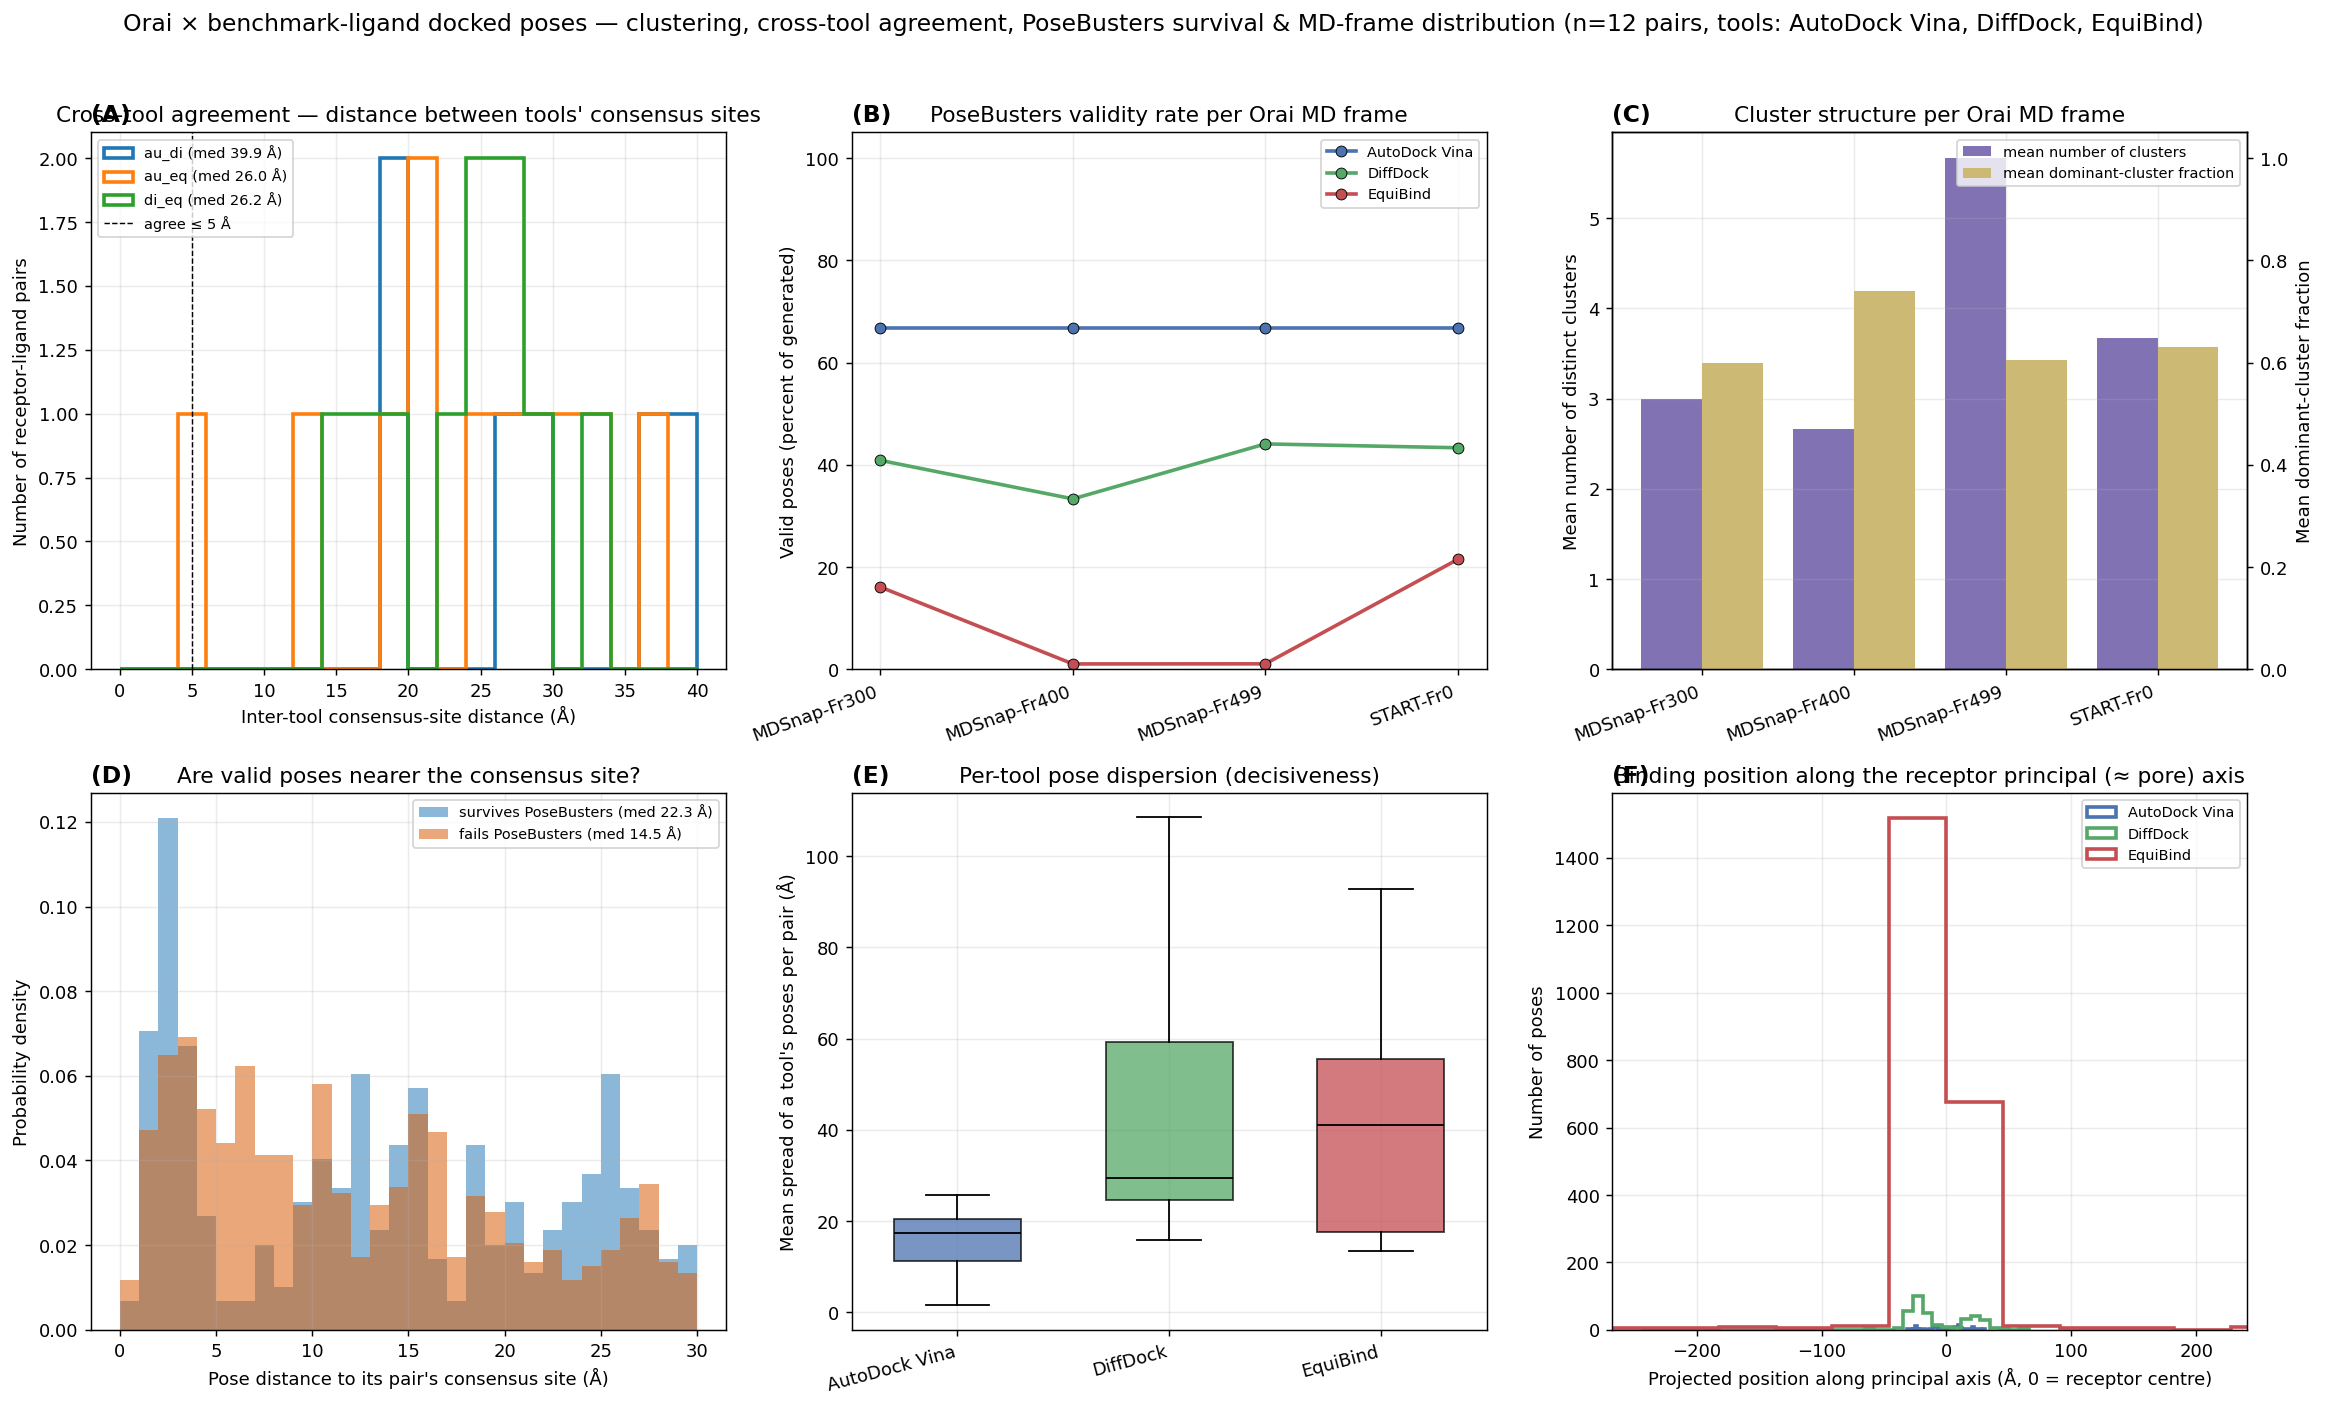

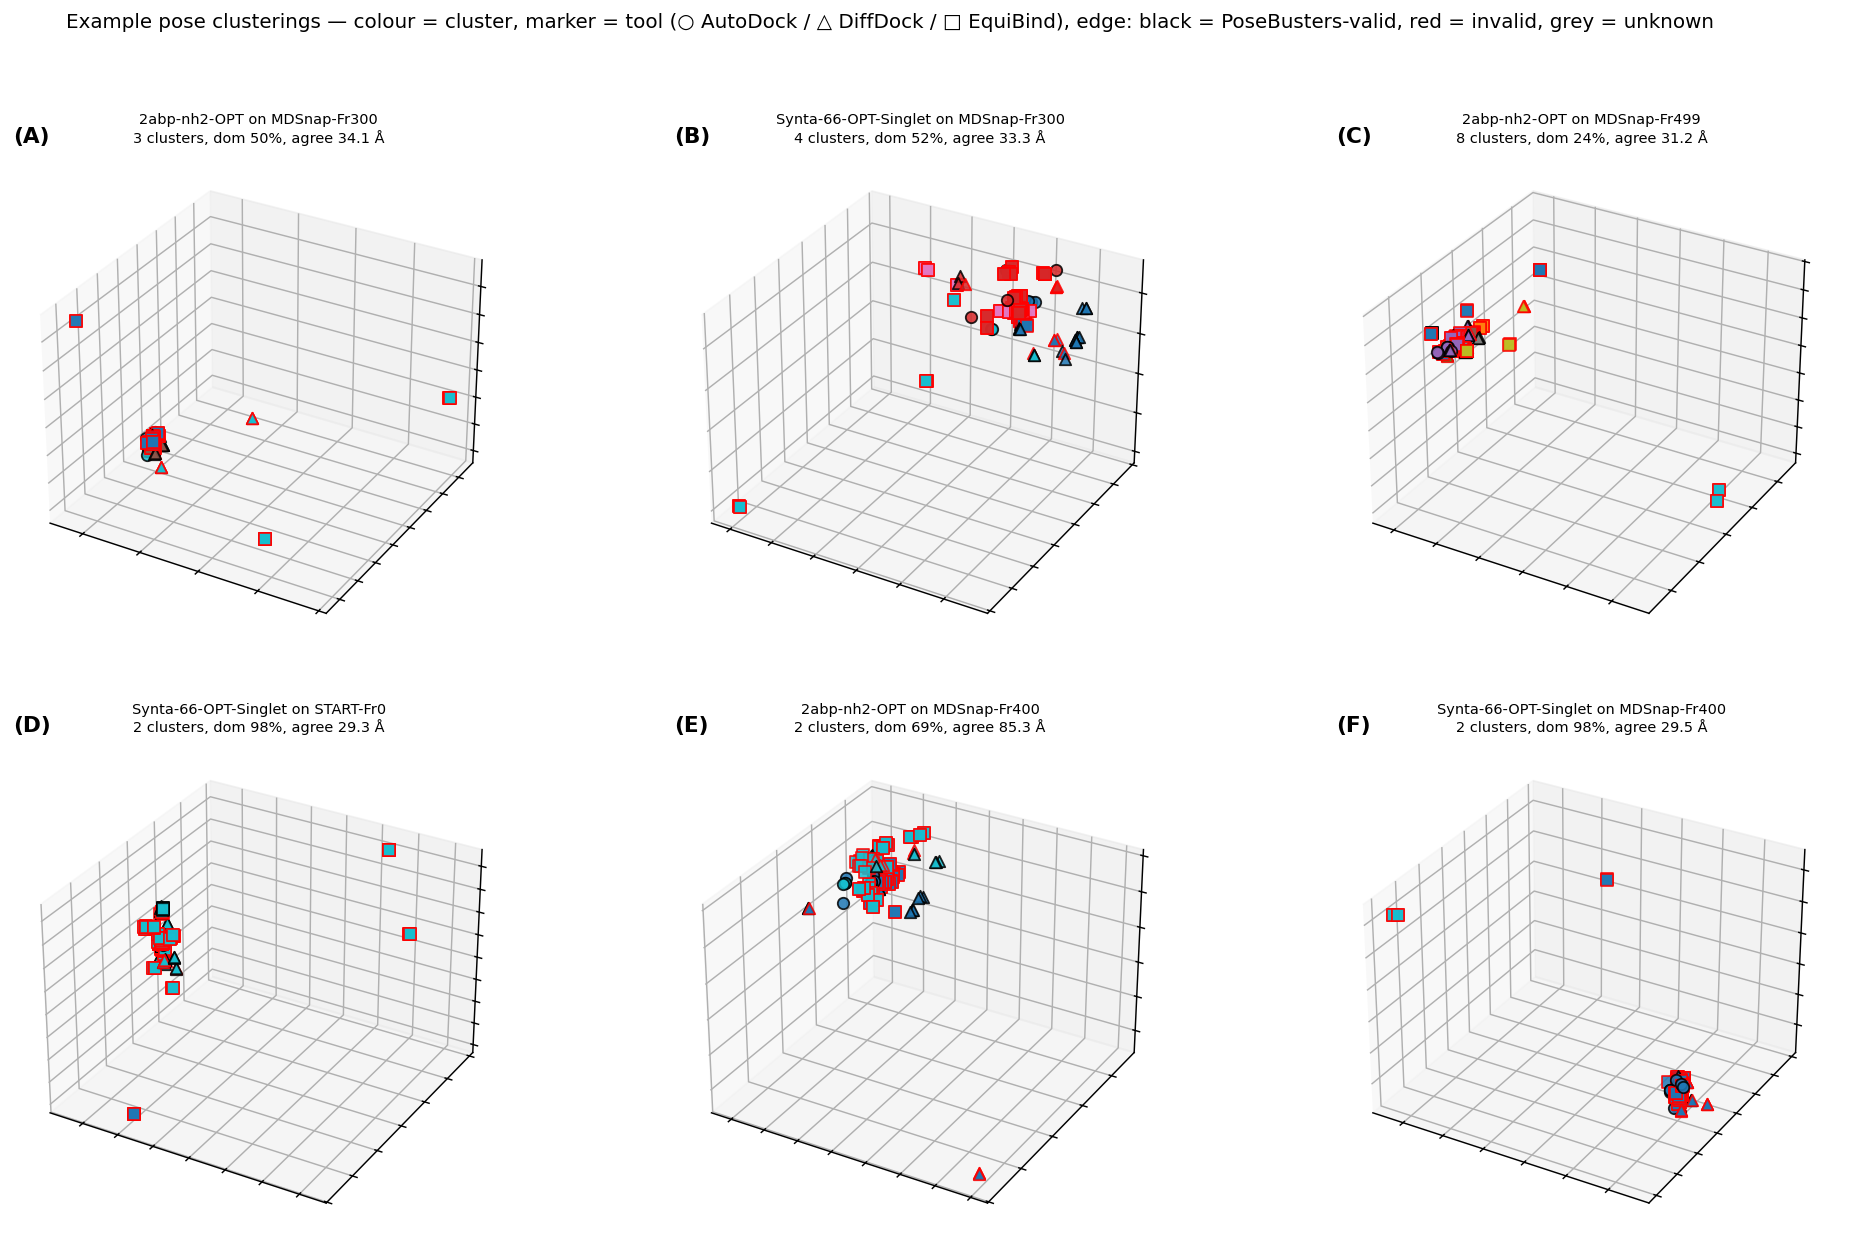

In [ ]:
import subprocess
from pathlib import Path
from IPython.display import Image, display

VINA_PY = "/home/manndo/anaconda3/envs/vina/bin/python"   # rdkit/sklearn/scipy/matplotlib in the vina env

cmd = ["Scripts/Analysis/orai_pose_cluster_report.py",
       "--per-pose-csv", "posebusters_results/orai_jku/dock/posebusters_filtered_results.csv",
       "--ids-file", "",                       # JKU ligands are not the 308 benchmark set
       "--out-dir", "posebusters_results/orai_jku/pose_clusters"]
print(f"=== {Path(cmd[0]).name} (Orai \u00d7 JKU) ===")
proc = subprocess.run([VINA_PY, *cmd])
if proc.returncode != 0:
    print(f"WARN {cmd[0]} exited with code {proc.returncode} - continuing notebook.")

out = Path("posebusters_results/orai_jku/pose_clusters")
for png in ("orai_pose_cluster_overview.png", "orai_example_clusters.png"):
    p = out / png
    if p.exists():
        display(Image(filename=str(p)))

# Orai x Benchmark Section

## Orai × PoseBuster Benchmark Ligands || AutoDock Vina (batched)

Docks every Orai receptor in `Data/Receptors/*.pdb` against every ligand
(`*_ligand_start_conf.sdf`) in `Data/PoseBuster Benchmark Set/`,
running 50 ligands per Vina invocation per receptor.

Ligands are restricted to the official benchmark ID list
(`posebusters_pdb_ccd_ids.txt`, 308 ids); on-disk complexes not in the list are skipped.

In [ ]:
import yaml, json, shutil
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

from Scripts.Docking.run_autodock import (
    run_autodock_vina, build_prepared_manifest, generate_summary,
    get_cpu_model, collect_files, get_pdbqt_dir, DockingResult,
)
from Scripts.Utilities.prep_docking import run_workflow

# ── Paths ────────────────────────────────────────────────────────────────────
benchmark_dir = Path("Data/PoseBuster Benchmark Set")
receptors_dir = Path(receptor_folder)                       # Data/Receptors
output_base   = Path("Dockings/Orai_Benchmark")
log_dir       = Path("Dockings/Logs/orai_benchmark_logs")
config_path   = Path("Scripts/Docking/orai_benchmark_autodock_config.yaml")
staging_root  = output_base / "_staging"
lig_staging   = staging_root / "ligands"
rec_staging   = staging_root / "receptors"

# ── Load + freeze the on-disk config (do not overwrite output_dir to disk) ──
with open(config_path) as f:
    cfg = yaml.safe_load(f)

cfg["receptors_dir"] = str(rec_staging)
cfg["ligand_dirs"]   = [str(lig_staging)]
cfg["output_dir"]    = str(output_base)
cfg["log_dir"]       = str(log_dir)
cfg["batch_mode"]    = True
cfg["batch_size"]    = 50

output_base.mkdir(parents=True, exist_ok=True)
log_dir.mkdir(parents=True, exist_ok=True)
lig_staging.mkdir(parents=True, exist_ok=True)
rec_staging.mkdir(parents=True, exist_ok=True)

cpu_model = get_cpu_model()
print(f"CPU: {cpu_model}")

# ── Stage receptors (symlink the 4 Orai PDBs into staging) ──────────────────
receptor_pdbs = sorted(p for p in receptors_dir.glob("*.pdb") if p.is_file())
if not receptor_pdbs:
    raise FileNotFoundError(f"No receptor PDBs found in {receptors_dir}")
for r in receptor_pdbs:
    link = rec_staging / r.name
    if not link.exists():
        link.symlink_to(r.resolve())
print(f"Receptors staged: {len(receptor_pdbs)}")
for r in receptor_pdbs:
    print(f"  • {r.name}")

# ── Stage benchmark ligands (symlink every *_ligand_start_conf.sdf) ─────────
# Restrict to the official PoseBusters benchmark ID list.
benchmark_ids_file = Path("Data/PoseBuster Benchmark Set/posebusters_pdb_ccd_ids.txt")
allowed_ids = {
    ln.strip() for ln in benchmark_ids_file.read_text().splitlines()
    if ln.strip() and not ln.lstrip().startswith("#")
}
print(f"Benchmark ID restriction: {len(allowed_ids)} ids from {benchmark_ids_file.name}")

complex_dirs = sorted(
    d for d in benchmark_dir.iterdir()
    if d.is_dir() and not d.name.startswith(("_", ".")) and d.name in allowed_ids
)
# Exactly the in-list ligand filenames we want staged.
wanted = {f"{d.name}_ligand_start_conf.sdf" for d in complex_dirs
          if (d / f"{d.name}_ligand_start_conf.sdf").exists()}

# Staging is append-only, so PRUNE any stale/off-list symlink first — otherwise a
# previous unrestricted run leaves extra ligands that AutoDock would still re-dock.
n_pruned = 0
for f in lig_staging.glob("*.sdf"):
    if f.name not in wanted:
        f.unlink()                       # removes only the symlink, not the source SDF
        n_pruned += 1

n_staged, n_missing = 0, 0
for cdir in complex_dirs:
    lig = cdir / f"{cdir.name}_ligand_start_conf.sdf"
    if not lig.exists():
        n_missing += 1
        continue
    link = lig_staging / lig.name
    if not link.exists():
        link.symlink_to(lig.resolve())
    n_staged += 1
print(f"\nBenchmark ligands staged: {n_staged}  (pruned stale: {n_pruned}, missing: {n_missing})")
assert n_staged == len(wanted) and not [f for f in lig_staging.glob("*.sdf") if f.name not in wanted], \
    "ligand staging does not mirror the allowed 308 set"

# ── Prepare receptors → PDBQT + auto-generated whole-protein boxes ──────────
print(f"\n{'─' * 60}\nPreparing receptors (PDB → PDBQT + box)\n{'─' * 60}")
protein_pdbqt_dir = get_pdbqt_dir(rec_staging)
protein_outputs = run_workflow(
    input_dir=rec_staging,
    contains="proteins",
    output_dir=protein_pdbqt_dir,
    skip_pdb_validation=cfg.get("skip_pdb_validation", False),
    process_postfixes=cfg.get("process_postfixes", False),
    repair_terminals=cfg.get("repair_terminals", False),
    converter=cfg.get("prep_tool", "meeko"),
    convert_proteins=True,
    verbose=False,
)

# ── Prepare ligands → PDBQT (Meeko) ─────────────────────────────────────────
print(f"\n{'─' * 60}\nPreparing ligands (SDF → PDBQT via Meeko)\n{'─' * 60}")
ligand_pdbqt_dir = get_pdbqt_dir(lig_staging)
ligand_outputs = run_workflow(
    input_dir=lig_staging,
    contains="ligands",
    output_dir=ligand_pdbqt_dir,
    process_postfixes=False,
    convert_ligands_with_meeko=True,
    verbose=False,
)

# ── Build manifest ──────────────────────────────────────────────────────────
manifest = build_prepared_manifest(protein_outputs, ligand_outputs)
n_prot = len(manifest["proteins"])
n_lig  = len(manifest["ligands"])
print(f"\nManifest: {n_prot} prepared protein entries  |  {n_lig} prepared ligand entries")

if n_prot == 0 or n_lig == 0:
    raise RuntimeError("Empty manifest — preparation failed for proteins or ligands.")

# ── Run AutoDock Vina (batched: 50 ligands per Vina call per receptor) ──────
print(f"\n{'═' * 60}")
print(f"Docking {len(receptor_pdbs)} receptors × {n_staged} ligands "
      f"(batch_size={cfg['batch_size']})")
print(f"{'═' * 60}")

results_df, results = run_autodock_vina(
    base_dir=output_base,
    log_dir=log_dir,
    prepared_manifest=manifest,
    cfg=cfg,
    cpu_model=cpu_model,
    protein_workflow_data=protein_outputs,
    ligand_workflow_data=ligand_outputs,
)

# ── Per-receptor summaries ──────────────────────────────────────────────────
summary = generate_summary(results, cfg)
with open(output_base / "docking_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)

n_ok   = sum(1 for r in results if r.status == "success")
n_fail = sum(1 for r in results if r.status == "failed")
n_skip = sum(1 for r in results if r.status == "skipped")

print(f"\n{'=' * 60}")
print(f"ORAI × BENCHMARK DOCKING COMPLETE")
print(f"  Receptors:    {len(receptor_pdbs)}")
print(f"  Ligands:      {n_staged}")
print(f"  Combinations: {len(results)}")
print(f"  Success:      {n_ok}")
print(f"  Failed:       {n_fail}")
print(f"  Skipped:      {n_skip}")
print(f"  Results dir:  {output_base}")
print(f"  Summary:      {output_base / 'docking_summary.json'}")
print(f"{'=' * 60}")

CPU: Intel(R) Core(TM) i9-14900HX
Receptors staged: 4
  • Orai1WT-MDSnap-Fr300.pdb
  • Orai1WT-MDSnap-Fr400.pdb
  • Orai1WT-MDSnap-Fr499.pdb
  • Orai1WT-START-Fr0.pdb
Benchmark ID restriction: 308 ids from posebusters_pdb_ccd_ids.txt

Benchmark ligands staged: 308  (pruned stale: 0, missing: 0)

────────────────────────────────────────────────────────────
Preparing receptors (PDB → PDBQT + box)
────────────────────────────────────────────────────────────

PROCESSING 4 PROTEIN STRUCTURE(S)

────────────────────────────────────────────────────────────
Preparing ligands (SDF → PDBQT via Meeko)
────────────────────────────────────────────────────────────

Manifest: 12 prepared protein entries  |  616 prepared ligand entries

════════════════════════════════════════════════════════════
Docking 4 receptors × 308 ligands (batch_size=50)
════════════════════════════════════════════════════════════
Docking receptors: 4 | ligands: 308 | scoring: vina
Batch mode: ON (4 receptor(s), 308 ligands pe

## Orai × PoseBuster Benchmark Ligands || DiffDock

Docks every Orai receptor in `Data/Receptors/*.pdb` (top level only) against
every ligand in `Data/Ligands/PoseBuster_Benchmark_Set/*.sdf` using DiffDock
in CSV-batch mode. Ligands are restricted to the official benchmark ID list
(`posebusters_pdb_ccd_ids.txt`, 308 ids).

In [ ]:
import yaml, json
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

from Scripts.Docking.run_diffdock import (
    run_diffdock, generate_summary, get_gpu_model, DockingResult,
)

# ── Paths ────────────────────────────────────────────────────────────────────
receptors_dir = Path("Data/Receptors")
ligands_dir   = Path("Data/Ligands/PoseBuster_Benchmark_Set")
output_base   = Path("Dockings/Orai_Benchmark_DiffDock")
log_dir       = Path("Dockings/Logs/orai_benchmark_diffdock_logs")
config_path   = Path("Scripts/Docking/diffdock_docking_config.yaml")

# ── Load DiffDock config and force batch mode ───────────────────────────────
with open(config_path) as f:
    dd_cfg = yaml.safe_load(f)

dd_cfg["output_dir"]         = str(output_base)
dd_cfg["log_dir"]            = str(log_dir)
dd_cfg["batch_mode"]         = True
dd_cfg["batch_size"]         = dd_cfg.get("batch_size", 15)
dd_cfg["overwrite_existing"] = False

output_base.mkdir(parents=True, exist_ok=True)
log_dir.mkdir(parents=True, exist_ok=True)

gpu_model = get_gpu_model()
print(f"GPU: {gpu_model}")

# ── Collect Orai receptors (top-level *.pdb only — no subfolders) ───────────
receptor_pdbs = sorted(p for p in receptors_dir.glob("*.pdb") if p.is_file())
if not receptor_pdbs:
    raise FileNotFoundError(f"No receptor PDBs found in {receptors_dir}")
print(f"\nReceptors ({len(receptor_pdbs)}):")
for r in receptor_pdbs:
    print(f"  • {r.name}")

# ── Collect benchmark ligands ───────────────────────────────────────────────
# Restrict to the official PoseBusters benchmark ID list.
benchmark_ids_file = Path("Data/PoseBuster Benchmark Set/posebusters_pdb_ccd_ids.txt")
allowed_ids = {
    ln.strip() for ln in benchmark_ids_file.read_text().splitlines()
    if ln.strip() and not ln.lstrip().startswith("#")
}
print(f"Benchmark ID restriction: {len(allowed_ids)} ids from {benchmark_ids_file.name}")
# Ligand file "<PDBID>_<LIG>_ligand_start_conf.sdf" -> id "<PDBID>_<LIG>".
ligand_sdfs = sorted(
    p for p in ligands_dir.glob("*.sdf")
    if p.is_file() and p.name.split("_ligand_start_conf")[0] in allowed_ids
)
if not ligand_sdfs:
    raise FileNotFoundError(f"No ligand SDFs found in {ligands_dir}")
print(f"\nLigands: {len(ligand_sdfs)}")

# ── Run DiffDock (one CSV-batch invocation handles all combinations) ────────
print(f"\n{'═' * 60}")
print(f"DiffDock: {len(receptor_pdbs)} receptors × {len(ligand_sdfs)} ligands "
      f"= {len(receptor_pdbs) * len(ligand_sdfs)} combinations")
print(f"  batch_mode=True, batch_size={dd_cfg['batch_size']}")
print(f"{'═' * 60}\n")

results = run_diffdock(
    proteins=receptor_pdbs,
    ligands=ligand_sdfs,
    output_dir=output_base,
    cfg=dd_cfg,
    gpu_model=gpu_model,
)

# ── Save summary ────────────────────────────────────────────────────────────
summary = generate_summary(results, dd_cfg)
with open(output_base / "docking_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)

n_ok   = sum(1 for r in results if r.status == "success")
n_fail = sum(1 for r in results if r.status == "failed")
n_skip = sum(1 for r in results if r.status == "skipped")

print(f"\n{'=' * 60}")
print(f"ORAI × BENCHMARK DIFFDOCK COMPLETE")
print(f"  Receptors:    {len(receptor_pdbs)}")
print(f"  Ligands:      {len(ligand_sdfs)}")
print(f"  Combinations: {len(results)}")
print(f"  Success:      {n_ok}")
print(f"  Failed:       {n_fail}")
print(f"  Skipped:      {n_skip}")
print(f"  Results dir:  {output_base}")
print(f"  Summary:      {output_base / 'docking_summary.json'}")
print(f"{'=' * 60}")

GPU: NVIDIA GeForce RTX 4070 Laptop GPU

Receptors (4):
  • Orai1WT-MDSnap-Fr300.pdb
  • Orai1WT-MDSnap-Fr400.pdb
  • Orai1WT-MDSnap-Fr499.pdb
  • Orai1WT-START-Fr0.pdb
Benchmark ID restriction: 308 ids from posebusters_pdb_ccd_ids.txt

Ligands: 308

════════════════════════════════════════════════════════════
DiffDock: 4 receptors × 308 ligands = 1232 combinations
  batch_mode=True, batch_size=15
════════════════════════════════════════════════════════════

DiffDock Docking
Mode: CSV batch (group-by-receptor)
Output directory: Dockings/Orai_Benchmark_DiffDock
Proteins: 4  |  Ligands: 308  |  Total: 1232
Previously failed (will skip): 43
Samples: 10  |  Steps: 20  |  Timeout: 600s

Previously failed (from failed_docking.json):
  ✗ 7AN5_RDH_start_conf__Orai1WT-MDSnap-Fr499: No poses from batch. stderr tail: __Orai1WT-MDSnap-Fr499'] Batch 1 Inference Ite
  ✗ 7C6P_SQH_start_conf__Orai1WT-MDSnap-Fr400: No poses from batch. stderr tail: ailed
[2026-Jun-15 23:51:49 CEST] WARNING -Com
  ✗ 7C6

## Orai × PoseBuster Benchmark Ligands || EquiBind (batch)

Docks every benchmark ligand in the official ID list (`posebusters_pdb_ccd_ids.txt`,
308 ids; `*_ligand_start_conf.sdf`) against every Orai
receptor (`Orai*_cleaned.pdb`) using `run_equibind.py` in a single batch
invocation. Uses pre-computed fpocket + p2rank pockets for guided docking.


In [ ]:
import os, sys, json, subprocess, yaml
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

# ── Config is the SINGLE SOURCE OF TRUTH ─────────────────────────────────────
# run_equibind.py reads ONLY EQ_* env vars (it never reads the YAML), so this
# cell's sole job is to load the YAML and forward every key to its EQ_* var.
# There are NO silent fallbacks: cfg_req() raises on a missing key, so the YAML
# is unambiguously authoritative. Only run-specific orchestration (the ligand
# source + the staging dirs this cell creates) lives here in code.
config_path        = Path("Scripts/Docking/equibind_orai_benchmark_config.yaml")
runner_script      = Path("Scripts/Docking/run_equibind.py")
benchmark_dir      = Path("Data/PoseBuster Benchmark Set")            # ligand source (YAML ligand_dirs is [])
benchmark_ids_file = Path("Data/PoseBuster Benchmark Set/posebusters_pdb_ccd_ids.txt")

with open(config_path) as f:
    eb_cfg = yaml.safe_load(f)

def cfg_req(key):
    """Required YAML key — fail loudly, no in-cell default. The YAML is the source of truth."""
    if key not in eb_cfg:
        raise KeyError(f"'{key}' missing from {config_path} — add it to the YAML (no in-cell defaults).")
    return eb_cfg[key]

# ── Paths / runtime, ALL sourced from the YAML ───────────────────────────────
output_base     = Path(cfg_req("output_dir"))
log_dir         = Path(cfg_req("log_dir"))
fpocket_dir     = Path(cfg_req("fpocket_results_dir"))               # source of *_cleaned.pdb
p2rank_dir      = Path(cfg_req("p2rank_results_dir"))
equibind_dir    = os.path.expanduser(cfg_req("equibind_dir"))
equibind_python = Path(cfg_req("equibind_python"))                  # EquiBind env Python (kernel lacks torch)
device          = cfg_req("device")
gpu_batch_size  = int(cfg_req("gpu_batch_size"))
receptor_filter = cfg_req("receptor_name_filter")                   # e.g. "_cleaned"
clamp_mode      = str(cfg_req("clamp_mode"))
refine_mode     = str(cfg_req("refine_mode"))
uff_vdw         = str(cfg_req("uff_vdw_thresh"))
smina_exe       = str(cfg_req("smina_executable")).strip()
gnina_exe       = str(cfg_req("gnina_executable")).strip()

if not equibind_python.exists():
    raise FileNotFoundError(f"EquiBind python not found: {equibind_python}")

staging_root = output_base / "_staging"
rec_staging  = staging_root / "receptors"
lig_staging  = staging_root / "ligands"
for d in (output_base, log_dir, rec_staging, lig_staging):
    d.mkdir(parents=True, exist_ok=True)

print(f"EquiBind dir:    {equibind_dir}")
print(f"EquiBind python: {equibind_python}")
print(f"Device:          {device}")
print(f"GPU batch size:  {gpu_batch_size}")
print(f"Clamp mode:      {clamp_mode}")
print(f"Refine mode:     {refine_mode}  (tool={cfg_req('refine_tool')}/{cfg_req('smina_search')})")
print(f"UFF vdw thresh:  {uff_vdw}")

# ── Stage receptors ──────────────────────────────────────────────────────────
# Use the Orai *<filter>.pdb files in fpocket_results so the protein name matches
# the pocket filenames (fpocket: <stem>_out/, p2rank: <stem>.pdb_predictions.csv).
receptor_pdbs = sorted(p for p in fpocket_dir.glob(f"Orai*{receptor_filter}.pdb") if p.is_file())
if not receptor_pdbs:
    raise FileNotFoundError(f"No Orai *{receptor_filter}.pdb receptors found in {fpocket_dir}")
for r in receptor_pdbs:
    link = rec_staging / r.name
    if not link.exists():
        link.symlink_to(r.resolve())
print(f"\nReceptors staged: {len(receptor_pdbs)}")
for r in receptor_pdbs:
    print(f"  • {r.name}")

# Sanity-check pockets exist for each receptor
missing_pockets = []
for r in receptor_pdbs:
    stem = r.stem  # e.g. "Orai1WT-MDSnap-Fr300_cleaned"
    fp_ok = (fpocket_dir / f"{stem}_out").is_dir()
    p2_ok = any(p2rank_dir.glob(f"{stem}*_predictions.csv"))
    if not (fp_ok and p2_ok):
        missing_pockets.append((r.name, fp_ok, p2_ok))
if missing_pockets:
    print("\n⚠ Receptors with missing pockets (fpocket, p2rank):")
    for name, fp, p2 in missing_pockets:
        print(f"  • {name}: fpocket={fp} p2rank={p2}")

# ── Stage benchmark ligands (symlink every *_ligand_start_conf.sdf) ─────────
# Restrict to the official PoseBusters benchmark ID list.
allowed_ids = {
    ln.strip() for ln in benchmark_ids_file.read_text().splitlines()
    if ln.strip() and not ln.lstrip().startswith("#")
}
print(f"Benchmark ID restriction: {len(allowed_ids)} ids from {benchmark_ids_file.name}")

complex_dirs = sorted(
    d for d in benchmark_dir.iterdir()
    if d.is_dir() and not d.name.startswith(("_", ".")) and d.name in allowed_ids
)
n_staged, n_missing = 0, 0
for cdir in complex_dirs:
    lig = cdir / f"{cdir.name}_ligand_start_conf.sdf"
    if not lig.exists():
        n_missing += 1
        continue
    link = lig_staging / lig.name
    if not link.exists():
        link.symlink_to(lig.resolve())
    n_staged += 1
print(f"\nBenchmark ligands staged: {n_staged}  (missing: {n_missing})")

n_combos = len(receptor_pdbs) * n_staged
print(f"\n{'═' * 60}")
print(f"EquiBind: {len(receptor_pdbs)} receptors × {n_staged} ligands = {n_combos} combinations")
print(f"  GPU batch size: {gpu_batch_size}")
print(f"{'═' * 60}\n")

# ── Invoke run_equibind.py once (it iterates all receptor×ligand pairs) ─────
# Run-specific paths the cell creates are the only non-YAML values; everything
# else is forwarded verbatim from the YAML via cfg_req() (missing key -> raise).
env = os.environ.copy()
env.update({
    # run-specific (created/owned by this cell, intentionally not in the YAML)
    "EQ_RECEPTORS_DIR":   str(rec_staging.resolve()),
    "EQ_DRUGS_DIR":       str(lig_staging.resolve()),
    "EQ_OUTPUT_DIR":      str(output_base.resolve()),
    # everything below is forwarded from the YAML
    "EQ_RECEPTOR_FILTER": receptor_filter,
    "EQ_EQUIBIND_DIR":    equibind_dir,
    "EQ_DEVICE":          device,
    "EQ_GPU_BATCH_SIZE":  str(gpu_batch_size),
    "EQ_FPOCKET_DIR":     str(fpocket_dir.resolve()),
    "EQ_P2RANK_DIR":      str(p2rank_dir.resolve()),
    "EQ_CLAMP_MODE":         clamp_mode,
    "EQ_REFINE_MODE":        refine_mode,
    "EQ_REFINE_TOOL":        str(cfg_req("refine_tool")),
    "EQ_SMINA_SEARCH":       str(cfg_req("smina_search")),
    "EQ_SMINA_AUTOBOX_ADD":  str(cfg_req("smina_autobox_add")),
    "EQ_SMINA_CPU":          str(cfg_req("smina_cpu")),
    "EQ_SMINA_SEED":         str(cfg_req("smina_seed")),
    "EQ_SMINA_TIMEOUT":      str(cfg_req("smina_timeout_s")),
    "EQ_SMINA_RECEPTOR_EXT": str(cfg_req("smina_receptor_ext")),
    "EQ_GNINA_USE_GPU":     str(cfg_req("gnina_use_gpu")),
    "EQ_UFF_VDW_THRESH":     uff_vdw,
    "EQ_LIGAND_EXTENSIONS":      ",".join(cfg_req("ligand_extensions")),
    "EQ_N_TOP_POCKETS":          str(cfg_req("n_top_pockets")),
    "EQ_POSES_PER_POCKET":       str(cfg_req("poses_per_pocket")),
    "EQ_N_UNGUIDED_POSES":       str(cfg_req("n_unguided_poses")),
    "EQ_POCKET_MATCH_THRESHOLD": str(cfg_req("pocket_match_threshold")),
    "EQ_FORCE_POCKET":           str(cfg_req("force_pocket")),
    "EQ_CLAMP_POSE":             str(cfg_req("clamp_pose_to_pocket")),
    "EQ_USE_CROPPING":           str(cfg_req("use_protein_cropping")),
    "EQ_CROP_RADIUS":            str(cfg_req("pocket_crop_radius")),
    "EQ_CROP_BUFFER":            str(cfg_req("pocket_crop_buffer")),
    "EQ_CONFORMERS_PER_SEED":    str(cfg_req("conformers_per_seed")),
    "EQ_RDKIT_SEEDS":            ",".join(str(s) for s in cfg_req("rdkit_seeds")),
    "EQ_UFF_MINIMIZE":           str(cfg_req("uff_minimize")),
    "EQ_UFF_MAX_ITERS":          str(cfg_req("uff_max_iters")),
    "EQ_UFF_ENERGY_TOL":         str(cfg_req("uff_energy_tol")),
    "EQ_UFF_FORCE_TOL":          str(cfg_req("uff_force_tol")),
    "EQ_UFF_PROXIMITY_RADIUS":   str(cfg_req("uff_proximity_radius")),
    "EQ_UFF_ADD_H":              str(cfg_req("uff_add_hydrogens")),
    "EQ_UFF_STRIP_NONSTANDARD":  str(cfg_req("uff_strip_nonstandard")),
    "EQ_WORKERS":                str(cfg_req("n_parallel_workers") or os.cpu_count() or 8),
    "EQ_PARALLEL_CONFORMER_GEN": str(cfg_req("parallel_conformer_gen")),
    "EQ_SKIP_EXISTING":          str(cfg_req("skip_existing")),
})
if smina_exe:
    env["EQ_SMINA"] = smina_exe
if gnina_exe:
    env["EQ_GNINA"] = gnina_exe

log_file = log_dir / "orai_benchmark_equibind.log"
print(f"Logging to: {log_file}")
print(f"Output to:  {output_base}\n")

with open(log_file, "w") as lf:
    proc = subprocess.run(
        [str(equibind_python), str(runner_script.resolve())],
        env=env,
        cwd=str(Path.cwd()),
        stdout=lf,
        stderr=subprocess.STDOUT,
    )

# ── Report ──────────────────────────────────────────────────────────────────
summary_file = output_base / "pipeline_summary.json"
print(f"\n{'=' * 60}")
print(f"ORAI × BENCHMARK EQUIBIND COMPLETE")
print(f"{'=' * 60}")
print(f"  Return code:  {proc.returncode}")
print(f"  Log file:     {log_file}")
print(f"  Results dir:  {output_base}")

if proc.returncode == 0 and summary_file.exists():
    with open(summary_file) as f:
        s = json.load(f)
    totals = s.get("totals", {})
    timing = s.get("global_timing", {})
    print(f"  Poses ok:     {totals.get('poses_success', '?')}")
    print(f"  Poses failed: {totals.get('poses_failed', '?')}")
    print(f"  Wall time:    {timing.get('pipeline_wall_time_s', 0.0):.1f}s")
    print(f"  Summary:      {summary_file}")
else:
    print(f"  ✗ Failed — see log for details")
print(f"{'=' * 60}")

EquiBind dir:    /home/manndo/tools/EquiBind
EquiBind python: /home/manndo/anaconda3/envs/equibind/bin/python
Device:          cuda
GPU batch size:  8
Clamp mode:      off
Refine mode:     on  (tool=smina/local_only)
UFF vdw thresh:  10.0

Receptors staged: 4
  • Orai1WT-MDSnap-Fr300_cleaned.pdb
  • Orai1WT-MDSnap-Fr400_cleaned.pdb
  • Orai1WT-MDSnap-Fr499_cleaned.pdb
  • Orai1WT-START-Fr0_cleaned.pdb
Benchmark ID restriction: 308 ids from posebusters_pdb_ccd_ids.txt

Benchmark ligands staged: 308  (missing: 0)

════════════════════════════════════════════════════════════
EquiBind: 4 receptors × 308 ligands = 1232 combinations
  GPU batch size: 8
════════════════════════════════════════════════════════════

Logging to: Dockings/Logs/orai_benchmark_equibind_logs/orai_benchmark_equibind.log
Output to:  Dockings/Orai_Benchmark_Equibind


ORAI × BENCHMARK EQUIBIND COMPLETE
  Return code:  0
  Log file:     Dockings/Logs/orai_benchmark_equibind_logs/orai_benchmark_equibind.log
  Results dir

## Orai × PoseBuster Benchmark Ligands || PoseBusters validation (AutoDock + DiffDock + EquiBind)

Runs PoseBusters (`config="dock"`) on every Orai-vs-benchmark-ligand pose produced by all three docking methods.

**Receptor variants** (from `Data/Receptors/`):
- `Orai1WT-START-Fr0`
- `Orai1WT-MDSnap-Fr300` / `Fr400` / `Fr499`

**Source layouts consumed** (no renaming needed — the existing folder/file names already match the
`<protein>__<ligand>` / `<ligand>__<protein>` conventions used by the registered collectors):

| Method   | Path                                   | Pattern                                                     |
|----------|----------------------------------------|-------------------------------------------------------------|
| AutoDock | `Dockings/Orai_Benchmark/docking/`     | `<receptor>__<ligand>_vina_out.pdbqt`                       |
| DiffDock | `Dockings/Orai_Benchmark_DiffDock/`    | `<ligand>_start_conf__<receptor>/rank*.sdf`                 |
| EquiBind | `Dockings/Orai_Benchmark_Equibind/`    | `<ligand>_ligand_start_conf__<receptor>_cleaned/*.sdf`      |

**Staging done by this cell** (idempotent symlinks):
1. `posebusters_results/_orai_benchmark_staging/receptors/` — the 4 Orai PDBs only (so receptor discovery does not pick up unrelated PDBs in `Data/Receptors/`).
2. `posebusters_results/_orai_benchmark_staging/ligand_templates/` — per-ligand SDFs renamed to match the AutoDock ligand label, used as bond-order templates during PDBQT→SDF conversion.

Outputs go to `posebusters_results/orai_benchmark/dock/` (CSVs, plots, and a `posebuster_proved/dock/` copy of all passing poses).

In [ ]:
import os, sys, shutil, subprocess
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────────────────────
receptors_src    = Path("Data/Receptors")
benchmark_dir    = Path("Data/PoseBuster Benchmark Set")
autodock_dir     = Path("Dockings/Orai_Benchmark/docking")
diffdock_dir     = Path("Dockings/Orai_Benchmark_DiffDock")
equibind_dir     = Path("Dockings/Orai_Benchmark_Equibind")

pb_runner_script = Path("Scripts/Docking/Posebusters/run_posebusters.py")
# PoseBusters must run in the vina env — only its posebusters carries the
# energy_ratio crash-fix; the notebook kernel's package may be unpatched.
VINA_PY = "/home/manndo/anaconda3/envs/vina/bin/python"
pb_config_path   = Path("Scripts/Docking/Posebusters/posebusters_orai_benchmark_config.yaml")

staging_root     = Path("posebusters_results/_orai_benchmark_staging")
rec_staging      = staging_root / "receptors"
tpl_staging      = staging_root / "ligand_templates"
for d in (rec_staging, tpl_staging):
    d.mkdir(parents=True, exist_ok=True)

# Restrict to the four Orai receptor variants (matches receptor names embedded
# in every docking output filename).
ORAI_RECEPTORS = [
    "Orai1WT-START-Fr0",
    "Orai1WT-MDSnap-Fr300",
    "Orai1WT-MDSnap-Fr400",
    "Orai1WT-MDSnap-Fr499",
]


def _link(src: Path, dst: Path) -> bool:
    if not src.exists():
        return False
    if dst.is_symlink() or dst.exists():
        try:
            if dst.resolve() == src.resolve():
                return True
        except OSError:
            pass
        dst.unlink()
    try:
        dst.symlink_to(src.resolve())
    except OSError:
        shutil.copy2(src, dst)
    return True


# ── 1. Stage receptors ──────────────────────────────────────────────────────
n_rec = 0
missing_rec = []
for name in ORAI_RECEPTORS:
    src = receptors_src / f"{name}.pdb"
    if _link(src, rec_staging / f"{name}.pdb"):
        n_rec += 1
    else:
        missing_rec.append(name)


# ── 2. Stage ligand templates (per-ligand SDF aliases) ──────────────────────
# AutoDock ligand label after collector parsing is "<pdb_id>_ligand_start_conf_vina"
# (filename minus "_vina_out", split on "__"). The bond-order template lookup
# in run_posebusters.py uses glob "*<ligand_label>*.sdf", so we expose each
# benchmark SDF under a name that contains that exact substring.
# Restrict to the official PoseBusters benchmark ID list (matches the docking cells).
benchmark_ids_file = Path("Data/PoseBuster Benchmark Set/posebusters_pdb_ccd_ids.txt")
allowed_ids = {
    ln.strip() for ln in benchmark_ids_file.read_text().splitlines()
    if ln.strip() and not ln.lstrip().startswith("#")
}

n_tpl = 0
ligand_labels_seen = set()
if benchmark_dir.is_dir():
    for cdir in sorted(benchmark_dir.iterdir()):
        if not cdir.is_dir() or cdir.name.startswith(("_", ".")):
            continue
        pdb_id = cdir.name
        if pdb_id not in allowed_ids:
            continue
        sdf = cdir / f"{pdb_id}_ligand.sdf"
        if not sdf.exists():
            continue
        # Alias matching the AutoDock ligand label
        ad_label = f"{pdb_id}_ligand_start_conf_vina"
        if _link(sdf, tpl_staging / f"{ad_label}.sdf"):
            n_tpl += 1
            ligand_labels_seen.add(pdb_id)
        # Also expose the bare-id name (covers DiffDock / EquiBind label "<pdb_id>_(ligand_)?start_conf")
        _link(sdf, tpl_staging / f"{pdb_id}.sdf")


# ── 3. Quick sanity counts on the docking source folders ────────────────────
n_ad = sum(1 for _ in autodock_dir.glob("*_vina_out.pdbqt")) if autodock_dir.is_dir() else 0
n_dd = sum(
    1 for d in diffdock_dir.iterdir()
    if d.is_dir() and "__" in d.name and any(d.glob("**/*.sdf"))
) if diffdock_dir.is_dir() else 0
n_eb = sum(
    1 for d in equibind_dir.iterdir()
    if d.is_dir() and "__" in d.name
    and any(f for f in d.glob("**/*.sdf") if "prep" not in f.parts)
) if equibind_dir.is_dir() else 0

print("Staging summary")
print("─" * 60)
print(f"  receptors staged:   {n_rec:>5}  → {rec_staging}")
print(f"  ligand templates:   {n_tpl:>5}  → {tpl_staging}")
print(f"  AutoDock pose files (source): {n_ad:>5}  ({autodock_dir})")
print(f"  DiffDock pose dirs  (source): {n_dd:>5}  ({diffdock_dir})")
print(f"  EquiBind pose dirs  (source): {n_eb:>5}  ({equibind_dir})")
if missing_rec:
    print(f"\n⚠ Missing receptor PDB(s): {missing_rec}")

# ── 4. Sanity-check config + runner exist ───────────────────────────────────
if not pb_config_path.exists():
    raise FileNotFoundError(pb_config_path)
if not pb_runner_script.exists():
    raise FileNotFoundError(pb_runner_script)

# ── 5. Invoke run_posebusters.py with the Orai × Benchmark config ───────────
print(f"\n{'═' * 60}")
print(f"PoseBusters validation — Orai × PoseBuster Benchmark Set")
print(f"  config:  {pb_config_path}")
print(f"  runner:  {pb_runner_script}")
print(f"{'═' * 60}\n")

env = os.environ.copy()
env["PYTHONUNBUFFERED"] = "1"

proc = subprocess.run(
    [VINA_PY, str(pb_runner_script.resolve()),
     "--config", str(pb_config_path.resolve())],
    cwd=str(Path.cwd()),
    env=env,
)

print(f"\n{'=' * 60}")
print(f"PoseBusters Orai × BENCHMARK COMPLETE  (return code: {proc.returncode})")
print(f"  Results: posebusters_results/orai_benchmark/dock/")
print(f"  Plots:   posebusters_results/orai_benchmark/dock/pb_*.png")
print(f"  Proved:  posebuster_proved/dock/")
print(f"{'=' * 60}")


Staging summary
────────────────────────────────────────────────────────────
  receptors staged:       4  → posebusters_results/_orai_benchmark_staging/receptors
  ligand templates:     308  → posebusters_results/_orai_benchmark_staging/ligand_templates
  AutoDock pose files (source):  1232  (Dockings/Orai_Benchmark/docking)
  DiffDock pose dirs  (source):  1669  (Dockings/Orai_Benchmark_DiffDock)
  EquiBind pose dirs  (source):  1232  (Dockings/Orai_Benchmark_Equibind)

════════════════════════════════════════════════════════════
PoseBusters validation — Orai × PoseBuster Benchmark Set
  config:  Scripts/Docking/Posebusters/posebusters_orai_benchmark_config.yaml
  runner:  Scripts/Docking/Posebusters/run_posebusters.py
════════════════════════════════════════════════════════════

AVAILABLE PROTEIN PDB FILES
  Orai1WT-MDSnap-Fr300  →  /home/manndo/master_dev/posebusters_results/_orai_benchmark_staging/receptors/Orai1WT-MDSnap-Fr300.pdb
  Orai1WT-MDSnap-Fr400  →  /home/manndo/master_dev

[00:46:42] WARNING: Proton(s) added/removed



  Processed 180/60662  (overall 180/60662)


[00:46:43] WARNING: Proton(s) added/removed

[00:46:43] WARNING: Proton(s) added/removed

[00:46:44] WARNING: Proton(s) added/removed

[00:46:44] WARNING: Proton(s) added/removed

[00:46:44] WARNING: Proton(s) added/removed

[00:46:45] WARNING: Proton(s) added/removed

[00:46:45] WARNING: Proton(s) added/removed

[00:46:45] WARNING: Proton(s) added/removed

[00:46:45] WARNING: Proton(s) added/removed

[00:46:45] WARNING: Proton(s) added/removed

[00:46:46] WARNING: Proton(s) added/removed

[00:46:46] WARNING: Proton(s) added/removed

[00:46:46] WARNING: Proton(s) added/removed

[00:46:46] WARNING: Proton(s) added/removed

[00:46:46] WARNING: Proton(s) added/removed

[00:46:47] WARNING: Proton(s) added/removed

[00:46:47] WARNING: Proton(s) added/removed

[00:46:47] WARNING: Proton(s) added/removed

[00:46:47] WARNING: Proton(s) added/removed

[00:46:48] WARNING: Proton(s) added/removed

[00:46:48] WARNING: Proton(s) added/removed



  Processed 190/60662  (overall 190/60662)


...


   Results saved to: /home/manndo/master_dev/posebusters_results/orai_benchmark/dock/posebusters_filtered_results.csv
   Total rows: 60022

   Mode breakdown:
dock    60022

Done!

no_radicals pass rate by method:
docking_method
autodock           100.0
diffdock           100.0
equibind_guided    100.0
Name: no_radicals, dtype: float64

non-aromatic_ring_non-flatness pass rate by method:
docking_method
autodock           100.0
diffdock           100.0
equibind_guided     99.7
Name: non-aromatic_ring_non-flatness, dtype: float64

internal_steric_clash pass rate by method:
docking_method
autodock           99.9
diffdock           97.9
equibind_guided    90.0
Name: internal_steric_clash, dtype: float64
Loading PoseBusters results from: /home/manndo/master_dev/posebusters_results/orai_benchmark/dock/posebusters_filtered_results.csv


/home/manndo/master_dev/Scripts/Docking/Posebusters/run_posebusters.py:1454: DtypeWarning: Columns (65,123,124,125) have mixed types. Specify dtype option on import or set low_memory=False.
  df_pb = pd.read_csv(results_csv)



Total entries: 60022

Identified 20 PoseBusters test columns:
  mol_pred_loaded: 60022/60022 passed (100.0%)
  sanitization: 60022/60022 passed (100.0%)
  inchi_convertible: 60022/60022 passed (100.0%)
  all_atoms_connected: 60022/60022 passed (100.0%)
  no_radicals: 60022/60022 passed (100.0%)
  bond_lengths: 59386/60022 passed (98.9%)
  bond_angles: 59417/60022 passed (99.0%)
  internal_steric_clash: 58064/60022 passed (96.7%)
  aromatic_ring_flatness: 59904/60022 passed (99.8%)
  non-aromatic_ring_non-flatness: 59982/60022 passed (99.9%)
  double_bond_flatness: 59886/60022 passed (99.8%)
  internal_energy: 58507/60022 passed (97.5%)
  minimum_distance_to_protein: 38857/60022 passed (64.7%)
  minimum_distance_to_organic_cofactors: 60022/60022 passed (100.0%)
  minimum_distance_to_inorganic_cofactors: 60022/60022 passed (100.0%)
  minimum_distance_to_waters: 60022/60022 passed (100.0%)
  volume_overlap_with_protein: 48297/60022 passed (80.5%)
  volume_overlap_with_organic_cofactors: 

/home/manndo/master_dev/Scripts/Docking/Posebusters/run_posebusters.py:1630: DtypeWarning: Columns (65,123,124,125) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(pb_csv)


PoseBusters Results: 60022 poses, 37486 passed all (62.5%)
  autodock: 10686/12020 (88.9%)
  diffdock: 21595/35983 (60.0%)
  equibind_guided: 5205/12019 (43.3%)

All figures saved to: /home/manndo/master_dev/posebusters_results/orai_benchmark/dock
  pb_passrate_heatmap.png  — Test pass rate heatmap
  pb_pass_fail_bars.png  — Pass/fail stacked bars
  pb_failure_rates.png  — Per-test failure rates
  pb_pass_by_combo.png  — Pass rate by protein-ligand
  pb_nfailed_violin.png  — Distribution of #tests failed

PoseBusters Orai × BENCHMARK COMPLETE  (return code: 0)
  Results: posebusters_results/orai_benchmark/dock/
  Plots:   posebusters_results/orai_benchmark/dock/pb_*.png
  Proved:  posebuster_proved/dock/


In [ ]:
import pandas as pd
from pathlib import Path

# ── Inputs ──────────────────────────────────────────────────────────────────
RESULT_SETS = {
    "Benchmark (PDB-vs-PDB)":      Path("posebusters_results/benchmark/dock/posebusters_filtered_results.csv"),
    "Orai × PoseBuster Benchmark": Path("posebusters_results/orai_benchmark/dock/posebusters_filtered_results.csv"),
}

# Columns that are metadata or counters, not pass/fail tests
_METADATA = {
    "file_path", "filepath", "file", "path", "sdf_file", "sdf_path",
    "method", "docking_method", "protein", "ligand", "pose_rank", "rank",
    "molecule", "mol_name", "name", "complex", "protein_path", "ligand_path",
    "mol_pred", "mol_true", "mol_cond", "pose_file", "pose_name", "file_format",
    "protein_file_used", "posebusters_mode", "diffdock_confidence",
}
_EXCLUDE = {
    "mol_true_loaded", "mol_cond_loaded",
    "not_too_far_away_organic_cofactors",
    "not_too_far_away_inorganic_cofactors",
    "not_too_far_away_waters",
}
_BOOL_LIKE = frozenset({True, False, 1, 0, 1.0, 0.0,
                        "True", "False", "true", "false"})
_BOOL_MAP = {"True": True, "true": True, "False": False, "false": False}


def _identify_test_cols(df: pd.DataFrame) -> list[str]:
    """Return PoseBusters boolean test columns."""
    cols = []
    for c in df.columns:
        cl = c.lower().strip()
        if cl in _METADATA or c in _EXCLUDE or cl in _EXCLUDE:
            continue
        if cl.startswith("number_") or cl.startswith("num_"):
            continue
        u = set(df[c].dropna().unique())
        if u and u.issubset(_BOOL_LIKE):
            cols.append(c)
    return cols


def summarize(label: str, csv_path: Path) -> None:
    print("=" * 82)
    print(label)
    print("=" * 82)
    if not csv_path.exists():
        print(f"  ✗ CSV not found: {csv_path}")
        return

    df = pd.read_csv(csv_path, low_memory=False)
    test_cols = _identify_test_cols(df)
    for tc in test_cols:
        if df[tc].dtype == object:
            df[tc] = df[tc].map(_BOOL_MAP)
        df[tc] = df[tc].astype(bool)

    df["_n_failed"] = (~df[test_cols]).sum(axis=1)
    df["_all_pass"] = df["_n_failed"] == 0

    print(f"  source CSV:                 {csv_path}")
    print(f"  total poses analyzed:       {len(df):,}")
    print(f"  unique proteins:            {df['protein'].nunique()}")
    print(f"  unique ligands:             {df['ligand'].nunique()}")
    print(f"  unique protein-ligand pairs:{df.groupby(['protein','ligand']).ngroups:,}")
    print(f"  PoseBusters tests evaluated:{len(test_cols)}")

    # ── Per-method pose-level summary ───────────────────────────────────────
    per_method = df.groupby("docking_method").agg(
        poses=("docking_method", "size"),
        all_pass=("_all_pass", "sum"),
        avg_failed=("_n_failed", "mean"),
    )
    per_method["pass_rate_%"] = (per_method["all_pass"] / per_method["poses"] * 100).round(1)
    per_method["avg_failed"]  = per_method["avg_failed"].round(2)
    print("\n  Per-method pose-level pass rates:")
    print(per_method[["poses", "all_pass", "pass_rate_%", "avg_failed"]].to_string())

    # ── Per-method "at least one valid pose per pair" ───────────────────────
    best = df.loc[df.groupby(["docking_method", "protein", "ligand"])["_n_failed"].idxmin()]
    pair_summary = best.groupby("docking_method").agg(
        pairs=("protein", "size"),
        any_valid=("_all_pass", "sum"),
    )
    pair_summary["valid_pair_rate_%"] = (pair_summary["any_valid"] / pair_summary["pairs"] * 100).round(1)
    print("\n  Per-method 'at least one valid pose per pair':")
    print(pair_summary.to_string())

    # ── Top failing tests ───────────────────────────────────────────────────
    fail_rates = (~df[test_cols]).mean().sort_values(ascending=False) * 100
    print("\n  Top 10 most-failed tests (overall %):")
    for c, v in fail_rates.head(10).items():
        print(f"    {c:50s} {v:5.1f}%")
    print()


for label, path in RESULT_SETS.items():
    summarize(label, path)

Benchmark (PDB-vs-PDB)
  source CSV:                 posebusters_results/benchmark/dock/posebusters_filtered_results.csv
  total poses analyzed:       74,134
  unique proteins:            303
  unique ligands:             303
  unique protein-ligand pairs:303
  PoseBusters tests evaluated:27

  Per-method pose-level pass rates:
                 poses  all_pass  pass_rate_%  avg_failed
docking_method                                           
autodock          7407      6878         92.9        0.13
diffdock         27302     16454         60.3        0.89
equibind_guided  39425      6347         16.1        3.98

  Per-method 'at least one valid pose per pair':
                 pairs  any_valid  valid_pair_rate_%
docking_method                                      
autodock           303        293               96.7
diffdock           303        301               99.3
equibind_guided    139         99               71.2

  Top 10 most-failed tests (overall %):
    minimum_distance_to_

## Orai × PoseBuster Benchmark Ligands || Validity report + PandaMap

Deeper PoseBusters validity plots and PandaMap interaction analysis for the
Orai × Benchmark-ligands poses produced above. No crystal reference exists for
Orai, so PandaMap runs without native-interaction recovery and `--best-equibind-only`
does not apply (all EquiBind variants are shown).

In [ ]:
%run Scripts/Analysis/posebusters_validity_report.py \
    --csv posebusters_results/orai_benchmark/dock/posebusters_filtered_results.csv \
    --out-dir posebusters_results/orai_benchmark/dock/validity_report

Total poses scored        : 60,022
Total PB-valid poses      : 37,486 (62.45%)
Receptor-ligand pairs     : 1202
Methods / variants found  : 5 (autodock, diffdock, diffdock_smina, diffdock_gnina, equibind_unguided_smina)

── Per-method summary ───────────────────────────
                         total_poses  valid_poses  valid_fraction
docking_method                                                   
autodock                       12020        10686           0.889
diffdock                       12891         2238           0.174
diffdock_smina                 11546         9487           0.822
diffdock_gnina                 11546         9870           0.855
equibind_unguided_smina        12019         5205           0.433

── EquiBind axis breakdown (pocket × refine × clamp) ──
                              total_poses  valid_poses  valid_fraction
eq_pocket eq_refine eq_clamp                                          
unguided  smina     NaN             12019         5205           0.4

In [ ]:
import subprocess

VINA_PY = "/home/manndo/anaconda3/envs/vina/bin/python"  # pandamap lives only in the vina env
CFG = "Scripts/Analysis/pandamap_orai_benchmark_config.yaml"

for script in ("run_pandamap.py", "pandamap_interaction_report.py"):
    print(f"\n▶ {script}")
    proc = subprocess.run([VINA_PY, f"Scripts/Analysis/{script}", "--config", CFG])
    if proc.returncode != 0:
        print(f"⚠ {script} exited with code {proc.returncode} — continuing notebook.")


▶ run_pandamap.py
PandaMap interaction generator
  input   : PB CSV /home/manndo/master_dev/posebusters_results/orai_benchmark/dock/posebusters_filtered_results.csv
  output  : /home/manndo/master_dev/pandamap_results/orai_benchmark
  top-N   : 3 per method×pair   pb_valid_only=True
  crystal : (none)
Collected 37486 poses; methods: ['autodock', 'diffdock', 'equibind_unguided_smina']
Selected 9564 poses across 1202 pairs (3 methods)
Resume: 6171 already done, 3393 to do

Docked poses: 3393 poses on 31 workers (render=True)
  [50/3393] done  (ok=50 err=0)
  [100/3393] done  (ok=100 err=0)
  [150/3393] done  (ok=150 err=0)
  [200/3393] done  (ok=200 err=0)
  [250/3393] done  (ok=250 err=0)
  [300/3393] done  (ok=300 err=0)
  [350/3393] done  (ok=350 err=0)
  [400/3393] done  (ok=400 err=0)
  [450/3393] done  (ok=450 err=0)
  [500/3393] done  (ok=500 err=0)
  [550/3393] done  (ok=550 err=0)
  [600/3393] done  (ok=600 err=0)
  [650/3393] done  (ok=650 err=0)
  [700/3393] done  (ok=700 err

## Orai × PoseBuster Benchmark Ligands || Pose-cluster & cross-tool analysis

Clusters the Orai cross-docked poses (AutoDock + DiffDock + EquiBind) per
(Orai MD frame × benchmark ligand) and dissects them with
`Scripts/Analysis/orai_pose_cluster_report.py` — **no crystal reference exists for
Orai**, so the axes are: candidate-site clustering, **cross-tool agreement**
(do the tools converge on the same site?), **PoseBusters survivors vs failures**,
**distribution across the four MD snapshots**, outliers, binding position along the
pore axis, and (via the shared `ligand_descriptors.py`) **which ligand types dock
consistently** — relating Lipinski Ro5 / descriptors / PCA to validity & agreement.

Reads the Orai×Benchmark PoseBusters per-pose CSV; method-agnostic, so it includes
every tool present (EquiBind appears once its PoseBusters run is in the CSV).
Restricted to the official 308 benchmark ligands. Outputs →
`posebusters_results/orai_benchmark/pose_clusters/`. Runs in the `vina` env.

In [ ]:
import subprocess
from pathlib import Path
from IPython.display import Image, display

VINA_PY  = "/home/manndo/anaconda3/envs/vina/bin/python"   # rdkit/sklearn/scipy/matplotlib in the vina env
IDS_FILE = "Data/PoseBuster Benchmark Set/posebusters_pdb_ccd_ids.txt"

cmd = ["Scripts/Analysis/orai_pose_cluster_report.py",
       "--per-pose-csv", "posebusters_results/orai_benchmark/dock/posebusters_filtered_results.csv",
       "--ids-file", IDS_FILE,
       "--out-dir", "posebusters_results/orai_benchmark/pose_clusters"]
print(f"=== {Path(cmd[0]).name} (Orai \u00d7 Benchmark) ===")
proc = subprocess.run([VINA_PY, *cmd])
if proc.returncode != 0:
    print(f"WARN {cmd[0]} exited with code {proc.returncode} - continuing notebook.")

out = Path("posebusters_results/orai_benchmark/pose_clusters")
for png in ("orai_pose_cluster_overview.png", "orai_example_clusters.png", "orai_descriptor_quality.png"):
    p = out / png
    if p.exists():
        display(Image(filename=str(p)))

=== orai_pose_cluster_report.py (Orai × Benchmark) ===
Loading poses from posebusters_results/orai_benchmark/dock/posebusters_filtered_results.csv ...
  60,022 poses | tools: ['autodock', 'diffdock', 'equibind'] | frames: 4 | ligands: 308
Computing pose centroids ...


Process ForkProcess-8:
Process ForkProcess-7:
Process ForkProcess-6:
Process ForkProcess-5:
Process ForkProcess-1:
Process ForkProcess-2:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/manndo/anaconda3/envs/vina/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/manndo/anaconda3/envs/vina/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/home/manndo/anaconda3/envs/vina/lib/python3.12/concurrent/futures/process.py", line 252, in _process_worker
    call_item = call_queue.get(block=True)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/manndo/anaconda3/envs/vina/lib/python3.12/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^


KeyboardInterrupt: 

## Orai × PoseBuster Benchmark Ligands || Consensus binding-region analysis

Pools the **PB-valid** Orai cross-docked poses (AutoDock + DiffDock + EquiBind)
across **all** benchmark ligands and asks **where on the channel they cluster**, via
`Scripts/Analysis/orai_ligand_region_consensus.py`. The four Orai MD frames are
different conformations in **different coordinate systems**, so a binding *region*
is defined not by a 3D centroid but by the **set of contacted receptor residues**
(any ligand heavy atom ≤ 4 Å) — identical residue numbering across the frames makes
this comparable across frames, methods and ligands with no alignment (the 6
symmetric subunits are folded onto residue number).

It answers two questions:
- **(a) across all ligands** — which residue-defined regions recur for *most*
  ligands regardless of method or frame (consensus hotspots; e.g. the pore region);
- **(b) across ligand types** — clustering the ligands by the physicochemical
  descriptors / PCA from `PoseBusters_DataSet_Analysis.ipynb` (via the shared
  `ligand_descriptors.py`), does a given **chemo-type** dock in a consistent region
  across **all methods and all frames**?

Outputs → `posebusters_results/orai_benchmark/region_consensus/` (per-pose region
assignments, region summary, ligand-cluster × region matrix, per-ligand
consistency, 4 figures). Contact fingerprints are cached — re-runs are fast; pass
`--force` to recompute. Runs in the `vina` env.

In [ ]:
import subprocess
from pathlib import Path
from IPython.display import Image, display

VINA_PY = "/home/manndo/anaconda3/envs/vina/bin/python"   # rdkit/sklearn/scipy/matplotlib in the vina env

cmd = ["Scripts/Analysis/orai_ligand_region_consensus.py",
       "--pb-csv", "posebusters_results/orai_benchmark/dock/posebusters_filtered_results.csv",
       "--out-dir", "posebusters_results/orai_benchmark/region_consensus"]
print(f"=== {Path(cmd[0]).name} (Orai \u00d7 Benchmark) ===")
proc = subprocess.run([VINA_PY, *cmd])
if proc.returncode != 0:
    print(f"WARN {cmd[0]} exited with code {proc.returncode} - continuing notebook.")

out = Path("posebusters_results/orai_benchmark/region_consensus")
for png in ("01_region_overview.png", "02_ligand_chemo_clusters.png",
            "03_ligandcluster_region_consensus.png", "04_ligand_consistency.png"):
    p = out / png
    if p.exists():
        display(Image(filename=str(p)))

## 3D View

In [ ]:
import py3Dmol
from pathlib import Path

D = Path("posebusters_results/orai_benchmark/region_consensus")
frame = "Orai1WT-START-Fr0"                       # pick any snapshot
receptor = Path("Data/Receptors") / f"{frame}.pdb"
TOOL_HEX = {"A": "0x1f77b4", "D": "0xff7f0e", "E": "0x2ca02c"}  # chain -> tool

v = py3Dmol.view(width=900, height=650)
v.addModel(receptor.read_text(), "pdb")                                   # model 0
v.setStyle({"model": 0}, {"cartoon": {"color": "yellow", "opacity": 0.7}})
v.addModel((D / f"poses_{frame}.pdb").read_text(), "pdb")                 # model 1
for ch, hx in TOOL_HEX.items():                       # colour poses BY TOOL (chain)
    v.setStyle({"model": 1, "chain": ch}, {"sphere": {"radius": 0.4, "color": hx}})
v.zoomTo({"model": 1})
v.show()


In [ ]:
import pandas as pd, plotly.graph_objects as go
from plotly.subplots import make_subplots

D = "posebusters_results/orai_benchmark/region_consensus"
frame = "Orai1WT-MDSnap-Fr300"
df = (pd.read_csv(f"{D}/pose_region_assignments.csv")
        .merge(pd.read_csv(f"{D}/pose_centroids.csv"), on="pose_file", how="left"))
df = df[(df.frame == frame) & (df.region >= 0) & df.cx.notna()]

TOOL_LABEL  = {"autodock": "AutoDock Vina", "diffdock": "DiffDock", "equibind_guided": "EquiBind"}
TOOL_COLOR  = {"autodock": "#1f77b4", "diffdock": "#ff7f0e", "equibind_guided": "#2ca02c"}
TOOL_SYMBOL = {"autodock": "circle", "diffdock": "diamond", "equibind_guided": "square"}
TAB10 = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd","#8c564b","#e377c2","#7f7f7f","#bcbd22","#17becf"]
regs = sorted(df.region.unique()); REG_COLOR = {r: TAB10[i % 10] for i, r in enumerate(regs)}

fig = make_subplots(rows=1, cols=2, column_widths=[0.62, 0.38],
                    specs=[[{"type": "scatter3d"}, {"type": "xy"}]],
                    subplot_titles=("pose centroids (colour=region, symbol=tool)",
                                    "per-cluster tool composition"))
for r in regs:
    for m, sym in TOOL_SYMBOL.items():
        s = df[(df.region == r) & (df.method == m)]
        if s.empty: continue
        fig.add_trace(go.Scatter3d(
            x=s.cx, y=s.cy, z=s.cz, mode="markers", name=f"R{r+1} · {TOOL_LABEL[m]}",
            marker=dict(size=4, color=REG_COLOR[r], symbol=sym, line=dict(width=0.5, color="black")),
            customdata=s[["ligand"]].assign(tool=TOOL_LABEL[m], region=f"R{r+1}"),
            hovertemplate="%{customdata[0]}<br>%{customdata[1]}<br>%{customdata[2]}<extra></extra>"),
            row=1, col=1)
ct = pd.crosstab(df.region, df.method).reindex(index=regs, fill_value=0)
for m in [c for c in TOOL_LABEL if c in ct.columns]:
    fig.add_trace(go.Bar(x=[f"R{r+1}" for r in regs], y=ct[m].values,
                         name=TOOL_LABEL[m], marker_color=TOOL_COLOR[m], showlegend=False),
                  row=1, col=2)
fig.update_layout(barmode="stack", height=620, width=1200,
                  title=f"Orai snapshot {frame}: clustered PB-valid poses by tool")
fig